# Antarctic sea ice trends in MESACLIP simulations

This notebook reproduces the analysis and figures for the manuscript Ford & Rose (submitted 2026 to TC).

In [1]:
import numpy as np
import xarray as xr
import xesmf as xe
import pandas as pd
from scipy.signal import welch, periodogram
from scipy.stats import gaussian_kde
import glob, os
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.path as mpath
from matplotlib.patches import Polygon, Rectangle
from matplotlib.colors import CenteredNorm
from matplotlib.legend_handler import HandlerBase
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1 import make_axes_locatable
from datetime import timedelta
from cartopy import crs as ccrs, feature as cfeature
import dask
from cartopy.util import add_cyclic_point
from statsmodels.tsa.arima.model import ARIMA
from cartopy.mpl.geoaxes import GeoAxes
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
from multitaper import MTSpec
import multitaper.utils as utils
import cmocean
import warnings
warnings.filterwarnings('ignore')

In [2]:
blues = mpl.colormaps['Blues']
greens = mpl.colormaps['Greens']

In [3]:
ns_per_dec = 10*365*24*60*60*1e9

In [4]:
def aa_plot_details(ax):
    ax.set_facecolor('0.6')
    ax.coastlines(color='0.3', linewidth=0.5, zorder=4)
    ax.gridlines(linewidth=0.75, linestyle=':', alpha=0.9, ylim=80, ylocs=np.arange(-80, -39, 10))
    ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '10m'), color='0.6')
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

In [5]:
def deseasonalize(da):
    gb = da.groupby('time.month')
    anom = gb - gb.mean(dim='time')
    return anom

In [6]:
def detrend_dim(da, dim, deg=1):
    mean = da.mean(dim=dim)
    anom = da - mean
    p = anom.polyfit(dim=dim, deg=deg)
    fit = xr.polyval(anom[dim], p.polyfit_coefficients)
    return da - fit

In [7]:
def z_masked_overlap(axe, X, Y, Z, source_projection=None):
    """
    DKRZ example

    Curvilinear grids
    
    Curvilinear grids have 2-dimensional longitude lon(y,x) and latitude lat(y,x)
    coordinate arrays, where x and y are just the indexes.
    These kind of grids often makes it difficult to plot the data on its native
    grid without remapping to a regular lonlat grid. For example, the
    Matplotlib's contour and contourf functions wrap the contour lines around
    most projections which looks streaky.
    
    In this example we use the function z_masked_overlap() from htonchia at
    https://github.com/SciTools/cartopy/issues/1421 to fix the wrapping problem.
    
    -------------------------------------------------------------------------------
    2022 copyright DKRZ licensed under CC BY-NC-SA 4.0 <br>
                   (https://creativecommons.org/licenses/by-nc-sa/4.0/deed.en)
    -------------------------------------------------------------------------------
    
    for data in projection axe.projection
    find and mask the overlaps (more 1/2 the axe.projection range)

    X, Y either the coordinates in axe.projection or longitudes latitudes
    Z the data
    operation one of 'pcorlor', 'pcolormesh', 'countour', 'countourf'

    if source_projection is a geodetic CRS data is in geodetic coordinates
    and should first be projected in axe.projection

    X, Y are 2D same dimension as Z for contour and contourf
    same dimension as Z or with an extra row and column for pcolor
    and pcolormesh

    return ptx, pty, Z
    """
    if not hasattr(axe, 'projection'):
        return X, Y, Z

    if not isinstance(axe.projection, ccrs.Projection):
        return X, Y, Z

    if len(X.shape) != 2 or len(Y.shape) != 2:
        return X, Y, Z

    if (source_projection is not None and
        isinstance(source_projection, ccrs.Geodetic)):
        transformed_pts = axe.projection.transform_points(
            source_projection, X, Y)
        ptx, pty = transformed_pts[..., 0], transformed_pts[..., 1]
    else:
        ptx, pty = X, Y

    with np.errstate(invalid='ignore'):
        # diagonals have one less row and one less columns
        diagonal0_lengths = np.hypot(
            ptx[1:, 1:] - ptx[:-1, :-1],
            pty[1:, 1:] - pty[:-1, :-1]
        )

        diagonal1_lengths = np.hypot(
            ptx[1:, :-1] - ptx[:-1, 1:],
            pty[1:, :-1] - pty[:-1, 1:]
        )

        to_mask = (
            (diagonal0_lengths > (
                abs(axe.projection.x_limits[1]
                    - axe.projection.x_limits[0])) / 2) |
            np.isnan(diagonal0_lengths) |
            (diagonal1_lengths > (
                abs(axe.projection.x_limits[1]
                    - axe.projection.x_limits[0])) / 2) |
            np.isnan(diagonal1_lengths)
        )

        # TODO check if we need to do something about surrounding vertices
        # add one extra column and row for contour and contourf

        if (to_mask.shape[0] == Z.shape[0] - 1 and
                to_mask.shape[1] == Z.shape[1] - 1):
            to_mask_extended = np.zeros(Z.shape, dtype=bool)
            to_mask_extended[:-1, :-1] = to_mask
            to_mask_extended[-1, :] = to_mask_extended[-2, :]
            to_mask_extended[:, -1] = to_mask_extended[:, -2]
            to_mask = to_mask_extended

        if np.any(to_mask):
            Z_mask = getattr(Z, 'mask', None)
            to_mask = to_mask if Z_mask is None else to_mask | Z_mask
            Z = np.ma.masked_where(to_mask, Z)

        return ptx, pty, Z

In [8]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)

## Open data

### CESM

In [9]:
vars_to_drop = ['lat_bnds', 'lon_bnds', 'gw', 'area', 'ANGLE', 'ANGLET', 
                'HTE', 'HTN', 'blkmask', 'dxt', 'dxu', 'dyt', 'dyu',
                'tarea', 'time_bounds', 'tmask', 'uarea', 'dz', 'z_t',
                'z_w', 'z_t_150m', 'z_w_top', 'z_w_bot']

In [10]:
def drop_extra_vars(ds):
    return ds.drop_vars(vars_to_drop, errors='ignore')

def get_sic_vars(ds):
    return ds.get(['lat', 'lon', 'siconc'])

def get_sst_vars(ds):
    return ds.get(['lat', 'lon', 'tos'])

In [11]:
hr_mesaclip_dir = '/roselab_rit/rford/MESACLIP-regridded/CESM_HR/'
lr_mesaclip_dir = '/roselab_rit/rford/MESACLIP-regridded/CESM_LR/'

hr_dir_list = sorted(glob.glob(hr_mesaclip_dir+'*'))
lr_dir_list = sorted(glob.glob(lr_mesaclip_dir+'*'))

In [12]:
hr_dir_list

['/roselab_rit/rford/MESACLIP-regridded/CESM_HR/b.e13.HF-TNST.rcp85.ne120_t12.1850-2100.001',
 '/roselab_rit/rford/MESACLIP-regridded/CESM_HR/b.e13.HF-TNST.rcp85.ne120_t12.1920-2100.002',
 '/roselab_rit/rford/MESACLIP-regridded/CESM_HR/b.e13.HF-TNST.rcp85.ne120_t12.1920-2100.003',
 '/roselab_rit/rford/MESACLIP-regridded/CESM_HR/b.e13.HF-TNST.rcp85.ne120_t12.1920-2100.004',
 '/roselab_rit/rford/MESACLIP-regridded/CESM_HR/b.e13.HF-TNST.rcp85.ne120_t12.1920-2100.005',
 '/roselab_rit/rford/MESACLIP-regridded/CESM_HR/b.e13.HF-TNST.rcp85.ne120_t12.1920-2100.006',
 '/roselab_rit/rford/MESACLIP-regridded/CESM_HR/b.e13.HF-TNST.rcp85.ne120_t12.1920-2100.007',
 '/roselab_rit/rford/MESACLIP-regridded/CESM_HR/b.e13.HF-TNST.rcp85.ne120_t12.1920-2100.008',
 '/roselab_rit/rford/MESACLIP-regridded/CESM_HR/b.e13.HF-TNST.rcp85.ne120_t12.1920-2100.009',
 '/roselab_rit/rford/MESACLIP-regridded/CESM_HR/b.e13.HF-TNST.rcp85.ne120_t12.1920-2100.010']

In [13]:
hr_ds_list = []
for hr_dir in hr_dir_list:
    hr_ds_list.append(xr.open_mfdataset(hr_dir+'/ice/proc/month_1/*siconc*', preprocess=get_sic_vars))

lr_ds_list = []
for lr_dir in lr_dir_list:
    lr_ds_list.append(xr.open_mfdataset(lr_dir+'/ice/proc/month_1/*siconc*', preprocess=get_sic_vars))

In [14]:
hr_ds_list_sst = []
for hr_dir in hr_dir_list:
    hr_ds_list_sst.append(xr.open_mfdataset(hr_dir+'/ocn/proc/month_1/*tos*', preprocess=get_sst_vars))

lr_ds_list_sst = []
for lr_dir in lr_dir_list:
    lr_ds_list_sst.append(xr.open_mfdataset(lr_dir+'/ocn/proc/month_1/*tos*', preprocess=get_sst_vars))

In [15]:
hr_sic_ds = xr.concat(hr_ds_list, dim='ens_member', join='inner')
lr_sic_ds = xr.concat(lr_ds_list, dim='ens_member', join='inner')

In [16]:
hr_sst_ds = xr.concat(hr_ds_list_sst, dim='ens_member', join='inner')
lr_sst_ds = xr.concat(lr_ds_list_sst, dim='ens_member', join='inner')

In [17]:
hr_sic_ds

<xarray.Dataset> Size: 6GB
Dimensions:  (ens_member: 10, time: 2172, nj: 180, ni: 360)
Coordinates:
  * time     (time) object 17kB 1920-02-01 00:00:00 ... 2101-01-01 00:00:00
Dimensions without coordinates: ens_member, nj, ni
Data variables:
    lat      (ens_member, time, nj) float64 31MB dask.array<chunksize=(1, 1032, 180), meta=np.ndarray>
    lon      (ens_member, time, ni) float64 63MB dask.array<chunksize=(1, 1032, 360), meta=np.ndarray>
    siconc   (ens_member, time, nj, ni) float32 6GB dask.array<chunksize=(1, 1, 180, 360), meta=np.ndarray>
Attributes: (12/15)
    title:           B.E.13.BHISTC5.ne120_t12.sehires38.003.sunway
    contents:        Diagnostic and Prognostic Variables
    source:          sea ice model: Community Ice Code (CICE)
    comment:         All years have exactly 365 days
    comment2:        File written on model date 18500201
    comment3:        seconds elapsed into model date:      0
    ...              ...
    NCO:             netCDF Operators version 5.3.4 (Homepage = http://nco.sf...
    remap_script:    ncremap
    remap_hostname:  crhtc77
    remap_version:   5.3.4
    map_file:        map_tx0.1v2_TO_1x1d_blin.230528.nc
    input_file:      /glade/work/scsan/regrid/regrid_cesmhr/ice_temp2.nc

In [18]:
hr_sst_ds

<xarray.Dataset> Size: 6GB
Dimensions:  (ens_member: 10, time: 2171, nlat: 180, nlon: 360)
Coordinates:
  * time     (time) object 17kB 1920-02-01 00:00:00 ... 2101-01-01 00:00:00
Dimensions without coordinates: ens_member, nlat, nlon
Data variables:
    lat      (ens_member, time, nlat) float64 31MB dask.array<chunksize=(1, 1086, 180), meta=np.ndarray>
    lon      (ens_member, time, nlon) float64 63MB dask.array<chunksize=(1, 1086, 360), meta=np.ndarray>
    tos      (ens_member, time, nlat, nlon) float32 6GB dask.array<chunksize=(1, 1, 180, 360), meta=np.ndarray>
Attributes: (12/20)
    title:                      B.E.13.BHISTC5.ne120_t12.sehires38.003.sunway
    Conventions:                CF-1.0; http://www.cgd.ucar.edu/cms/eaton/net...
    contents:                   Diagnostic and Prognostic Variables
    source:                     CCSM POP2, the CCSM Ocean Component
    revision:                   $Id: tavg.F90 56176 2013-12-20 18:35:46Z mlev...
    calendar:                   All years have exactly  365 days.
    ...                         ...
    NCO:                        netCDF Operators version 5.3.4 (Homepage = ht...
    remap_script:               ncremap
    remap_hostname:             crhtc90
    remap_version:              5.3.4
    map_file:                   map_tx0.1v2_TO_1x1d_blin.230528.nc
    input_file:                 /glade/work/scsan/regrid/regrid_cesmhr/pop_te...

In [19]:
lr_sic_ds

<xarray.Dataset> Size: 13GB
Dimensions:  (ens_member: 22, time: 2170, nj: 180, ni: 360)
Coordinates:
  * time     (time) object 17kB 1920-02-01 00:00:00 ... 2101-01-01 00:00:00
Dimensions without coordinates: ens_member, nj, ni
Data variables:
    lat      (ens_member, time, nj) float64 69MB dask.array<chunksize=(1, 1086, 180), meta=np.ndarray>
    lon      (ens_member, time, ni) float64 137MB dask.array<chunksize=(1, 1086, 360), meta=np.ndarray>
    siconc   (ens_member, time, nj, ni) float32 12GB dask.array<chunksize=(1, 1, 180, 360), meta=np.ndarray>
Attributes: (12/14)
    title:           B.E.13.BHISTC5.ne30g16.sehires38.003.sunway
    contents:        Diagnostic and Prognostic Variables
    source:          sea ice model: Community Ice Code (CICE)
    comment:         All years have exactly 365 days
    comment2:        File written on model date 18500201
    comment3:        seconds elapsed into model date:      0
    ...              ...
    NCO:             netCDF Operators version 5.3.4 (Homepage = http://nco.sf...
    remap_script:    ncremap
    remap_hostname:  crhtc93
    remap_version:   5.3.4
    map_file:        map_gx1v6_TO_1x1d_blin.230528.nc
    input_file:      /glade/work/scsan/regrid/regrid_cesmlr/Pedro/ice_temp2.nc

In [20]:
lats = hr_sic_ds.lat.isel(time=0, ens_member=0).where(hr_sic_ds.lat.isel(time=0, ens_member=0).compute() <= -50, drop=True)
lons = hr_sic_ds.lon.isel(time=0, ens_member=0)

### Obs

The area variables (area, tarea, and uarea) in the MESACLIP data were all clearly wrong, so I'm making new 1x1 gridcell areas here with xESMF.

#### HadISST

In [21]:
hadisst2 = xr.open_dataset('/roselab_rit/rford/HadISST.2.2.2.0_sea_ice_concentration.nc.gz')
hadisst2['xe_area'] = xe.util.cell_area(hadisst2, earth_radius=6371)
area = hadisst2.xe_area.rename({'latitude': 'nj', 'longitude': 'ni'})

In [22]:
hadisst1 = xr.open_dataset('./HadISST_ice.nc.gz')

In [23]:
hadisst1.time

<xarray.DataArray 'time' (time: 1877)> Size: 15kB
array(['1870-01-16T11:59:59.505615234', '1870-02-14T23:59:59.340820312',
       '1870-03-16T11:59:59.340820312', ..., '2026-03-16T12:00:00.000000000',
       '2026-04-16T00:00:00.000000000', '2026-05-16T12:00:00.000000000'],
      shape=(1877,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 15kB 1870-01-16T11:59:59.505615234 ... 202...
Attributes:
    long_name:      Time
    standard_name:  time

In [24]:
hadisst1['xe_area'] = xe.util.cell_area(hadisst1, earth_radius=6371)

In [25]:
hadisst2

<xarray.Dataset> Size: 546MB
Dimensions:    (time: 2105, nv: 2, latitude: 180, longitude: 360)
Coordinates:
  * time       (time) datetime64[ns] 17kB 1850-01-16T11:59:59.505615234 ... 2...
  * latitude   (latitude) float32 720B 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * longitude  (longitude) float32 1kB 0.5 1.5 2.5 3.5 ... 357.5 358.5 359.5
Dimensions without coordinates: nv
Data variables:
    time_bnds  (time, nv) float32 17kB ...
    sic        (time, latitude, longitude) float32 546MB ...
    xe_area    (latitude, longitude) float64 518kB 107.9 107.9 ... 107.9 107.9
Attributes:
    Title:                      Monthly 1 degree version of HadISST.2.2.2.0
    institution:                Met Office Hadley Centre
    licence:                    HadISST.2 is licensed under the Open Governme...
    reference:                  Update of Titchner and Rayner (2015), DOI: 10...
    Conventions:                CF-1.0
    history:                    25/6/2025 converted to netcdf
    supplementary_information:  Contact holly.titchner@metoffice.gov.uk

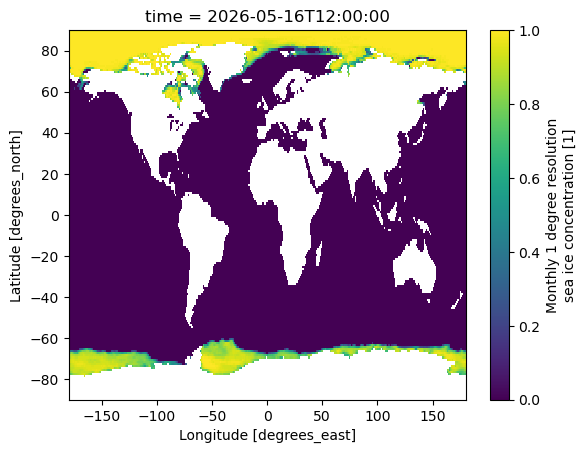

In [26]:
hadisst1.sic.isel(time=-1).plot()

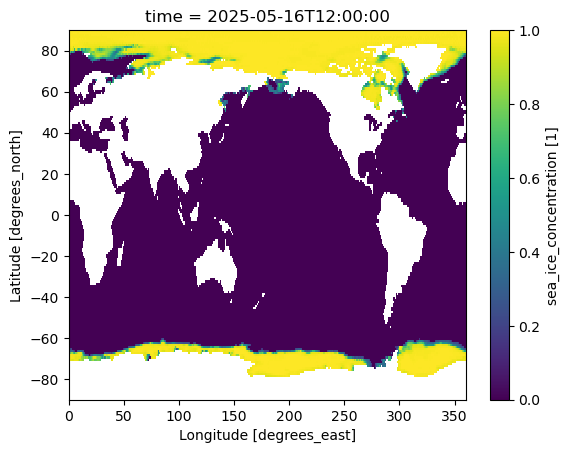

In [27]:
hadisst2.sic.isel(time=-1).plot()

Comparing landmasks between HadISST1 and 2:

In [28]:
hadisst1_test = hadisst1.sic.isel(time=-1)
hadisst2_test = hadisst2.sic.isel(time=-1).roll(longitude=-180)
hadisst2_test['longitude'] = hadisst1_test['longitude']

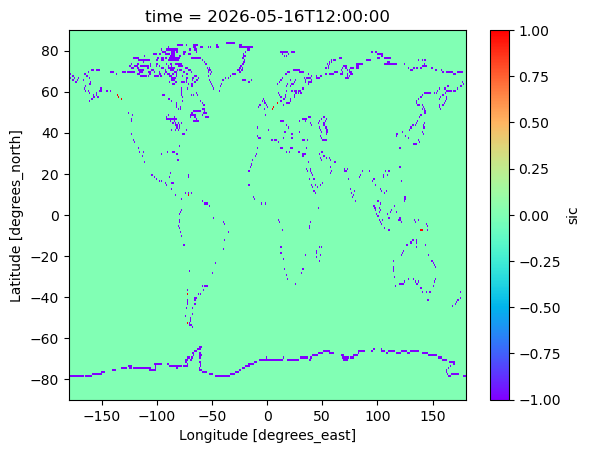

In [29]:
(xr.where(hadisst2_test.isnull(), 1, 0) - xr.where(hadisst1_test.isnull(), 1, 0)).plot(cmap='rainbow')

In [30]:
hadisst_landmask = xr.where(hadisst1_test.isnull(), False, True)
hadisst_landmask_c180 = hadisst_landmask.roll(longitude=180)
hadisst_landmask_c180['longitude'] = hadisst2.longitude

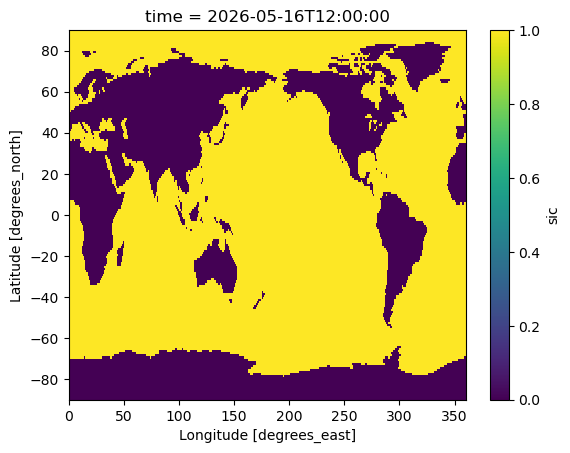

In [31]:
hadisst_landmask_c180.plot()

#### OSI SAF

In [32]:
osi_saf_ds = xr.open_dataset('/roselab_rit/rford/osi_saf_full.nc')

In [33]:
osi_saf_ds

<xarray.Dataset> Size: 752MB
Dimensions:                 (time: 503, yc: 432, xc: 432, nv: 2)
Coordinates:
  * time                    (time) datetime64[ns] 4kB 1978-10-16T12:00:00 ......
  * yc                      (yc) float64 3kB 5.388e+03 5.362e+03 ... -5.388e+03
  * xc                      (xc) float64 3kB -5.388e+03 -5.362e+03 ... 5.388e+03
    lat                     (yc, xc) float32 746kB ...
    lon                     (yc, xc) float32 746kB ...
Dimensions without coordinates: nv
Data variables:
    Lambert_Azimuthal_Grid  (time) int32 2kB ...
    ice_conc                (time, yc, xc) float64 751MB ...
    time_bnds               (time, nv) datetime64[ns] 8kB ...
Attributes: (12/42)
    title:                     Monthly Sea Ice Concentration Climate Data Rec...
    summary:                   This climate data record of sea ice concentrat...
    topiccategory:             Oceans ClimatologyMeteorologyAtmosphere
    geospatial_lat_min:        -90.0
    geospatial_lat_max:        -16.62393
    geospatial_lon_min:        -180.0
    ...                        ...
    product_version:           3.1
    doi:                       10.15770/EUM_SAF_OSI_0023
    references:                Product User Manual (2025),Algorithm Theoretic...
    product_id:                osi-450-a1
    history:                   2025-02-17T08:58:28Z creation\n2025-02-17T11:0...
    license:                   http://creativecommons.org/licenses/by/4.0/

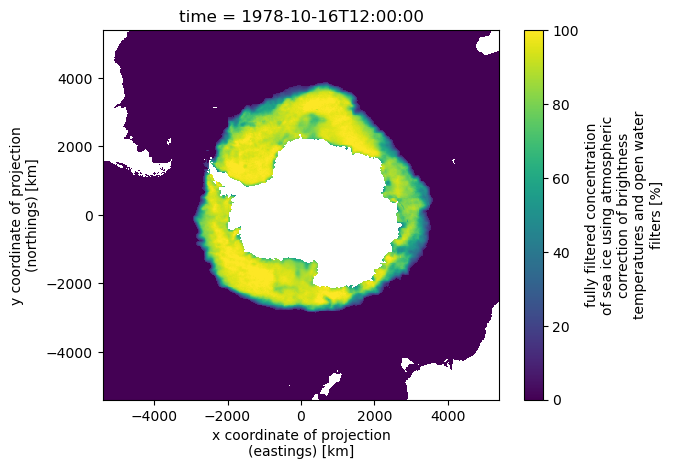

In [34]:
osi_saf_ds.ice_conc.isel(time=0).plot()

In [35]:
osi_saf_interim_ds = xr.open_dataset('/roselab_rit/rford/osi_saf_interim_full.nc')

In [36]:
osi_saf_interim_ds

<xarray.Dataset> Size: 85MB
Dimensions:                 (time: 56, yc: 432, xc: 432, nv: 2)
Coordinates:
  * time                    (time) datetime64[ns] 448B 2021-01-16T12:00:00 .....
  * yc                      (yc) float64 3kB 5.388e+03 5.362e+03 ... -5.388e+03
  * xc                      (xc) float64 3kB -5.388e+03 -5.362e+03 ... 5.388e+03
    lat                     (yc, xc) float32 746kB ...
    lon                     (yc, xc) float32 746kB ...
Dimensions without coordinates: nv
Data variables:
    Lambert_Azimuthal_Grid  (time) int32 224B ...
    ice_conc                (time, yc, xc) float64 84MB ...
    time_bnds               (time, nv) datetime64[ns] 896B ...
Attributes: (12/43)
    topiccategory:             Oceans ClimatologyMeteorologyAtmosphere
    keywords:                  GCMDSK:Earth Science > Cryosphere > Sea Ice > ...
    keywords_vocabulary:       GCMDSK:GCMD Science Keywords:https://gcmd.eart...
    geospatial_lat_min:        -90.0
    geospatial_lat_max:        -16.62393
    geospatial_lon_min:        -180.0
    ...                        ...
    creator_url:               https://osi-saf.eumetsat.int/
    references:                Product User Manual v3 (2022),Algorithm Theore...
    contributor_name:          Thomas Lavergne,Atle Soerensen,Rasmus Tonboe,C...
    contributor_role:          PrincipalInvestigator,author,author,author,aut...
    standard_name_vocabulary:  CF Standard Name Table (Version 78, 21 Septemb...
    naming_authority:          int.eumetsat

In [37]:
osi_saf_combined_ds = xr.concat([osi_saf_ds, osi_saf_interim_ds], dim='time')

In [38]:
osi_saf_combined_ds

<xarray.Dataset> Size: 836MB
Dimensions:                 (time: 559, yc: 432, xc: 432, nv: 2)
Coordinates:
  * time                    (time) datetime64[ns] 4kB 1978-10-16T12:00:00 ......
  * yc                      (yc) float64 3kB 5.388e+03 5.362e+03 ... -5.388e+03
  * xc                      (xc) float64 3kB -5.388e+03 -5.362e+03 ... 5.388e+03
    lat                     (yc, xc) float32 746kB -16.62 -16.82 ... -16.62
    lon                     (yc, xc) float32 746kB -45.0 -44.87 ... 135.1 135.0
Dimensions without coordinates: nv
Data variables:
    Lambert_Azimuthal_Grid  (time) int32 2kB -2147483647 ... -2147483647
    ice_conc                (time, yc, xc) float64 835MB nan nan nan ... nan nan
    time_bnds               (time, nv) datetime64[ns] 9kB 1978-10-01 ... 2025...
Attributes: (12/42)
    title:                     Monthly Sea Ice Concentration Climate Data Rec...
    summary:                   This climate data record of sea ice concentrat...
    topiccategory:             Oceans ClimatologyMeteorologyAtmosphere
    geospatial_lat_min:        -90.0
    geospatial_lat_max:        -16.62393
    geospatial_lon_min:        -180.0
    ...                        ...
    product_version:           3.1
    doi:                       10.15770/EUM_SAF_OSI_0023
    references:                Product User Manual (2025),Algorithm Theoretic...
    product_id:                osi-450-a1
    history:                   2025-02-17T08:58:28Z creation\n2025-02-17T11:0...
    license:                   http://creativecommons.org/licenses/by/4.0/

#### NSIDC

In [39]:
nsidc = xr.open_dataset('/roselab_rit/rford/sic_pss25_197811-202602_v06r00.nc')

In [40]:
lat_from_osi_saf = osi_saf_combined_ds.sel(xc=slice(1e-3*nsidc.x.min(), 1e-3*nsidc.x.max()), yc=slice(1e-3*nsidc.y.max(), 1e-3*nsidc.y.min())).lat.rename({'yc': 'y', 'xc': 'x'})
lon_from_osi_saf = osi_saf_combined_ds.sel(xc=slice(1e-3*nsidc.x.min(), 1e-3*nsidc.x.max()), yc=slice(1e-3*nsidc.y.max(), 1e-3*nsidc.y.min())).lon.rename({'yc': 'y', 'xc': 'x'})

lat_from_osi_saf['y'] = 1e3*lat_from_osi_saf['y']
lat_from_osi_saf['x'] = 1e3*lat_from_osi_saf['x']
lon_from_osi_saf['y'] = 1e3*lon_from_osi_saf['y']
lon_from_osi_saf['x'] = 1e3*lon_from_osi_saf['x']

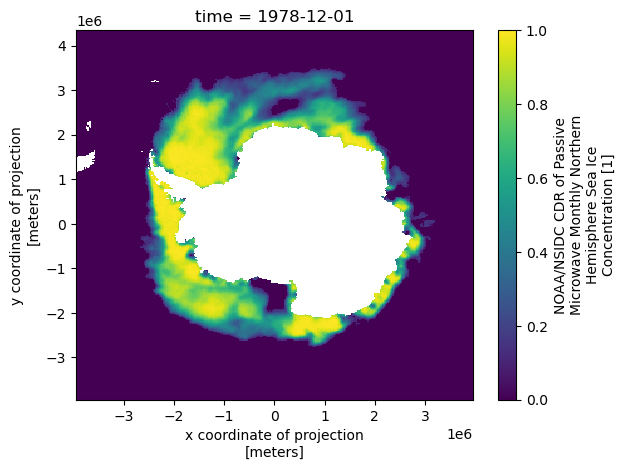

In [41]:
nsidc.cdr_seaice_conc_monthly.isel(time=1).plot()

In [42]:
nsidc_latlon = nsidc.assign_coords(lat=lat_from_osi_saf)

## Sea ice area

### CESM

In [43]:
def aa_sea_ice_area(sic):
    """ in: SIC (%), out: SIA (10^6 km^2)
    """
    _lats = hr_sic_ds.lat.isel(time=0, ens_member=0).compute()
    return 1e-6*(area*(sic/100)).where(_lats < 0).sum(dim=['ni', 'nj'])

def aa_sea_ice_area_lon(sic):
    """ in: SIC (%), out: SIA as a function of lon (10^6 km^2 deg^-1)
    """
    _lats = hr_sic_ds.lat.isel(time=0, ens_member=0).compute()
    return 1e-6*(area*(sic/100)).where(_lats < 0).sum(dim=['nj'])

In [44]:
hr_aasia = aa_sea_ice_area(hr_sic_ds.siconc).compute()

In [45]:
lr_aasia = aa_sea_ice_area(lr_sic_ds.siconc).compute()

Interesting synchronization in two pairs of HR ensemble members:

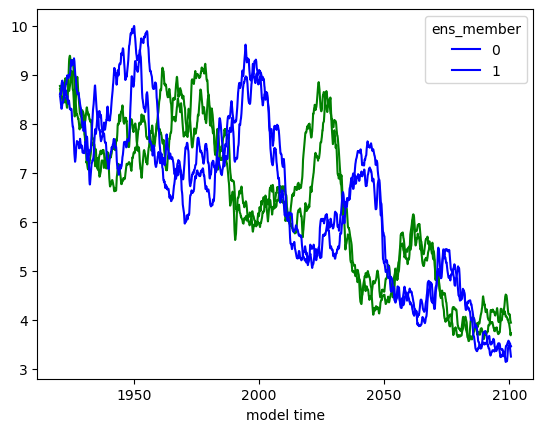

In [46]:
hr_aasia.isel(ens_member=[1, 6]).rolling(time=12, center=True).mean().plot.line(x='time', color='g', label='EM 1 and 6')
hr_aasia.isel(ens_member=[7, 8]).rolling(time=12, center=True).mean().plot.line(x='time', color='b', label='EM 7 and 8')
# hr_aasia.isel(ens_member=[2]).rolling(time=12, center=True).mean().plot.line(x='time', color='k', label='EM 7 and 8')

Note that CESM has a 1-month offset in the time listed for monthly data, so for example, `1979-01` is the average for December 1978.

In [47]:
hr_aasia_ann = hr_aasia.resample(time='YE', label='left').mean()
hr_aasia_sep = hr_aasia.sel(time=hr_aasia.time.dt.month.isin(10))
hr_aasia_feb = hr_aasia.sel(time=hr_aasia.time.dt.month.isin(3))

In [48]:
hr_aasia_ann

<xarray.DataArray (ens_member: 10, time: 182)> Size: 15kB
array([[8.62177624, 8.41501565, 8.40050789, ..., 3.84988997, 3.86885548,
        3.14502221],
       [8.79622194, 8.46738901, 8.85708346, ..., 3.99169024, 3.68853479,
        3.18998502],
       [8.66996873, 9.05068653, 8.99180717, ..., 3.15358971, 3.31896686,
        2.50995898],
       ...,
       [8.6712206 , 8.40409893, 8.64995601, ..., 3.44770878, 3.46685334,
        2.47765757],
       [8.66816101, 8.88348835, 8.59785373, ..., 3.55426621, 3.27906548,
        2.56170933],
       [8.63754005, 8.54153173, 8.81811476, ..., 3.30731231, 3.10488617,
        2.26681927]], shape=(10, 182))
Coordinates:
  * time     (time) object 1kB 1919-12-31 00:00:00 ... 2100-12-31 00:00:00
Dimensions without coordinates: ens_member

In [49]:
lr_aasia_ann = lr_aasia.resample(time='YE', label='left').mean()
lr_aasia_sep = lr_aasia.sel(time=lr_aasia.time.dt.month.isin(10))
lr_aasia_feb = lr_aasia.sel(time=lr_aasia.time.dt.month.isin(3))

### Obs

In HadISST2, SH sea ice is missing for 1986-04 and 1986-05.

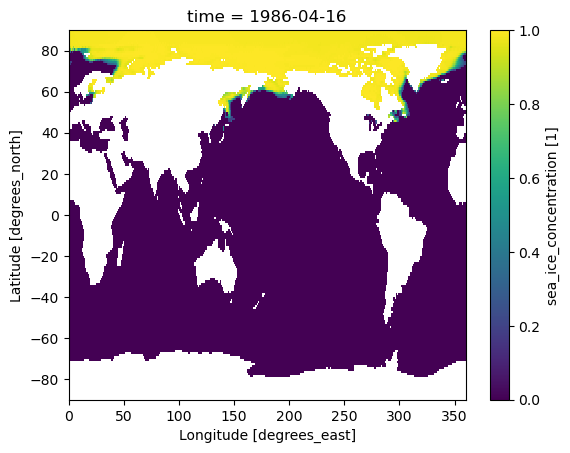

In [50]:
hadisst2.sic.sel(time='1986-04').plot()

Fill in missing values as average between previous and next April/May:

In [51]:
hadisst2_aasia = 1e-6*(hadisst2.xe_area*(hadisst2.sic)).where((hadisst2.latitude < 0) & hadisst_landmask_c180).sum(dim=['latitude', 'longitude'])
hadisst2_aasia.loc['1986-04'] = 0.5*(hadisst2_aasia.loc['1985-04'].values + hadisst2_aasia.loc['1987-04'].values)
hadisst2_aasia.loc['1986-05'] = 0.5*(hadisst2_aasia.loc['1985-05'].values + hadisst2_aasia.loc['1987-05'].values)

In [52]:
hadisst1_aasia = 1e-6*(hadisst1.xe_area*(hadisst1.sic)).where(hadisst1.latitude < 0).sum(dim=['latitude', 'longitude'])

In [53]:
nsidc_aasia = 1e-6*625*nsidc.cdr_seaice_conc_monthly.sum(dim=['x', 'y'])
nsidc_aasia.loc['1987-12'] = 0.5*(nsidc_aasia.loc['1986-12'].values + nsidc_aasia.loc['1988-12'].values)
nsidc_aasia.loc['1988-01'] = 0.5*(nsidc_aasia.loc['1987-01'].values + nsidc_aasia.loc['1989-01'].values)

OSI SAF is missing 1986-04, 1986-05, 1986-06, and 1987-12.

In [54]:
osi_saf_aasia = 1e-2*1e-6*625*osi_saf_combined_ds.ice_conc.sum(dim=['xc', 'yc'])

osi_saf_missing_time = [np.datetime64('1986-04-16T12:00:00.000000000'),
                        np.datetime64('1986-05-16T12:00:00.000000000'),
                        np.datetime64('1986-06-16T12:00:00.000000000'),
                        np.datetime64('1987-12-16T12:00:00.000000000')]
osi_saf_missing_time_da = xr.DataArray(osi_saf_missing_time, dims=['time'], coords=[osi_saf_missing_time])
osi_saf_full_time = xr.concat([osi_saf_aasia.time, osi_saf_missing_time_da], dim='time')
osi_saf_aasia = osi_saf_aasia.reindex(time=osi_saf_full_time, fill_value=-3000.0).sortby('time')

osi_saf_aasia.loc['1986-04'] = 0.5*(osi_saf_aasia.loc['1985-04'].values + osi_saf_aasia.loc['1987-04'].values)
osi_saf_aasia.loc['1986-05'] = 0.5*(osi_saf_aasia.loc['1985-05'].values + osi_saf_aasia.loc['1987-05'].values)
osi_saf_aasia.loc['1986-06'] = 0.5*(osi_saf_aasia.loc['1985-06'].values + osi_saf_aasia.loc['1987-06'].values)
osi_saf_aasia.loc['1987-12'] = 0.5*(osi_saf_aasia.loc['1986-12'].values + osi_saf_aasia.loc['1988-12'].values)

In [55]:
nsidc_aasia_ann = nsidc_aasia.resample(time='YE', label='left').mean().isel(time=slice(1, -1))
nsidc_aasia_sep = nsidc_aasia.sel(time=nsidc_aasia.time.dt.month.isin([9]))
nsidc_aasia_feb = nsidc_aasia.sel(time=nsidc_aasia.time.dt.month.isin([2]))

In [56]:
osi_saf_aasia_sep = osi_saf_aasia.sel(time=osi_saf_aasia.time.dt.month.isin([9]))
osi_saf_aasia_feb = osi_saf_aasia.sel(time=osi_saf_aasia.time.dt.month.isin([2]))

In [57]:
osi_saf_aasia_sep

<xarray.DataArray 'ice_conc' (time: 46)> Size: 368B
array([15.56025994, 16.18275981, 16.05235869, 15.78155181, 15.99814531,
       15.39809513, 16.11953075, 15.08714625, 16.01312962, 15.9003775 ,
       15.76721375, 15.87475606, 16.15043463, 15.80667206, 16.35506212,
       16.34533388, 16.13075375, 16.291646  , 16.24276925, 16.45571644,
       16.433933  , 16.77169825, 15.92968319, 15.73895544, 15.87624512,
       16.25943919, 16.52804094, 16.78400775, 16.83087244, 16.01228538,
       16.69697538, 16.20476088, 16.52030769, 17.11021069, 17.22392906,
       17.54125925, 16.01312788, 15.58681569, 15.51467644, 15.83249913,
       16.22012675, 16.69756475, 16.07798825, 15.74714331, 14.69737331,
       14.94620425])
Coordinates:
  * time     (time) datetime64[ns] 368B 1979-09-16T12:00:00 ... 2024-09-16T12...

Resampling the whole OSI SAF dataset results in a mysterious error related to numba, so just for the annual comparison below, I am using a precomputed sea ice area dataset:

In [58]:
osi_saf_sii = xr.open_dataset('ice_area_sh_sii-v3p0_monthly.nc')

In [59]:
osi_saf_sii_ann = osi_saf_sii.sia.resample(time='YE', label='left', skipna=False).mean()

In [60]:
hadisst2_aasia_ann = hadisst2_aasia.resample(time='YE', label='left', skipna=False).mean()
hadisst2_aasia_sep = hadisst2_aasia.sel(time=hadisst2_aasia.time.dt.month.isin(9))
hadisst2_aasia_feb = hadisst2_aasia.sel(time=hadisst2_aasia.time.dt.month.isin(2))

In [61]:
hadisst1_aasia_ann = hadisst1_aasia.resample(time='YE', label='left').mean()
hadisst1_aasia_sep = hadisst1_aasia.sel(time=hadisst1_aasia.time.dt.month.isin(9))
hadisst1_aasia_feb = hadisst1_aasia.sel(time=hadisst1_aasia.time.dt.month.isin(2))

The resampling results in time staps of Dec 31. Jan 1 would look better on plots, so we can adjust the time:

In [62]:
hadisst2_aasia_ann['time'] = hadisst2_aasia_ann['time'] + pd.Timedelta(1, 'D')
hadisst1_aasia_ann['time'] = hadisst1_aasia_ann['time'] + pd.Timedelta(1, 'D')
nsidc_aasia_ann['time'] = nsidc_aasia_ann['time'] + pd.Timedelta(1, 'D')
osi_saf_sii_ann['time'] = osi_saf_sii_ann['time'] + pd.Timedelta(1, 'D')

## Optional Appendix Figures

Text(0.5, 1.0, '')

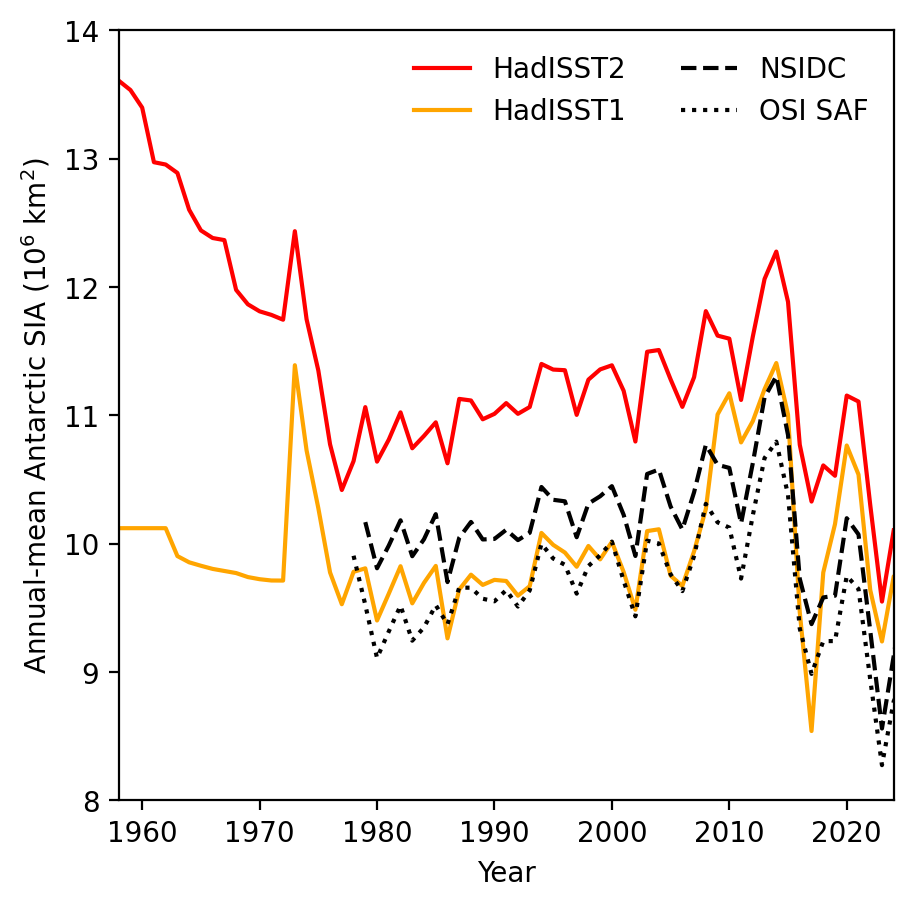

In [63]:
plt.figure(dpi=200, figsize=(5, 5))
hadisst2_aasia_ann.isel(time=slice(None, -1)).plot(color='red', label='HadISST2')
hadisst1_aasia_ann.plot(color='orange', label='HadISST1')
nsidc_aasia_ann.plot(color='k', linestyle='--', label='NSIDC')
osi_saf_sii_ann.isel(time=slice(None, -1)).plot(color='k', linestyle=':', label='OSI SAF')
# plt.plot(hadisst1_aasia_ann.time.sel(time=slice('1958', '2023')), goosse24_cesm_aasia_anom + 11, color='cornflowerblue', label='G2024')
# plt.axvline(hadisst1_aasia_ann.time.sel(time='1986'), color='k', alpha=0.4)
# plt.axvline(hadisst1_aasia_ann.time.sel(time='2014'), color='k', alpha=0.4)

plt.xlim(hadisst1_aasia_ann.time.sel(time='1958'), hadisst1_aasia_ann.time.sel(time='2024'))
plt.ylim(8, 14)
plt.legend(framealpha=0, fancybox=False, ncols=2)
# plt.grid(alpha=0.5)
plt.ylabel('Annual-mean Antarctic SIA ($10^6$ km$^2$)')
plt.xlabel('Year')
plt.title('')

HadISST1 uses monthly median SIC, while OSI SAF and HadISST2 use monthly mean SIC, but OSI SAF is much closer to HadISST1.

Synchronization:

Text(0.5, 0, 'Year')

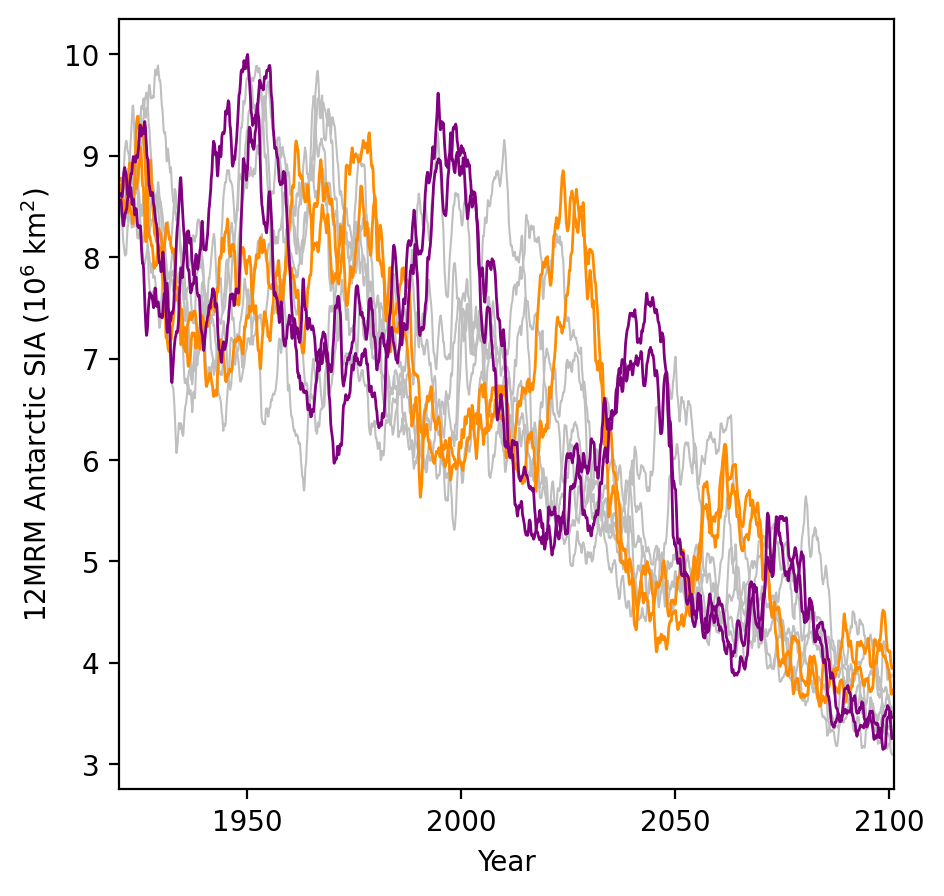

In [64]:
plt.figure(dpi=200, figsize=(5, 5))

hr_aasia.isel(ens_member=[0, 2, 3, 4, 5, 9]).rolling(time=12, center=True).mean().plot.line(x='time', color='0.75', alpha=1, linewidth=0.75)
hr_aasia.isel(ens_member=[1, 6]).rolling(time=12, center=True).mean().plot.line(x='time', color='darkorange', alpha=1, linewidth=1)
hr_aasia.isel(ens_member=[7, 8]).rolling(time=12, center=True).mean().plot.line(x='time', color='purple', alpha=1, linewidth=1)

plt.gca().get_legend().remove()
plt.xlim(hr_aasia.time.min().values, hr_aasia.time.max().values)
plt.ylabel('12MRM Antarctic SIA ($10^6$ km$^2$)')
plt.xlabel('Year')

## Choosing the start of the trend

In [65]:
nsidc_trend_by_start = []
osi_saf_trend_by_start = []
hadisst1_trend_by_start = []

for year in np.arange(1979, 1994, 1):
    nsidc_trend_by_start.append(ns_per_dec*nsidc_aasia_sep.sel(time=slice(str(year), '2014')).polyfit(dim='time', deg=1).polyfit_coefficients.sel(degree=1).values)
    osi_saf_trend_by_start.append(ns_per_dec*osi_saf_aasia_sep.sel(time=slice(str(year), '2014')).polyfit(dim='time', deg=1).polyfit_coefficients.sel(degree=1).values)
    hadisst1_trend_by_start.append(ns_per_dec*hadisst1_aasia_sep.sel(time=slice(str(year), '2014')).polyfit(dim='time', deg=1).polyfit_coefficients.sel(degree=1).values)

Text(0.5, 1.0, 'Pre-2014 trend as a function of start date')

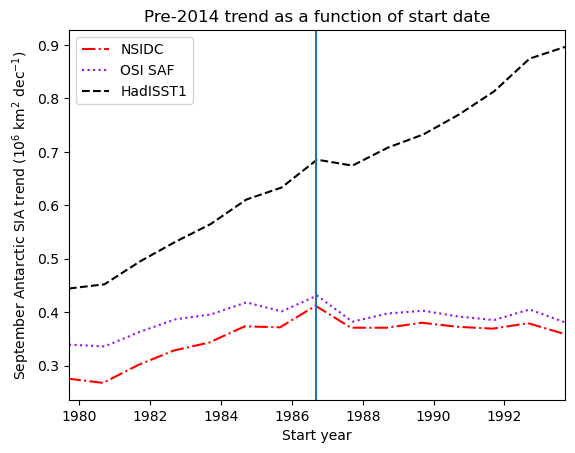

In [66]:
plt.plot(nsidc_aasia_sep.time.sel(time=slice('1979', '1993')), nsidc_trend_by_start, color='r', linestyle='-.', label='NSIDC')
plt.plot(osi_saf_aasia_sep.time.sel(time=slice('1979', '1993')), osi_saf_trend_by_start, color='xkcd:violet', linestyle=':', label='OSI SAF')
plt.plot(hadisst1_aasia_sep.time.sel(time=slice('1979', '1993')), hadisst1_trend_by_start, color='k', linestyle='--', label='HadISST1')
plt.axvline(nsidc_aasia_sep.time.sel(time='1986'))
plt.ylabel('September Antarctic SIA trend (10$^6$ km$^2$ dec$^{-1}$)')
plt.xlabel('Start year')
plt.legend()
plt.xlim(hadisst1_aasia_sep.time.sel(time='1979'), hadisst1_aasia_sep.time.sel(time='1993'))
plt.title('Pre-2014 trend as a function of start date')

We start the increasing trend period at 1986 because it produces a local maximum in the trend. Any later, and we lose too much data. Also, 1986 seems to be the pre-2014 minimum in all 3 datasets used (see figure 3). The larger trend in HadISST1 is the result of a large jump from 2008 to 2009 (a discontinuity from different satellite sensors; see Screen 2011):

Text(0.5, 0, 'Year')

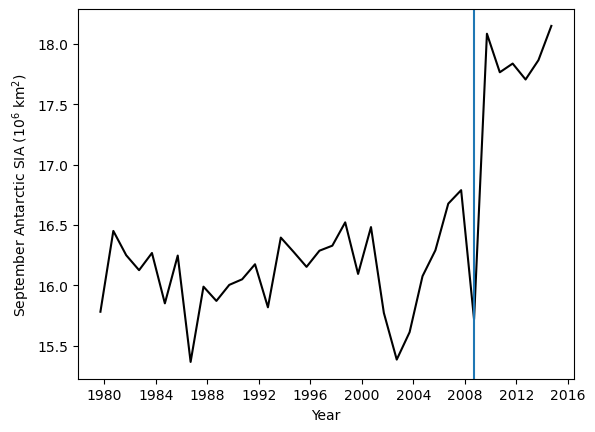

In [67]:
hadisst1_aasia_sep.sel(time=slice('1979', '2014')).plot(color='k')
plt.axvline(nsidc_aasia_sep.time.sel(time='2008'))
# plt.axvline(nsidc_aasia_sep.time.sel(time='2009'))
plt.ylabel('September Antarctic SIA (10$^6$ km$^2$)')
plt.xlabel('Year')

## Figure 1: climatologies

Using years 1979-2024, which all datasets cover:

In [68]:
hr_aasia_clim_em = hr_aasia.sel(time=slice('1979-02', '2024-01')).groupby('time.month').mean().mean(dim='ens_member')
hr_aasia_clim_min = hr_aasia.sel(time=slice('1979-02', '2024-01')).groupby('time.month').min().min(dim='ens_member')
hr_aasia_clim_max = hr_aasia.sel(time=slice('1979-02', '2024-01')).groupby('time.month').max().max(dim='ens_member')

In [69]:
lr_aasia_clim_em = lr_aasia.sel(time=slice('1979-02', '2024-01')).groupby('time.month').mean().mean(dim='ens_member')
lr_aasia_clim_min = lr_aasia.sel(time=slice('1979-02', '2024-01')).groupby('time.month').min().min(dim='ens_member')
lr_aasia_clim_max = lr_aasia.sel(time=slice('1979-02', '2024-01')).groupby('time.month').max().max(dim='ens_member')

In [70]:
h1_aasia_clim = hadisst1_aasia.sel(time=slice('1979-01', '2024-12')).groupby('time.month').mean()
h1_aasia_clim_min = hadisst1_aasia.sel(time=slice('1979-01', '2024-12')).groupby('time.month').min()
h1_aasia_clim_max = hadisst1_aasia.sel(time=slice('1979-01', '2024-12')).groupby('time.month').max()

In [71]:
nsidc_aasia_clim = nsidc_aasia.sel(time=slice('1979-01', '2024-12')).groupby('time.month').mean()
nsidc_aasia_clim_min = nsidc_aasia.sel(time=slice('1979-01', '2024-12')).groupby('time.month').min()
nsidc_aasia_clim_max = nsidc_aasia.sel(time=slice('1979-01', '2024-12')).groupby('time.month').max()

In [72]:
osi_saf_aasia_clim = osi_saf_aasia.sel(time=slice('1979-01', '2024-12')).groupby('time.month').mean()
osi_saf_aasia_clim_min = osi_saf_aasia.sel(time=slice('1979-01', '2024-12')).groupby('time.month').min()
osi_saf_aasia_clim_max = osi_saf_aasia.sel(time=slice('1979-01', '2024-12')).groupby('time.month').max()

In [73]:
obs_aasia_clim_max = np.min([h1_aasia_clim_max, nsidc_aasia_clim_max, osi_saf_aasia_clim_max], axis=0)
obs_aasia_clim_min = np.min([h1_aasia_clim_min, nsidc_aasia_clim_min, osi_saf_aasia_clim_min], axis=0)

In [74]:
obs_aasia_clim_max

array([ 4.65113369,  2.86367319,  4.16076944,  7.117238  , 10.27401201,
       13.18312575, 15.33708887, 16.73239013, 17.54125925, 16.720382  ,
       14.16941506,  9.22897887])

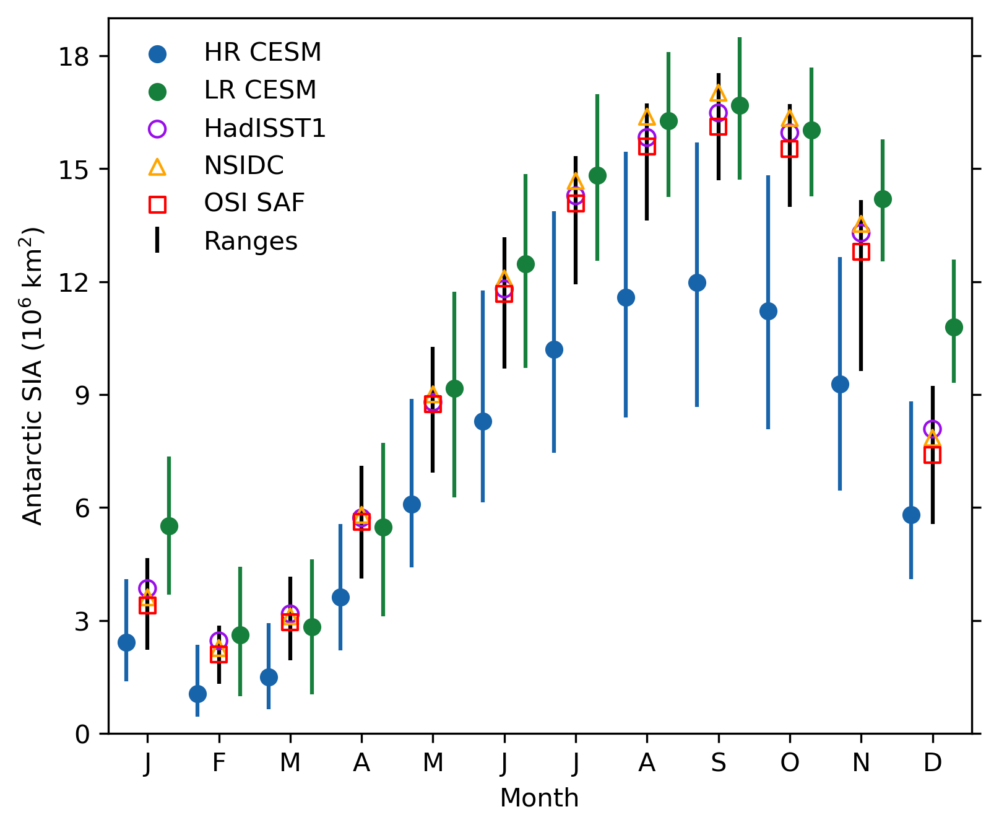

In [325]:
plt.figure(dpi=300, figsize=(6, 5))

plt.scatter(hr_aasia_clim_em.month-0.3, hr_aasia_clim_em.roll(month=-1), color=blues(0.8), marker='o', label='HR CESM', zorder=3)
plt.errorbar(hr_aasia_clim_min.month-0.3, hr_aasia_clim_em.roll(month=-1),
             yerr=[hr_aasia_clim_em.roll(month=-1) - hr_aasia_clim_min.roll(month=-1), hr_aasia_clim_max.roll(month=-1) - hr_aasia_clim_em.roll(month=-1)], 
             color=blues(0.8), capsize=0, fmt='none', zorder=3)

plt.scatter(lr_aasia_clim_em.month+0.3, lr_aasia_clim_em.roll(month=-1), color=greens(0.8), marker='o', label='LR CESM', zorder=3)
plt.errorbar(lr_aasia_clim_min.month+0.3, lr_aasia_clim_em.roll(month=-1),
             yerr=[lr_aasia_clim_em.roll(month=-1) - lr_aasia_clim_min.roll(month=-1), lr_aasia_clim_max.roll(month=-1) - lr_aasia_clim_em.roll(month=-1)], 
             color=greens(0.8), capsize=0, fmt='none', zorder=3)

plt.scatter(h1_aasia_clim.month, h1_aasia_clim, color='xkcd:violet', facecolor='none', marker='o', s=40, label='HadISST1', zorder=4)
plt.scatter(nsidc_aasia_clim.month, nsidc_aasia_clim, color='orange', facecolor='none', marker='^', label='NSIDC', zorder=4)
plt.scatter(osi_saf_aasia_clim.month, osi_saf_aasia_clim, color='r', facecolor='none', marker='s', label='OSI SAF', zorder=4)

plt.errorbar(nsidc_aasia_clim_min.month, nsidc_aasia_clim,
             yerr=[nsidc_aasia_clim - obs_aasia_clim_min, obs_aasia_clim_max - nsidc_aasia_clim], 
             color='k', capsize=0, fmt='none', zorder=3)

plt.errorbar(-99, 10, yerr=1, capsize=0, fmt='none', color='k', label='Ranges')


plt.xlim(0.45, 12.55)
plt.ylim(0, 19)
plt.xticks(np.arange(1, 13), list('JFMAMJJASOND'))
plt.yticks([0, 3, 6, 9, 12, 15, 18])
plt.xlabel('Month')
plt.ylabel('Antarctic SIA (10$^6$ km$^2$)')
plt.gca().tick_params(right=True)
# plt.grid(alpha=0.5, zorder=-2)
plt.legend(framealpha=0, fancybox=False)
# plt.title('Antarctic SIA climatologies and ranges (1979–2024)')
# plt.annotate('1979–2024', xy=(0.2, 0.9), xycoords='axes fraction')

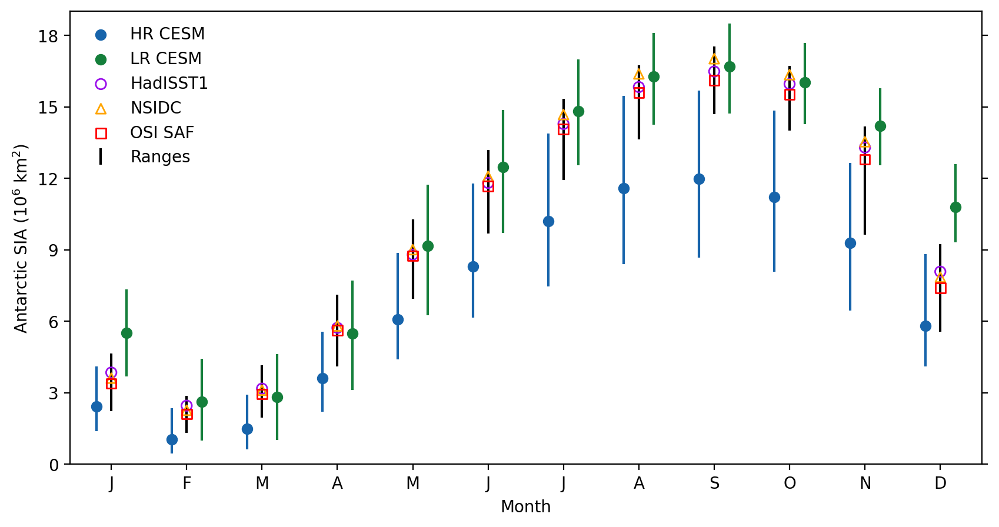

In [76]:
plt.figure(dpi=200, figsize=(10, 5))

plt.scatter(hr_aasia_clim_em.month-0.2, hr_aasia_clim_em.roll(month=-1), color=blues(0.8), marker='o', label='HR CESM', zorder=3)
plt.errorbar(hr_aasia_clim_min.month-0.2, hr_aasia_clim_em.roll(month=-1),
             yerr=[hr_aasia_clim_em.roll(month=-1) - hr_aasia_clim_min.roll(month=-1), hr_aasia_clim_max.roll(month=-1) - hr_aasia_clim_em.roll(month=-1)], 
             color=blues(0.8), capsize=0, fmt='none', zorder=3)

plt.scatter(lr_aasia_clim_em.month+0.2, lr_aasia_clim_em.roll(month=-1), color=greens(0.8), marker='o', label='LR CESM', zorder=3)
plt.errorbar(lr_aasia_clim_min.month+0.2, lr_aasia_clim_em.roll(month=-1),
             yerr=[lr_aasia_clim_em.roll(month=-1) - lr_aasia_clim_min.roll(month=-1), lr_aasia_clim_max.roll(month=-1) - lr_aasia_clim_em.roll(month=-1)], 
             color=greens(0.8), capsize=0, fmt='none', zorder=3)

plt.scatter(h1_aasia_clim.month, h1_aasia_clim, color='xkcd:violet', facecolor='none', marker='o', s=40, label='HadISST1', zorder=4)
plt.scatter(nsidc_aasia_clim.month, nsidc_aasia_clim, color='orange', facecolor='none', marker='^', label='NSIDC', zorder=4)
plt.scatter(osi_saf_aasia_clim.month, osi_saf_aasia_clim, color='r', facecolor='none', marker='s', label='OSI SAF', zorder=4)

plt.errorbar(nsidc_aasia_clim_min.month, nsidc_aasia_clim,
             yerr=[nsidc_aasia_clim - obs_aasia_clim_min, obs_aasia_clim_max - nsidc_aasia_clim], 
             color='k', capsize=0, fmt='none', zorder=3)

plt.errorbar(-99, 10, yerr=1, capsize=0, fmt='none', color='k', label='Ranges')


plt.xlim(0.45, 12.55)
plt.ylim(0, 19)
plt.xticks(np.arange(1, 13), list('JFMAMJJASOND'))
plt.yticks([0, 3, 6, 9, 12, 15, 18])
plt.xlabel('Month')
plt.ylabel('Antarctic SIA (10$^6$ km$^2$)')
plt.gca().tick_params(right=True)
# plt.grid(alpha=0.5, zorder=-2)
plt.legend(framealpha=0, fancybox=False)
# plt.title('Antarctic SIA climatologies and ranges (1979–2024)')
# plt.annotate('1979–2024', xy=(0.2, 0.9), xycoords='axes fraction')

## Figures 2 and 3: Climatology maps

In [77]:
hr_sic_sep_clim = hr_sic_ds.siconc.sel(time=hr_sic_ds.time.dt.month.isin([10])).sel(time=slice('1979', '2024')).mean(dim='time').where(hr_sic_ds.lat.isel(time=0, ens_member=0).compute() <= -50, drop=True).compute()
hr_sic_feb_clim = hr_sic_ds.siconc.sel(time=hr_sic_ds.time.dt.month.isin([3])).sel(time=slice('1979', '2024')).mean(dim='time').where(hr_sic_ds.lat.isel(time=0, ens_member=0).compute() <= -50, drop=True).compute()

In [78]:
lr_sic_sep_clim = lr_sic_ds.siconc.sel(time=lr_sic_ds.time.dt.month.isin([10])).sel(time=slice('1979', '2024')).mean(dim='time').where(lr_sic_ds.lat.isel(time=0, ens_member=0).compute() <= -50, drop=True).compute()
lr_sic_feb_clim = lr_sic_ds.siconc.sel(time=lr_sic_ds.time.dt.month.isin([3])).sel(time=slice('1979', '2024')).mean(dim='time').where(lr_sic_ds.lat.isel(time=0, ens_member=0).compute() <= -50, drop=True).compute()

In [79]:
h1_sic_sep_clim = hadisst1.sic.sel(time=hadisst1.time.dt.month.isin([9])).sel(time=slice('1979', '2024')).mean(dim='time')

In [80]:
h1_sic_feb_clim = hadisst1.sic.sel(time=hadisst1.time.dt.month.isin([2])).sel(time=slice('1979', '2024')).mean(dim='time')

In [81]:
osi_saf_sep_clim = osi_saf_combined_ds.ice_conc.sel(time=osi_saf_combined_ds.time.dt.month.isin([9])).sel(time=slice('1979', '2024')).mean(dim='time')

In [82]:
osi_saf_feb_clim = osi_saf_combined_ds.ice_conc.sel(time=osi_saf_combined_ds.time.dt.month.isin([2])).sel(time=slice('1979', '2024')).mean(dim='time')

In [83]:
nsidc_sep_clim = nsidc_latlon.cdr_seaice_conc_monthly.sel(time=nsidc_latlon.time.dt.month.isin([9])).sel(time=slice('1979', '2024')).mean(dim='time')

In [84]:
nsidc_feb_clim = nsidc_latlon.cdr_seaice_conc_monthly.sel(time=nsidc_latlon.time.dt.month.isin([2])).sel(time=slice('1979', '2024')).mean(dim='time')

In [85]:
hr_sic_sep_clim_em_cyc, lons_cyc = add_cyclic_point(hr_sic_sep_clim.mean(dim='ens_member'), lons)
lr_sic_sep_clim_em_cyc, lons_cyc = add_cyclic_point(lr_sic_sep_clim.mean(dim='ens_member'), lons)

h1_sic_sep_clim_cyc, h1_lons_cyc = add_cyclic_point(100*h1_sic_sep_clim.where(h1_sic_sep_clim.latitude <= -50, drop=True), h1_sic_sep_clim.longitude)

In [86]:
hr_sic_feb_clim_em_cyc, lons_cyc = add_cyclic_point(hr_sic_feb_clim.mean(dim='ens_member'), lons)
lr_sic_feb_clim_em_cyc, lons_cyc = add_cyclic_point(lr_sic_feb_clim.mean(dim='ens_member'), lons)

h1_sic_feb_clim_cyc, h1_lons_cyc = add_cyclic_point(100*h1_sic_feb_clim.where(h1_sic_feb_clim.latitude <= -50, drop=True), h1_sic_feb_clim.longitude)

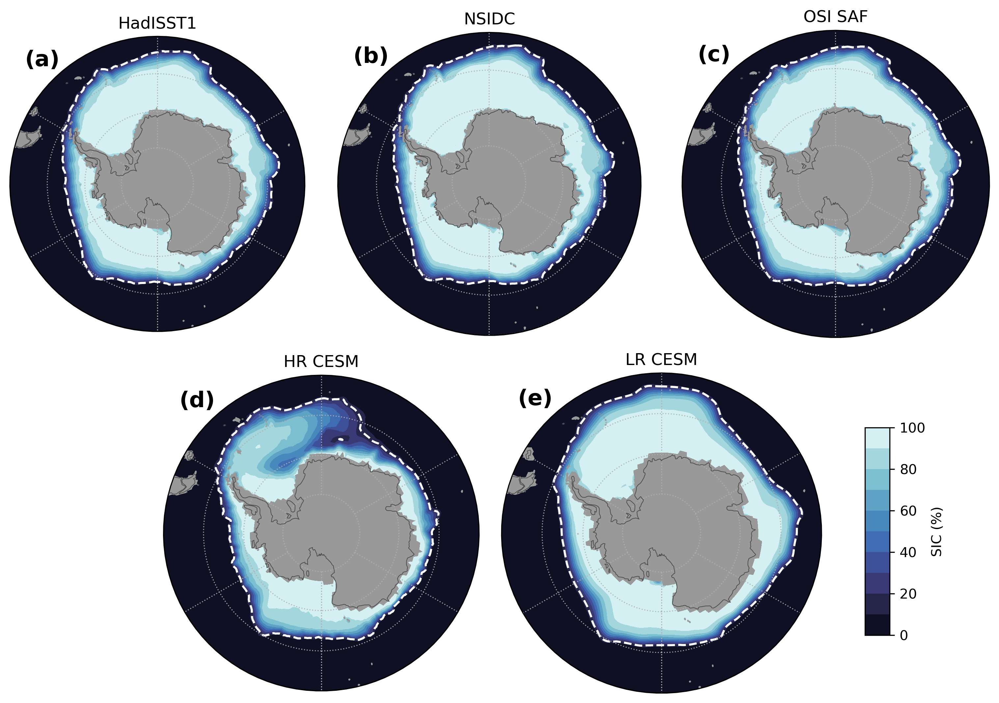

In [326]:
sp_proj = ccrs.SouthPolarStereo()

fig2 = plt.figure(2, figsize=(10, 7), dpi=300, layout='constrained')
spec = fig2.add_gridspec(2, 6)
ax1 = fig2.add_subplot(spec[0, 0:2], projection=sp_proj)
ax2 = fig2.add_subplot(spec[0, 2:4], projection=sp_proj)
ax3 = fig2.add_subplot(spec[0, 4:6], projection=sp_proj)
ax4 = fig2.add_subplot(spec[1, 1:3], projection=sp_proj)
ax5 = fig2.add_subplot(spec[1, 3:5], projection=sp_proj)


sep_plot1 = ax1.contourf(h1_lons_cyc, 
                         h1_sic_sep_clim.latitude.where(h1_sic_sep_clim.latitude <= -50, drop=True), 
                         h1_sic_sep_clim_cyc, transform=ccrs.PlateCarree(), cmap=cmocean.cm.ice, levels=np.arange(0., 101., 10))
ax1.contour(h1_lons_cyc, 
             h1_sic_sep_clim.latitude.where(h1_sic_sep_clim.latitude <= -50, drop=True), 
             h1_sic_sep_clim_cyc, transform=ccrs.PlateCarree(), colors='w', levels=[15], linestyles='--')
aa_plot_details(ax1)
ax1.set_title('HadISST1')

ax2_lon, ax2_lat, nsidc_sep_clim_plotting = z_masked_overlap(ax2, nsidc_sep_clim.lon.data, nsidc_sep_clim.lat.data, 100*nsidc_sep_clim.data, source_projection=ccrs.Geodetic())
ax2.set_title('NSIDC')
ax2.contourf(ax2_lon, ax2_lat, nsidc_sep_clim_plotting, cmap=cmocean.cm.ice, levels=np.arange(0., 101., 10))
ax2.contour(ax2_lon, ax2_lat, nsidc_sep_clim_plotting, colors='w', levels=[15], linestyles='--')
aa_plot_details(ax2)
ax2.add_patch(Polygon(xy=([60, -55], [60, -45], [390, -45], [390, -55]), facecolor=cmocean.cm.ice(0.05), edgecolor='none', zorder=-1, transform=ccrs.PlateCarree()))
ax2.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())

ax3_lon, ax3_lat, osi_saf_sep_clim_plotting = z_masked_overlap(ax3, osi_saf_sep_clim.lon.data, osi_saf_sep_clim.lat.data, osi_saf_sep_clim.data, source_projection=ccrs.Geodetic())
ax3.set_title('OSI SAF')
ax3.contourf(ax3_lon, ax3_lat, osi_saf_sep_clim_plotting, cmap=cmocean.cm.ice, levels=np.arange(0., 101., 10))
ax3.contour(ax3_lon, ax3_lat, osi_saf_sep_clim_plotting, colors='w', levels=[15], linestyles='--')
aa_plot_details(ax3)
ax3.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())

ax4.set_title('HR CESM')
sep_plot4 = ax4.contourf(lons_cyc, lats, hr_sic_sep_clim_em_cyc, transform=ccrs.PlateCarree(), cmap=cmocean.cm.ice, levels=np.arange(0., 101., 10))
ax4.contour(lons_cyc, lats, hr_sic_sep_clim_em_cyc, transform=ccrs.PlateCarree(), colors='w', levels=[15], linestyles='--')
aa_plot_details(ax4)
# ax4.add_patch(Polygon(xy=([60, -60], [60, -45], [390, -45], [390, -60]), facecolor=cmocean.cm.ice(0.05), edgecolor='none', zorder=-1, transform=ccrs.PlateCarree()))

ax5.set_title('LR CESM')
sep_plot5 = ax5.contourf(lons_cyc, lats, lr_sic_sep_clim_em_cyc, transform=ccrs.PlateCarree(), cmap=cmocean.cm.ice, levels=np.arange(0., 101., 10))
ax5.contour(lons_cyc, lats, lr_sic_sep_clim_em_cyc, transform=ccrs.PlateCarree(), colors='w', levels=[15], linestyles='--')
aa_plot_details(ax5)
# ax5.add_patch(Polygon(xy=([60, -60], [60, -45], [390, -45], [390, -60]), facecolor=cmocean.cm.ice(0.05), edgecolor='none', zorder=-1, transform=ccrs.PlateCarree()))

cbar_ax = fig2.add_axes([0.87, 0.09, 0.025, 0.3])
fig2.colorbar(sep_plot5, cax=cbar_ax, orientation='vertical', label='SIC (%)')

# fig2.suptitle('September sea ice concentration (1979–2024 average)')

for label, ax in zip(list('abcde'), [ax1, ax2, ax3, ax4, ax5]):
    ax.annotate('('+label+')', xy=(0.05, 0.9), xycoords='axes fraction', fontweight='bold', fontsize=16)

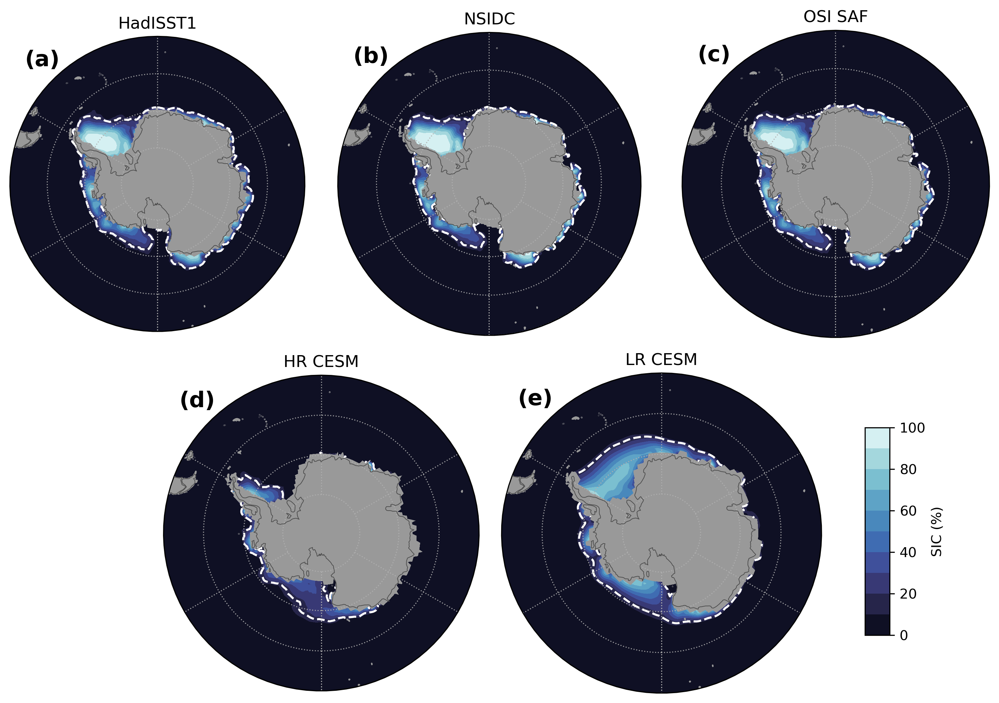

In [327]:
sp_proj = ccrs.SouthPolarStereo()

fig2 = plt.figure(2, figsize=(10, 7), dpi=300, layout='constrained')
spec = fig2.add_gridspec(2, 6)
ax1 = fig2.add_subplot(spec[0, 0:2], projection=sp_proj)
ax2 = fig2.add_subplot(spec[0, 2:4], projection=sp_proj)
ax3 = fig2.add_subplot(spec[0, 4:6], projection=sp_proj)
ax4 = fig2.add_subplot(spec[1, 1:3], projection=sp_proj)
ax5 = fig2.add_subplot(spec[1, 3:5], projection=sp_proj)


feb_plot1 = ax1.contourf(h1_lons_cyc, 
                         h1_sic_feb_clim.latitude.where(h1_sic_feb_clim.latitude <= -50, drop=True), 
                         h1_sic_feb_clim_cyc, transform=ccrs.PlateCarree(), cmap=cmocean.cm.ice, levels=np.arange(0., 101., 10))
ax1.contour(h1_lons_cyc, 
             h1_sic_feb_clim.latitude.where(h1_sic_feb_clim.latitude <= -50, drop=True), 
             h1_sic_feb_clim_cyc, transform=ccrs.PlateCarree(), colors='w', levels=[15], linestyles='--')
aa_plot_details(ax1)
ax1.set_title('HadISST1')

ax2_lon, ax2_lat, nsidc_feb_clim_plotting = z_masked_overlap(ax2, nsidc_feb_clim.lon.data, nsidc_feb_clim.lat.data, 100*nsidc_feb_clim.data, source_projection=ccrs.Geodetic())
ax2.set_title('NSIDC')
ax2.contourf(ax2_lon, ax2_lat, nsidc_feb_clim_plotting, cmap=cmocean.cm.ice, levels=np.arange(0., 101., 10))
ax2.contour(ax2_lon, ax2_lat, nsidc_feb_clim_plotting, colors='w', levels=[15], linestyles='--')
aa_plot_details(ax2)
ax2.add_patch(Polygon(xy=([60, -55], [60, -45], [390, -45], [390, -55]), facecolor=cmocean.cm.ice(0.05), edgecolor='none', zorder=-1, transform=ccrs.PlateCarree()))
ax2.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())

ax3_lon, ax3_lat, osi_saf_feb_clim_plotting = z_masked_overlap(ax3, osi_saf_feb_clim.lon.data, osi_saf_feb_clim.lat.data, osi_saf_feb_clim.data, source_projection=ccrs.Geodetic())
ax3.set_title('OSI SAF')
ax3.contourf(ax3_lon, ax3_lat, osi_saf_feb_clim_plotting, cmap=cmocean.cm.ice, levels=np.arange(0., 101., 10))
ax3.contour(ax3_lon, ax3_lat, osi_saf_feb_clim_plotting, colors='w', levels=[15], linestyles='--')
aa_plot_details(ax3)
ax3.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())

ax4.set_title('HR CESM')
feb_plot4 = ax4.contourf(lons_cyc, lats, hr_sic_feb_clim_em_cyc, transform=ccrs.PlateCarree(), cmap=cmocean.cm.ice, levels=np.arange(0., 101., 10))
ax4.contour(lons_cyc, lats, hr_sic_feb_clim_em_cyc, transform=ccrs.PlateCarree(), colors='w', levels=[15], linestyles='--')
aa_plot_details(ax4)
ax4.add_patch(Polygon(xy=([60, -60], [60, -45], [390, -45], [390, -60]), facecolor=cmocean.cm.ice(0.05), edgecolor='none', zorder=-1, transform=ccrs.PlateCarree()))

ax5.set_title('LR CESM')
feb_plot5 = ax5.contourf(lons_cyc, lats, lr_sic_feb_clim_em_cyc, transform=ccrs.PlateCarree(), cmap=cmocean.cm.ice, levels=np.arange(0., 101., 10))
ax5.contour(lons_cyc, lats, lr_sic_feb_clim_em_cyc, transform=ccrs.PlateCarree(), colors='w', levels=[15], linestyles='--')
aa_plot_details(ax5)
ax5.add_patch(Polygon(xy=([60, -60], [60, -45], [390, -45], [390, -60]), facecolor=cmocean.cm.ice(0.05), edgecolor='none', zorder=-1, transform=ccrs.PlateCarree()))

cbar_ax = fig2.add_axes([0.87, 0.09, 0.025, 0.3])
fig2.colorbar(feb_plot5, cax=cbar_ax, orientation='vertical', label='SIC (%)')

# fig2.suptitle('February sea ice concentration (1979–2024 average)')

for label, ax in zip(list('abcde'), [ax1, ax2, ax3, ax4, ax5]):
    ax.annotate('('+label+')', xy=(0.05, 0.9), xycoords='axes fraction', fontweight='bold', fontsize=16)

## Figure 4: SIA time series

In [89]:
hr_aasia_ann_mean = hr_aasia_ann.isel(time=slice(None, -1)).mean(dim='ens_member')
hr_aasia_ann_max = hr_aasia_ann.isel(time=slice(None, -1)).max(dim='ens_member')
hr_aasia_ann_min = hr_aasia_ann.isel(time=slice(None, -1)).min(dim='ens_member')
hr_aasia_ann_std = hr_aasia_ann.isel(time=slice(None, -1)).std(dim='ens_member')

In [90]:
hr_aasia_sep_mean = hr_aasia_sep.isel(time=slice(None, -1)).mean(dim='ens_member')
hr_aasia_sep_max = hr_aasia_sep.isel(time=slice(None, -1)).max(dim='ens_member')
hr_aasia_sep_min = hr_aasia_sep.isel(time=slice(None, -1)).min(dim='ens_member')
hr_aasia_sep_std = hr_aasia_sep.isel(time=slice(None, -1)).std(dim='ens_member')

In [91]:
hr_aasia_feb_mean = hr_aasia_feb.isel(time=slice(None, -1)).mean(dim='ens_member')
hr_aasia_feb_max = hr_aasia_feb.isel(time=slice(None, -1)).max(dim='ens_member')
hr_aasia_feb_min = hr_aasia_feb.isel(time=slice(None, -1)).min(dim='ens_member')
hr_aasia_feb_std = hr_aasia_feb.isel(time=slice(None, -1)).std(dim='ens_member')

In [92]:
lr_aasia_ann_mean = lr_aasia_ann.isel(time=slice(None, -1)).mean(dim='ens_member')
lr_aasia_ann_max = lr_aasia_ann.isel(time=slice(None, -1)).max(dim='ens_member')
lr_aasia_ann_min = lr_aasia_ann.isel(time=slice(None, -1)).min(dim='ens_member')
lr_aasia_ann_std = lr_aasia_ann.isel(time=slice(None, -1)).std(dim='ens_member')

In [93]:
lr_aasia_sep_mean = lr_aasia_sep.isel(time=slice(None, -1)).mean(dim='ens_member')
lr_aasia_sep_max = lr_aasia_sep.isel(time=slice(None, -1)).max(dim='ens_member')
lr_aasia_sep_min = lr_aasia_sep.isel(time=slice(None, -1)).min(dim='ens_member')
lr_aasia_sep_std = lr_aasia_sep.isel(time=slice(None, -1)).std(dim='ens_member')

In [94]:
lr_aasia_feb_mean = lr_aasia_feb.isel(time=slice(None, -1)).mean(dim='ens_member')
lr_aasia_feb_max = lr_aasia_feb.isel(time=slice(None, -1)).max(dim='ens_member')
lr_aasia_feb_min = lr_aasia_feb.isel(time=slice(None, -1)).min(dim='ens_member')
lr_aasia_feb_std = lr_aasia_feb.isel(time=slice(None, -1)).std(dim='ens_member')

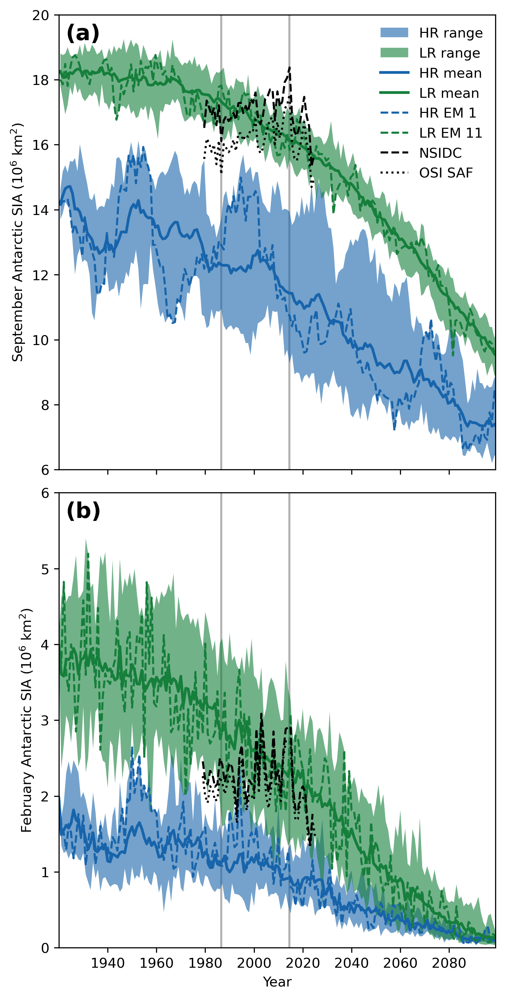

In [329]:
fig, (ax1, ax2) = plt.subplots(2, 1, dpi=300, figsize=(5, 10), constrained_layout=True, sharex=True)

ax1.fill_between(hr_aasia_sep_max.time.values, hr_aasia_sep_min, hr_aasia_sep_max, color=blues(0.8), alpha=0.6, zorder=0, edgecolor=None, label='HR range')
ax1.fill_between(lr_aasia_sep_max.time.values, lr_aasia_sep_min, lr_aasia_sep_max, color=greens(0.8), alpha=0.6, zorder=0, edgecolor=None, label='LR range')

ax1.plot(hr_aasia_sep_mean.time, hr_aasia_sep_mean, color=blues(0.8), linewidth=2, label='HR mean')
ax1.plot(lr_aasia_sep_mean.time, lr_aasia_sep_mean, color=greens(0.8), linewidth=2, label='LR mean')

ax1.plot(hr_aasia_sep.time, hr_aasia_sep.isel(ens_member=0), color=blues(0.8), linewidth=1.5, linestyle='--', label='HR EM 1')
ax1.plot(lr_aasia_sep.time, lr_aasia_sep.isel(ens_member=10), color=greens(0.8), linewidth=1.5, linestyle='--', label='LR EM 11')

ax1.plot(hr_aasia_sep.time.sel(time=slice('1979', '2024')), nsidc_aasia_sep.sel(time=slice('1979', '2024')), color='k', linestyle='--', linewidth=1.5, label='NSIDC')
ax1.plot(hr_aasia_sep.time.sel(time=slice('1979', '2024')), osi_saf_aasia_sep, color='k', linestyle=':', linewidth=1.5, label='OSI SAF')

#################################

ax2.plot(hr_aasia_feb_mean.time, hr_aasia_feb_mean, color=blues(0.8), linewidth=2)
ax2.plot(hr_aasia_feb.time, hr_aasia_feb.isel(ens_member=0), color=blues(0.8), linewidth=1.5, linestyle='--')
ax2.fill_between(hr_aasia_feb_max.time.values, hr_aasia_feb_min, hr_aasia_feb_max, color=blues(0.8), alpha=0.6, zorder=0, edgecolor=None)


ax2.plot(lr_aasia_feb_mean.time, lr_aasia_feb_mean, color=greens(0.8), linewidth=2)
ax2.plot(lr_aasia_feb.time, lr_aasia_feb.isel(ens_member=10), color=greens(0.8), linewidth=1.5, linestyle='--')
ax2.fill_between(lr_aasia_feb_max.time.values, lr_aasia_feb_min, lr_aasia_feb_max, color=greens(0.8), alpha=0.6, zorder=0, edgecolor=None)

ax2.plot(hr_aasia_feb.time.sel(time=slice('1979', '2025')), osi_saf_aasia_feb, color='k', linestyle=':', linewidth=1.5)
ax2.plot(hr_aasia_feb.time.sel(time=slice('1979', '2024')), nsidc_aasia_feb.sel(time=slice('1979', '2024')), color='k', linestyle='--', linewidth=1.5)

###############################

ax2.set_xlim(hr_aasia_feb.time.min().values, hr_aasia_feb_mean.time.max().values)

ax1.set_ylabel('September Antarctic SIA (10$^6$ km$^2$)')
ax2.set_ylabel('February Antarctic SIA (10$^6$ km$^2$)')
ax2.set_xlabel('Year')
ax2.set_xticks(hr_aasia_feb.time.sel(time=hr_aasia_feb.time.dt.year.isin(np.arange(1940, 2100, 20))).values, 
               hr_aasia_feb.time.sel(time=hr_aasia_feb.time.dt.year.isin(np.arange(1940, 2100, 20))).dt.year.values);

for ax in [ax1, ax2]:
    ax.axvline(hr_aasia.time.sel(time='1986-09').values[0], color='k', alpha=0.3, zorder=-1)
    ax.axvline(hr_aasia.time.sel(time='2014-09').values[0], color='k', alpha=0.3, zorder=-1)

ax1.set_ylim(6, 20)
ax2.set_ylim(0, 6)

ax1.legend(ncols=1, framealpha=0, fancybox=False)

for label, ax in zip(list('ab'), [ax1, ax2]):
    ax.annotate('('+label+')', xy=(0.015, 0.945), xycoords='axes fraction', fontweight='bold', fontsize=16)

## Figure 5: spectra

In [96]:
def power_spectrum(series, dt=1.0):
    """Return positive-frequency periods (days) and explained variance (%)."""
    x = series - np.mean(series)
    n = len(x)
    freqs = np.fft.rfftfreq(n, d=dt)
    coeffs = np.fft.rfft(x)
    power = np.abs(coeffs) ** 2

    var = np.var(x)
    pct_var = 100.0 * power / power.sum() if power.sum() > 0 else power

    with np.errstate(divide="ignore"):
        periods = np.where(freqs > 0, 1.0 / freqs, np.inf)

    mask = freqs > 0
    return periods[mask], power[mask], var

In [97]:
hr_aasia_sep_dt = detrend_dim(hr_aasia_sep, dim='time', deg=2)

In [98]:
hr_aasia_feb_dt = detrend_dim(hr_aasia_feb, dim='time', deg=2)

In [99]:
hr_aasia_dt = detrend_dim(hr_aasia, dim='time', deg=2)

In [100]:
lr_aasia_sep_dt = detrend_dim(lr_aasia_sep, dim='time', deg=2)

In [101]:
lr_aasia_feb_dt = detrend_dim(lr_aasia_feb, dim='time', deg=2)

In [102]:
lr_aasia_dt = detrend_dim(lr_aasia, dim='time', deg=2)

In [103]:
nsidc_aasia_sep_dt = detrend_dim(nsidc_aasia_sep, dim='time', deg=1)
osi_saf_aasia_sep_dt = detrend_dim(osi_saf_aasia_sep, dim='time', deg=1)

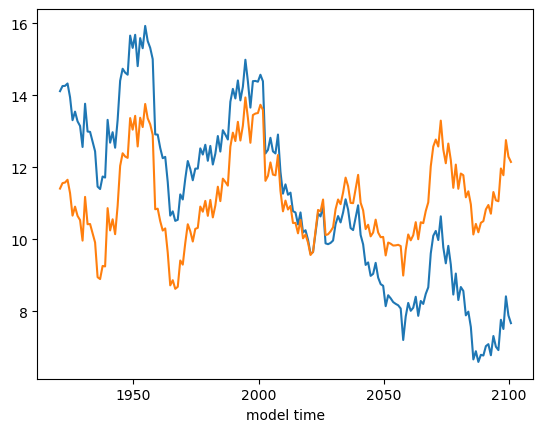

In [104]:
hr_aasia_sep.isel(ens_member=0).plot()
hr_aasia_sep_dt.isel(ens_member=0).plot()

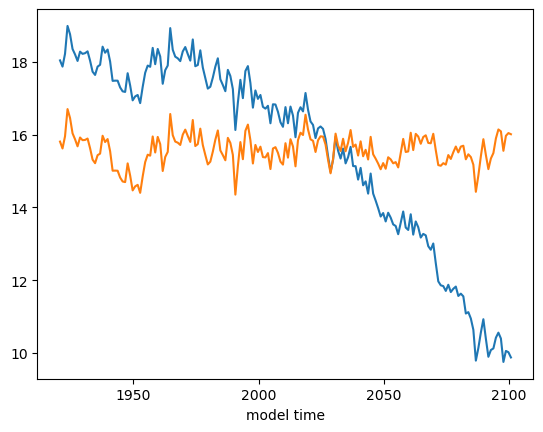

In [105]:
lr_aasia_sep.isel(ens_member=5).plot()
lr_aasia_sep_dt.isel(ens_member=5).plot()

In [106]:
test_period, test_hr_spec, test_hr_var = power_spectrum(hr_aasia_sep_dt.isel(ens_member=0), dt=1)
test_period2, test_lr_spec, test_lr_var = power_spectrum(lr_aasia_sep_dt.isel(ens_member=5), dt=1)

In [107]:
test_hr_var, test_lr_var

(<xarray.DataArray ()> Size: 8B
 array(1.45145437),
 <xarray.DataArray ()> Size: 8B
 array(0.17633259))

In [108]:
np.nansum(test_hr_spec), np.nansum(test_lr_spec)

(np.float64(23775.54827220852), np.float64(2888.4160397289666))

In [109]:
np.nansum(np.where((test_period >= 2) & (test_period <= 10), test_hr_spec, np.nan)), np.nansum(np.where((test_period2 >= 2) & (test_period2 <= 10), test_lr_spec, np.nan))

(np.float64(2003.5733352212526), np.float64(1130.2934570432085))

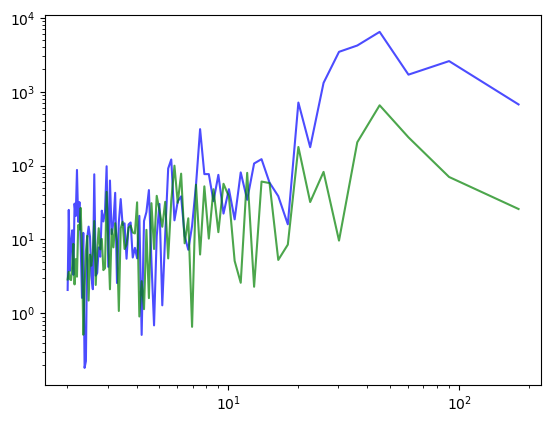

In [110]:
plt.plot(test_period, test_hr_spec, color='b', alpha=0.7)
plt.plot(test_period2, test_lr_spec, color='g', alpha=0.7)
plt.xscale('log')
plt.yscale('log')
# plt.xlim(0.166, 2)

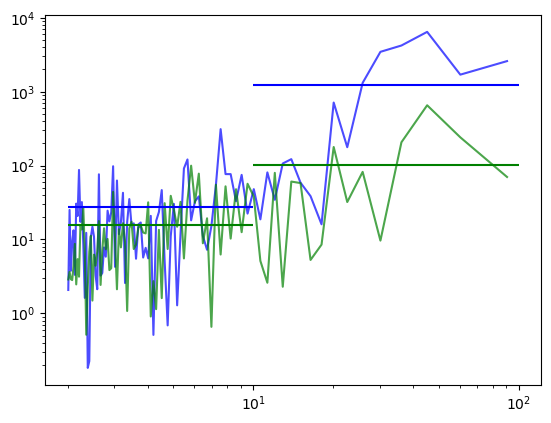

In [111]:
plt.plot(test_period, np.where((test_period >= 2) & (test_period <= 100), test_hr_spec, np.nan), color='b', alpha=0.7)
plt.plot(test_period2, np.where((test_period2 >= 2) & (test_period2 <= 100), test_lr_spec, np.nan), color='g', alpha=0.7)

plt.hlines(np.nanmean(np.where((test_period >= 2) & (test_period <= 10), test_hr_spec, np.nan)), color='b', xmin=2, xmax=10)
plt.hlines(np.nanmean(np.where((test_period2 >= 2) & (test_period2 <= 10), test_lr_spec, np.nan)), color='g', xmin=2, xmax=10)
plt.hlines(np.nanmean(np.where((test_period >= 10) & (test_period <= 100), test_hr_spec, np.nan)), color='b', xmin=10, xmax=100)
plt.hlines(np.nanmean(np.where((test_period2 >= 10) & (test_period2 <= 100), test_lr_spec, np.nan)), color='g', xmin=10, xmax=100)

plt.xscale('log')
plt.yscale('log')

Anomalies instead of just September?

In [112]:
hr_aasia_anom_dt = deseasonalize(detrend_dim(hr_aasia.sel(time=slice(None, '2025-08')), dim='time', deg=1))

In [113]:
lr_aasia_anom_dt = deseasonalize(detrend_dim(lr_aasia.sel(time=slice(None, '2025-08')), dim='time', deg=1))

In [114]:
nsidc_aasia_anom_dt = deseasonalize(detrend_dim(nsidc_aasia.sel(time=slice('1978-11', '2025-08')), dim='time', deg=1))
osi_saf_aasia_anom_dt = deseasonalize(detrend_dim(osi_saf_aasia.sel(time=slice('1978-11', '2025-08')), dim='time', deg=1))

In [115]:
nsidc_aasia_anom_dt.shape, osi_saf_aasia_anom_dt.shape

((562,), (562,))

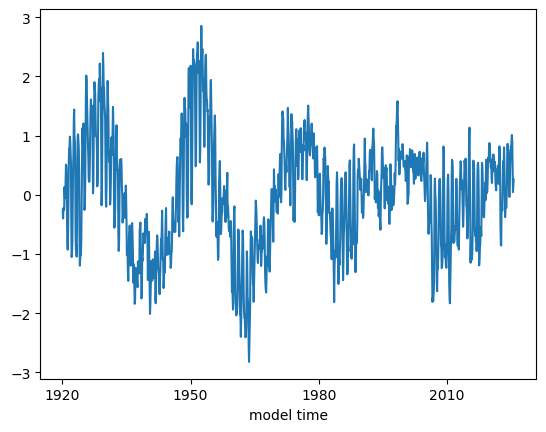

In [116]:
hr_aasia_anom_dt.isel(ens_member=4).plot()

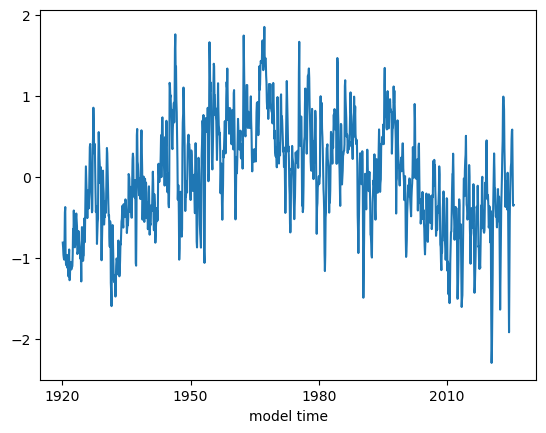

In [117]:
lr_aasia_anom_dt.isel(ens_member=1).plot()

Rolling means:

In [118]:
hr_aasia_12mrm_dt = detrend_dim(hr_aasia.sel(time=slice(None, '2025-08')).rolling(time=12, center=True).mean().dropna('time'), 'time', deg=2)

In [119]:
lr_aasia_12mrm_dt = detrend_dim(lr_aasia.sel(time=slice(None, '2025-08')).rolling(time=12, center=True).mean().dropna('time'), 'time', deg=2)

In [120]:
nsidc_aasia_12mrm_dt = detrend_dim(nsidc_aasia.sel(time=slice('1978-11', '2025-08')).rolling(time=12, center=True).mean().dropna('time'), dim='time', deg=1)
osi_saf_aasia_12mrm_dt = detrend_dim(osi_saf_aasia.sel(time=slice('1978-11', '2025-08')).rolling(time=12, center=True).mean().dropna('time'), dim='time', deg=1)

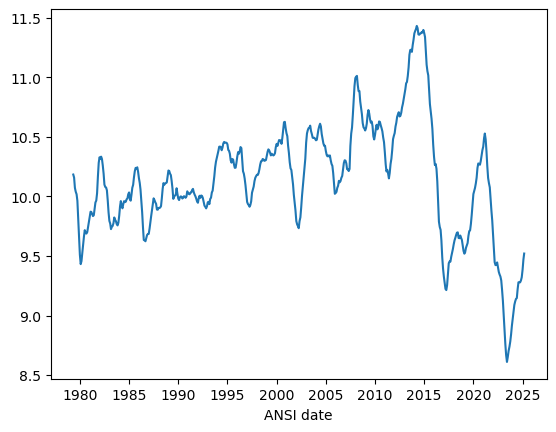

In [121]:
nsidc_aasia_12mrm_dt.plot()

Computing spectra:

In [122]:
# model_nperseg = 200
# obs_nperseg = 200
# scaling_type = 'spectrum'

# hr_test_freq, hr_test_power = welch(hr_aasia_anom_dt.isel(ens_member=0), fs=12, scaling=scaling_type, nperseg=model_nperseg)
# hr_powers = np.zeros((len(hr_aasia_anom_dt.ens_member), len(hr_test_power)))
# for e in range(len(hr_aasia_anom_dt.ens_member)):
#     hr_freq, hr_power = welch(hr_aasia_anom_dt.isel(ens_member=e), fs=12, scaling=scaling_type, nperseg=model_nperseg)
#     hr_powers[e] = hr_power

# lr_test_freq, lr_test_power = welch(lr_aasia_anom_dt.isel(ens_member=0), fs=12, scaling=scaling_type, nperseg=model_nperseg)
# lr_powers = np.zeros((len(lr_aasia_anom_dt.ens_member), len(lr_test_power)))
# for e in range(len(lr_aasia_anom_dt.ens_member)):
#     lr_freq, lr_power = welch(lr_aasia_anom_dt.isel(ens_member=e), fs=12, scaling=scaling_type, nperseg=model_nperseg)
#     lr_powers[e] = lr_power

nsidc_freq_welch, nsidc_power_welch = welch(nsidc_aasia_12mrm_dt, fs=12, scaling='density', nperseg=200)
osi_saf_freq_welch, osi_saf_power_welch = welch(osi_saf_aasia_12mrm_dt, fs=12, scaling='density', nperseg=200)

# hr_power_mean = hr_powers.mean(axis=0)
# lr_power_mean = lr_powers.mean(axis=0)
# obs_mean_power = (osi_saf_power + nsidc_power)/2

In [123]:
# scaling_type = 'density'
# hr_test_freq, hr_test_power = periodogram(hr_aasia_anom_dt.isel(ens_member=0), fs=12, scaling=scaling_type)
# hr_powers = np.zeros((len(hr_aasia_anom_dt.ens_member), len(hr_test_power)))
# for e in range(len(hr_aasia_anom_dt.ens_member)):
#     hr_freq, hr_power = periodogram(hr_aasia_anom_dt.isel(ens_member=e), fs=12, scaling=scaling_type)
#     hr_powers[e] = hr_power

# lr_test_freq, lr_test_power = periodogram(lr_aasia_anom_dt.isel(ens_member=0), fs=12, scaling=scaling_type)
# lr_powers = np.zeros((len(lr_aasia_anom_dt.ens_member), len(lr_test_power)))
# for e in range(len(lr_aasia_dt.ens_member)):
#     lr_freq, lr_power = periodogram(lr_aasia_anom_dt.isel(ens_member=e), fs=12, scaling=scaling_type)
#     lr_powers[e] = lr_power

# nsidc_freq, nsidc_power = periodogram(nsidc_aasia_anom_dt, fs=12, scaling=scaling_type)
# osi_saf_freq, osi_saf_power = periodogram(osi_saf_aasia_anom_dt, fs=12, scaling=scaling_type)

# hr_power_mean = hr_powers.mean(axis=0)
# lr_power_mean = lr_powers.mean(axis=0)
# # obs_mean_power = (osi_saf_power + nsidc_power)/2

In [124]:
nw = 3.5
kspec = 6
hr_test_mtobj = MTSpec(hr_aasia_12mrm_dt.isel(ens_member=0).values, dt=1/12, nw=nw, kspec=kspec)
hr_test_freq, hr_test_power = hr_test_mtobj.rspec()
hr_test_jk95 = hr_test_mtobj.jackspec()
_, hr_test_jk95 = hr_test_mtobj.rspec(hr_test_jk95)

hr_powers = np.zeros((len(hr_aasia_12mrm_dt.ens_member), len(hr_test_power)))
hr_jk95s = np.zeros((len(hr_aasia_12mrm_dt.ens_member), len(hr_test_power), 2))
for e in range(len(hr_aasia_12mrm_dt.ens_member)):
    hr_mtobj = MTSpec(hr_aasia_12mrm_dt.isel(ens_member=e).values, dt=1/12, nw=nw, kspec=kspec)
    hr_freq, hr_power = hr_mtobj.rspec()
    hr_jk95 = hr_mtobj.jackspec()
    _, hr_jk95 = hr_mtobj.rspec(hr_jk95)
    hr_powers[e] = hr_power[:, 0]
    hr_jk95s[e] = hr_jk95

lr_test_mtobj = MTSpec(lr_aasia_12mrm_dt.isel(ens_member=0).values, dt=1/12, nw=nw, kspec=kspec)
lr_test_freq, lr_test_power = lr_test_mtobj.rspec()
lr_test_jk95 = lr_test_mtobj.jackspec()
_, lr_test_jk95 = lr_test_mtobj.rspec(lr_test_jk95)

lr_powers = np.zeros((len(lr_aasia_12mrm_dt.ens_member), len(lr_test_power)))
lr_jk95s = np.zeros((len(lr_aasia_12mrm_dt.ens_member), len(lr_test_power), 2))
for e in range(len(lr_aasia_dt.ens_member)):
    lr_mtobj = MTSpec(lr_aasia_12mrm_dt.isel(ens_member=e).values, dt=1/12, nw=nw, kspec=kspec)
    lr_freq, lr_power = lr_mtobj.rspec()
    lr_jk95 = lr_mtobj.jackspec()
    _, lr_jk95 = lr_mtobj.rspec(lr_jk95)
    lr_powers[e] = lr_power[:, 0]
    lr_jk95s[e] = lr_jk95

hr_power_mean = hr_powers.mean(axis=0)
lr_power_mean = lr_powers.mean(axis=0)

In [125]:
nsidc_mtobj = MTSpec(nsidc_aasia_12mrm_dt.values, dt=1/12, nw=nw, kspec=kspec)
nsidc_freq, nsidc_power = nsidc_mtobj.rspec()
nsidc_jk95 = nsidc_mtobj.jackspec()
_, nsidc_jk95 = nsidc_mtobj.rspec(nsidc_jk95)

In [126]:
osi_saf_mtobj = MTSpec(osi_saf_aasia_12mrm_dt.values, dt=1/12, nw=nw, kspec=kspec)
osi_saf_freq, osi_saf_power = osi_saf_mtobj.rspec()
osi_saf_jk95 = osi_saf_mtobj.jackspec()
_, osi_saf_jk95 = osi_saf_mtobj.rspec(osi_saf_jk95)

In [127]:
lr_power_mean

array([4.47767637e-01, 9.06686736e-01, 8.91595029e-01, ...,
       4.10980250e-08, 2.69197803e-08, 2.04269429e-08], shape=(1256,))

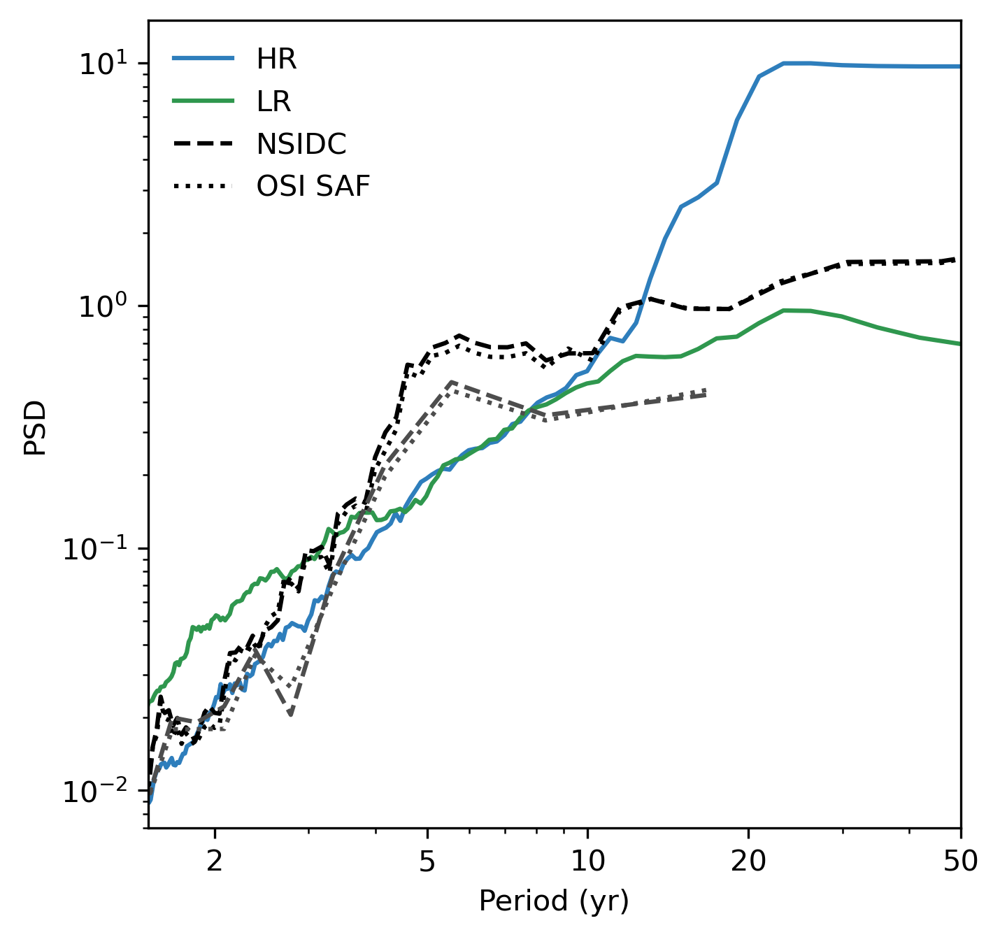

In [330]:
plt.figure(dpi=300, figsize=(5, 5))

# plt.fill_between(1/hr_test_freq[:, 0], np.mean(hr_jk95s[:, :, 0], axis=0), np.mean(hr_jk95s[:, :, 1], axis=0), color=blues(0.8), alpha=0.6, edgecolor='none', label='HR 95% CI')
# plt.fill_between(1/lr_test_freq[:, 0], np.mean(lr_jk95s[:, :, 0], axis=0), np.mean(lr_jk95s[:, :, 1], axis=0), color=greens(0.8), alpha=0.6, edgecolor='none', label='LR 95% CI')

plt.loglog(1/hr_test_freq, hr_power_mean, color=blues(0.7), label='HR')
plt.loglog(1/lr_test_freq, lr_power_mean, color=greens(0.7), label='LR')

plt.plot(1/nsidc_freq, nsidc_power, color='k', linestyle='--', label='NSIDC')
plt.plot(1/osi_saf_freq, osi_saf_power, color='k', linestyle=':', label='OSI SAF')
plt.plot(1/nsidc_freq_welch, nsidc_power_welch, color='0.3', linestyle='--')
plt.plot(1/osi_saf_freq_welch, osi_saf_power_welch, color='0.3', linestyle=':')
# plt.fill_between(1/nsidc_freq[:, 0], nsidc_jk95[:, 0], nsidc_jk95[:, 1], color='k', alpha=0.6, edgecolor='none', label='Obs. 95% CI')
# plt.fill_between(1/osi_saf_freq[:, 0], osi_saf_jk95[:, 0], osi_saf_jk95[:, 1], color='k', alpha=0.6, edgecolor='none', label='Obs. 95% CI')

plt.legend(loc='upper left', framealpha=0, fancybox=False)
plt.xlim(1.5, 50)
plt.ylim(0.7e-2, 1.5e1)
plt.xlabel('Period (yr)')
plt.ylabel('PSD')
plt.xticks([2, 5, 10, 20, 50], [2, 5, 10, 20, 50]);

## Figure 6: trend histograms

In [129]:
w_length = 29

In [130]:
# hr_aasia_window = hr_aasia_ann.rolling(time=w_length).construct(window_dim='window')
hr_aasia_window_sep = hr_aasia_sep.sel(time=slice('1950', '2014')).rolling(time=w_length).construct(window_dim='window')
hr_aasia_window_feb = hr_aasia_feb.sel(time=slice('1950', '2014')).rolling(time=w_length).construct(window_dim='window')

In [131]:
# lr_aasia_window = lr_aasia_ann.rolling(time=w_length).construct(window_dim='window')
lr_aasia_window_sep = lr_aasia_sep.sel(time=slice('1930', '2014')).rolling(time=w_length).construct(window_dim='window')
lr_aasia_window_feb = lr_aasia_feb.sel(time=slice('1930', '2014')).rolling(time=w_length).construct(window_dim='window')

In [132]:
# hr_all_trends = hr_aasia_window.sel(time=slice(None, '2024')).polyfit(dim='window', deg=1, skipna=False).dropna(dim='time').isel(degree=0).polyfit_coefficients
hr_all_trends_sep = hr_aasia_window_sep.polyfit(dim='window', deg=1, skipna=False).dropna(dim='time').isel(degree=0).polyfit_coefficients
hr_all_trends_feb = hr_aasia_window_feb.polyfit(dim='window', deg=1, skipna=False).dropna(dim='time').isel(degree=0).polyfit_coefficients

In [133]:
hr_all_trends_sep_fc = hr_all_trends_sep - hr_all_trends_sep.mean(dim='ens_member')
hr_all_trends_feb_fc = hr_all_trends_feb - hr_all_trends_feb.mean(dim='ens_member')

(array([28., 47., 36., 39., 50., 47., 36., 32., 36., 19.]),
 array([-0.2110008 , -0.17342835, -0.13585589, -0.09828344, -0.06071098,
        -0.02313853,  0.01443393,  0.05200638,  0.08957884,  0.12715129,
         0.16472375]),
 <BarContainer object of 10 artists>)

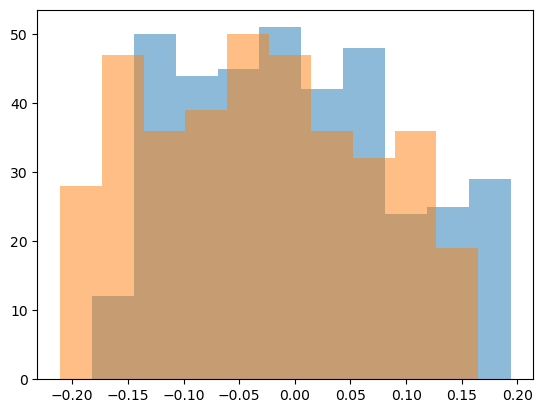

In [134]:
plt.hist(hr_all_trends_sep_fc.values.flatten(), alpha=0.5)
plt.hist(hr_all_trends_sep.values.flatten(), alpha=0.5)

(array([20., 36., 38., 49., 66., 46., 39., 32., 27., 17.]),
 array([-0.04092105, -0.03402053, -0.02712002, -0.0202195 , -0.01331899,
        -0.00641847,  0.00048204,  0.00738256,  0.01428307,  0.02118358,
         0.0280841 ]),
 <BarContainer object of 10 artists>)

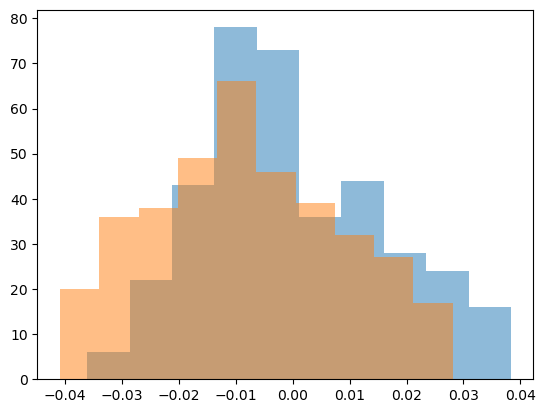

In [135]:
plt.hist(hr_all_trends_feb_fc.values.flatten(), alpha=0.5)
plt.hist(hr_all_trends_feb.values.flatten(), alpha=0.5)

In [136]:
hr_n_total_samples = hr_all_trends_sep_fc.values.flatten().shape[0]
hr_n_total_samples

370

In [137]:
# lr_all_trends = lr_aasia_window.sel(time=slice(None, '2024')).polyfit(dim='window', deg=1, skipna=False).dropna(dim='time').isel(degree=0).polyfit_coefficients
lr_all_trends_sep = lr_aasia_window_sep.polyfit(dim='window', deg=1, skipna=False).dropna(dim='time').isel(degree=0).polyfit_coefficients
lr_all_trends_feb = lr_aasia_window_feb.polyfit(dim='window', deg=1, skipna=False).dropna(dim='time').isel(degree=0).polyfit_coefficients

In [138]:
lr_all_trends_sep_fc = lr_all_trends_sep - lr_all_trends_sep.mean(dim='ens_member')
lr_all_trends_feb_fc = lr_all_trends_feb - lr_all_trends_feb.mean(dim='ens_member')

(array([28., 47., 36., 39., 50., 47., 36., 32., 36., 19.]),
 array([-0.2110008 , -0.17342835, -0.13585589, -0.09828344, -0.06071098,
        -0.02313853,  0.01443393,  0.05200638,  0.08957884,  0.12715129,
         0.16472375]),
 <BarContainer object of 10 artists>)

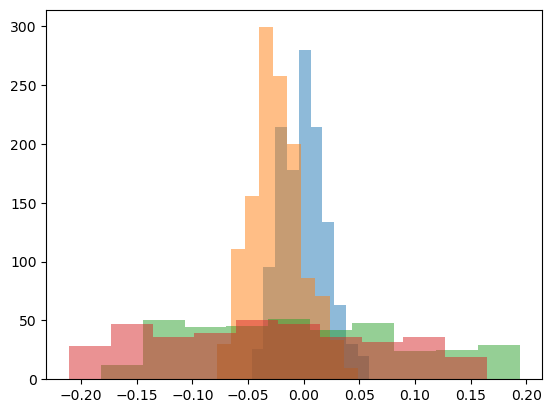

In [139]:
plt.hist(lr_all_trends_sep_fc.values.flatten(), alpha=0.5)
plt.hist(lr_all_trends_sep.values.flatten(), alpha=0.5)

plt.hist(hr_all_trends_sep_fc.values.flatten(), alpha=0.5)
plt.hist(hr_all_trends_sep.values.flatten(), alpha=0.5)

(array([ 17.,  92., 182., 194., 295., 217., 152.,  59.,  35.,  11.]),
 array([-0.06495702, -0.05452483, -0.04409263, -0.03366044, -0.02322824,
        -0.01279605, -0.00236385,  0.00806834,  0.01850054,  0.02893273,
         0.03936492]),
 <BarContainer object of 10 artists>)

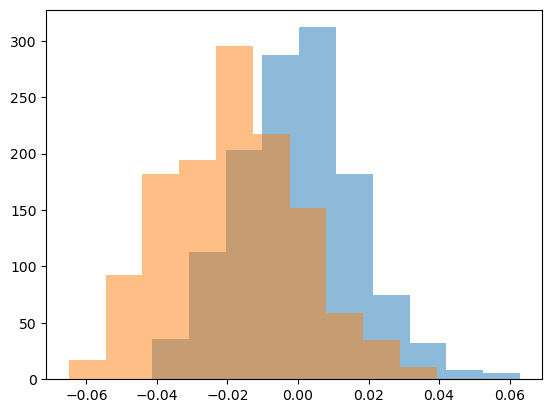

In [140]:
plt.hist(lr_all_trends_feb_fc.values.flatten(), alpha=0.5)
plt.hist(lr_all_trends_feb.values.flatten(), alpha=0.5)

In [141]:
lr_n_total_samples = lr_all_trends_feb_fc.values.flatten().shape[0]
lr_n_total_samples

1254

1986-2014 trends:

In [142]:
hr_1986_2014_sep_trends = ns_per_dec*hr_aasia_sep.sel(time=slice('1986', '2014')).polyfit(dim='time', deg=1, full=True).polyfit_coefficients.sel(degree=1)
lr_1986_2014_sep_trends = ns_per_dec*lr_aasia_sep.sel(time=slice('1986', '2014')).polyfit(dim='time', deg=1, full=True).polyfit_coefficients.sel(degree=1)

hr_1986_2014_feb_trends = ns_per_dec*hr_aasia_feb.sel(time=slice('1986', '2014')).polyfit(dim='time', deg=1, full=True).polyfit_coefficients.sel(degree=1)
lr_1986_2014_feb_trends = ns_per_dec*lr_aasia_feb.sel(time=slice('1986', '2014')).polyfit(dim='time', deg=1, full=True).polyfit_coefficients.sel(degree=1)

In [143]:
hr_1986_2014_sep_trends_fc = hr_1986_2014_sep_trends - hr_1986_2014_sep_trends.mean(dim='ens_member')
lr_1986_2014_sep_trends_fc = lr_1986_2014_sep_trends - lr_1986_2014_sep_trends.mean(dim='ens_member')

hr_1986_2014_feb_trends_fc = hr_1986_2014_feb_trends - hr_1986_2014_feb_trends.mean(dim='ens_member')
lr_1986_2014_feb_trends_fc = lr_1986_2014_feb_trends - lr_1986_2014_feb_trends.mean(dim='ens_member')

In [144]:
# nsidc_incr_regr = nsidc_aasia_ann.sel(time=slice('1986', '2014')).polyfit(dim='time', deg=1, full=True)
nsidc_incr_regr_sep = nsidc_aasia_sep.sel(time=slice('1986', '2014')).polyfit(dim='time', deg=1, full=True)
nsidc_incr_regr_feb = nsidc_aasia_feb.sel(time=slice('1986', '2014')).polyfit(dim='time', deg=1, full=True)

# nsidc_incr_trend = nsidc_incr_regr.isel(degree=0).polyfit_coefficients
nsidc_incr_trend_sep = nsidc_incr_regr_sep.isel(degree=0).polyfit_coefficients
nsidc_incr_trend_feb = nsidc_incr_regr_feb.isel(degree=0).polyfit_coefficients

# nsidc_decr_regr = nsidc_aasia_ann.sel(time=slice('2014', None)).polyfit(dim='time', deg=1, full=True)
nsidc_decr_regr_sep = nsidc_aasia_sep.sel(time=slice('2014', None)).polyfit(dim='time', deg=1, full=True)
nsidc_decr_regr_feb = nsidc_aasia_feb.sel(time=slice('2014', None)).polyfit(dim='time', deg=1, full=True)

# nsidc_decr_trend = nsidc_decr_regr.isel(degree=0).polyfit_coefficients
nsidc_decr_trend_sep = nsidc_decr_regr_sep.isel(degree=0).polyfit_coefficients
nsidc_decr_trend_feb = nsidc_decr_regr_feb.isel(degree=0).polyfit_coefficients

In [145]:
# osi_saf_incr_regr = osi_saf_aasia_ann.sel(time=slice(None, '2014')).polyfit(dim='time', deg=1, full=True)
osi_saf_incr_regr_sep = osi_saf_aasia_sep.sel(time=slice('1986', '2014')).polyfit(dim='time', deg=1, full=True)
osi_saf_incr_regr_feb = osi_saf_aasia_feb.sel(time=slice('1986', '2014')).polyfit(dim='time', deg=1, full=True)

# osi_saf_incr_trend = osi_saf_incr_regr.isel(degree=0).polyfit_coefficients
osi_saf_incr_trend_sep = osi_saf_incr_regr_sep.isel(degree=0).polyfit_coefficients
osi_saf_incr_trend_feb = osi_saf_incr_regr_feb.isel(degree=0).polyfit_coefficients

# osi_saf_decr_regr = osi_saf_aasia_ann.sel(time=slice('2014', None)).polyfit(dim='time', deg=1, full=True)
osi_saf_decr_regr_sep = osi_saf_aasia_sep.sel(time=slice('2014', None)).polyfit(dim='time', deg=1, full=True)
osi_saf_decr_regr_feb = osi_saf_aasia_feb.sel(time=slice('2014', None)).polyfit(dim='time', deg=1, full=True)

# osi_saf_decr_trend = osi_saf_decr_regr.isel(degree=0).polyfit_coefficients
osi_saf_decr_trend_sep = osi_saf_decr_regr_sep.isel(degree=0).polyfit_coefficients
osi_saf_decr_trend_feb = osi_saf_decr_regr_feb.isel(degree=0).polyfit_coefficients

In [146]:
osi_saf_incr_regr = osi_saf_sii_ann.sel(time=slice('1986', '2014')).polyfit(dim='time', deg=1, full=True)
osi_saf_incr_trend = osi_saf_incr_regr.isel(degree=0).polyfit_coefficients

In [147]:
nsidc_incr_regr_sep.polyfit_coefficients

<xarray.DataArray 'polyfit_coefficients' (degree: 2)> Size: 16B
array([1.30606087e-18, 1.59397463e+01])
Coordinates:
  * degree   (degree) int64 16B 1 0

### Computing error in observed trends

Compute standard errors of slopes, following Santer et al. (2000, 2008), Stroeve et al. (2012), and Zunz et al. (2013). The effective sample size is corrected by a factor involving the lag-1 autocorrelation.

In [148]:
def compute_trend_with_se(da, adj=True, lon=False):
    # Compute slope in units [da units]/decade
    t_numeric = (da["time"] - da["time"][0]) / np.timedelta64(1, "D")
    da = da.assign_coords(t_numeric=("time", t_numeric.data))
    da_regr_tnumeric = da.polyfit(dim='t_numeric', deg=1, full=True)
    slope = 365*10*da_regr_tnumeric.polyfit_coefficients.sel(degree=1)
    resid = da - xr.polyval(da.t_numeric, da_regr_tnumeric.polyfit_coefficients)
    n_t = len(resid)
    t_mean = da.t_numeric.mean(dim='time')
    t_var = ((da.t_numeric - t_mean)**2).sum(dim='time')

    if adj:
        if lon:
            lon_phi = np.zeros_like(da.lon)
            lon_std = np.zeros_like(da.lon)
            for lon_i in range(len(da.lon)):
                ar1 = ARIMA(endog=resid.isel(lon=lon_i).values, order=(1, 0, 0)).fit()
                lon_phi[lon_i] = ar1.params[1]
                lon_std[lon_i] = np.sqrt(ar1.params[2])
                
            n_eff = n_t*(1 - lon_phi)/(1 + lon_phi)
            adj_se = np.sqrt((resid**2).sum(dim='time')/(n_eff - 2))
            slope_se = 365*10*np.sqrt((adj_se**2)/t_var)
        else:
            ar1 = ARIMA(endog=resid.values, order=(1, 0, 0)).fit()
            phi, std = ar1.params[1], np.sqrt(ar1.params[2]) 
            n_eff = n_t*(1 - phi)/(1 + phi)
            adj_se = np.sqrt((resid**2).sum(dim='time')/(n_eff - 2))
            slope_se = 365*10*np.sqrt((adj_se**2)/t_var)
    else:
        naive_se = np.sqrt((resid**2).sum(dim='time')/(n_t - 2))
        slope_se = 365*10*np.sqrt((naive_se**2)/t_var)

    return slope, slope_se

In [149]:
ns_per_dec*nsidc_incr_trend_sep

<xarray.DataArray 'polyfit_coefficients' ()> Size: 8B
array(0.41187935)
Coordinates:
    degree   int64 8B 1

In [150]:
nsidc_aasia_sep_incr_period = nsidc_aasia_sep.sel(time=slice('1986', '2014'))
osi_saf_aasia_sep_incr_period = osi_saf_aasia_sep.sel(time=slice('1986', '2014'))

In [151]:
nsidc_aasia_feb_incr_period = nsidc_aasia_feb.sel(time=slice('1986', '2014'))
osi_saf_aasia_feb_incr_period = osi_saf_aasia_feb.sel(time=slice('1986', '2014'))

Xarray treats the datetime coordinate differently between `xr.polyval` and `da.polyfit`, so we convert the datetime to numerical days, which will work with both functions:

In [152]:
t_numeric = (nsidc_aasia_sep_incr_period["time"] - nsidc_aasia_sep_incr_period["time"][0]) / np.timedelta64(1, "D")  #days since start

nsidc_aasia_sep_incr_period = nsidc_aasia_sep_incr_period.assign_coords(t_numeric=("time", t_numeric.data))
osi_saf_aasia_sep_incr_period = osi_saf_aasia_sep_incr_period.assign_coords(t_numeric=("time", t_numeric.data))

nsidc_aasia_feb_incr_period = nsidc_aasia_feb_incr_period.assign_coords(t_numeric=("time", t_numeric.data))
osi_saf_aasia_feb_incr_period = osi_saf_aasia_feb_incr_period.assign_coords(t_numeric=("time", t_numeric.data))

In [153]:
osi_saf_aasia_sep_incr_period

<xarray.DataArray 'ice_conc' (time: 29)> Size: 232B
array([15.08714625, 16.01312962, 15.9003775 , 15.76721375, 15.87475606,
       16.15043463, 15.80667206, 16.35506212, 16.34533388, 16.13075375,
       16.291646  , 16.24276925, 16.45571644, 16.433933  , 16.77169825,
       15.92968319, 15.73895544, 15.87624512, 16.25943919, 16.52804094,
       16.78400775, 16.83087244, 16.01228538, 16.69697538, 16.20476088,
       16.52030769, 17.11021069, 17.22392906, 17.54125925])
Coordinates:
  * time       (time) datetime64[ns] 232B 1986-09-16T12:00:00 ... 2014-09-16T...
    t_numeric  (time) float64 232B 0.0 365.0 731.0 ... 9.862e+03 1.023e+04

In [154]:
nsidc_incr_regr_sep_tnumeric = nsidc_aasia_sep_incr_period.polyfit(dim='t_numeric', deg=1, full=True)
osi_saf_incr_regr_sep_tnumeric = osi_saf_aasia_sep_incr_period.polyfit(dim='t_numeric', deg=1, full=True)

nsidc_incr_regr_feb_tnumeric = nsidc_aasia_feb_incr_period.polyfit(dim='t_numeric', deg=1, full=True)
osi_saf_incr_regr_feb_tnumeric = osi_saf_aasia_feb_incr_period.polyfit(dim='t_numeric', deg=1, full=True)

In [155]:
nsidc_incr_sep_resid = nsidc_aasia_sep_incr_period - xr.polyval(nsidc_aasia_sep_incr_period.t_numeric, nsidc_incr_regr_sep_tnumeric.polyfit_coefficients)
osi_saf_incr_sep_resid = osi_saf_aasia_sep_incr_period - xr.polyval(osi_saf_aasia_sep_incr_period.t_numeric, osi_saf_incr_regr_sep_tnumeric.polyfit_coefficients)

nsidc_incr_feb_resid = nsidc_aasia_feb_incr_period - xr.polyval(nsidc_aasia_feb_incr_period.t_numeric, nsidc_incr_regr_feb_tnumeric.polyfit_coefficients)
osi_saf_incr_feb_resid = osi_saf_aasia_feb_incr_period - xr.polyval(osi_saf_aasia_feb_incr_period.t_numeric, osi_saf_incr_regr_feb_tnumeric.polyfit_coefficients)

Same values as before, just with different units:

In [156]:
ns_per_dec*nsidc_incr_regr_sep.polyfit_coefficients[0].values, 365*10*nsidc_incr_regr_sep_tnumeric.polyfit_coefficients[0].values

(np.float64(0.4118793548333698), np.float64(0.41187935483336896))

In [157]:
ns_per_dec*nsidc_incr_regr_feb.polyfit_coefficients[0].values, 365*10*nsidc_incr_regr_feb_tnumeric.polyfit_coefficients[0].values

(np.float64(0.1056161882090459), np.float64(0.10561686907158155))

In [158]:
ns_per_dec*osi_saf_incr_regr_sep.polyfit_coefficients[0].values, 365*10*osi_saf_incr_regr_sep_tnumeric.polyfit_coefficients[0].values

(np.float64(0.4309685138844965), np.float64(0.43096851388449564))

In [159]:
ns_per_dec*osi_saf_incr_regr_feb.polyfit_coefficients[0].values, 365*10*osi_saf_incr_regr_feb_tnumeric.polyfit_coefficients[0].values

(np.float64(0.1203943574972018), np.float64(0.12039598673239424))

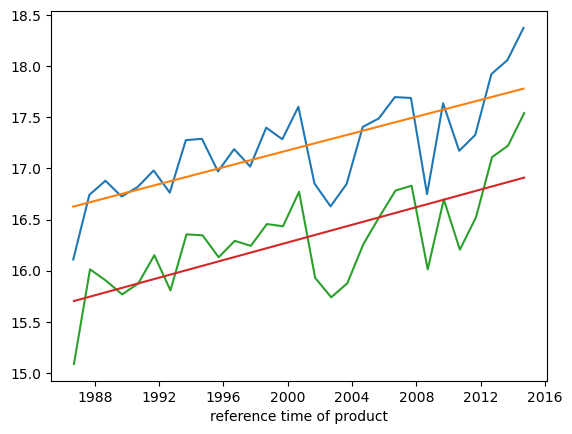

In [160]:
nsidc_aasia_sep_incr_period.plot()
xr.polyval(nsidc_aasia_sep_incr_period.t_numeric, nsidc_incr_regr_sep_tnumeric.polyfit_coefficients).plot()

osi_saf_aasia_sep_incr_period.plot()
xr.polyval(osi_saf_aasia_sep_incr_period.t_numeric, osi_saf_incr_regr_sep_tnumeric.polyfit_coefficients).plot()

Very SSR is the same:

In [161]:
(nsidc_incr_sep_resid**2).sum().values, nsidc_incr_regr_sep_tnumeric.polyfit_residuals.values

(array(3.21461993), array(3.21461993))

In [162]:
(nsidc_incr_feb_resid**2).sum().values, nsidc_incr_regr_feb_tnumeric.polyfit_residuals.values

(array(2.8063565), array(2.8063565))

In [163]:
(osi_saf_incr_sep_resid**2).sum().values, osi_saf_incr_regr_sep_tnumeric.polyfit_residuals.values

(array(3.51843841), array(3.51843841))

In [164]:
(osi_saf_incr_feb_resid**2).sum().values, osi_saf_incr_regr_feb_tnumeric.polyfit_residuals.values

(array(2.3663928), array(2.3663928))

In [165]:
nsidc_ar1_sep = ARIMA(endog=nsidc_incr_sep_resid.values, order=(1, 0, 0)).fit()
nsidc_phi_sep, nsidc_std_sep = nsidc_ar1_sep.params[1], np.sqrt(nsidc_ar1_sep.params[2])

osi_saf_ar1_sep = ARIMA(endog=osi_saf_incr_sep_resid.values, order=(1, 0, 0)).fit()
osi_saf_phi_sep, osi_saf_std_sep = osi_saf_ar1_sep.params[1], np.sqrt(osi_saf_ar1_sep.params[2])

In [166]:
nsidc_ar1_feb = ARIMA(endog=nsidc_incr_feb_resid.values, order=(1, 0, 0)).fit()
nsidc_phi_feb, nsidc_std_feb = nsidc_ar1_feb.params[1], np.sqrt(nsidc_ar1_feb.params[2])

osi_saf_ar1_feb = ARIMA(endog=osi_saf_incr_feb_resid.values, order=(1, 0, 0)).fit()
osi_saf_phi_feb, osi_saf_std_feb = osi_saf_ar1_feb.params[1], np.sqrt(osi_saf_ar1_feb.params[2])

In [167]:
nsidc_phi_sep, osi_saf_phi_sep

(np.float64(0.2414618091919495), np.float64(0.31371320662919905))

In [168]:
nsidc_phi_feb, osi_saf_phi_feb

(np.float64(0.06290139759764811), np.float64(0.10723679954365078))

In [169]:
n_t = len(nsidc_incr_sep_resid)
naive_nsidc_se_sep = np.sqrt((nsidc_incr_sep_resid**2).sum()/(n_t - 2))
naive_nsidc_se_feb = np.sqrt((nsidc_incr_feb_resid**2).sum()/(n_t - 2))
naive_nsidc_se_sep, naive_nsidc_se_feb

(<xarray.DataArray ()> Size: 8B
 array(0.34505072),
 <xarray.DataArray ()> Size: 8B
 array(0.32239592))

This is Eq. (5) in Santer et al. (2008):

In [170]:
nsidc_n_eff_sep = n_t*(1 - nsidc_phi_sep)/(1 + nsidc_phi_sep)
adj_nsidc_se_sep = np.sqrt((nsidc_incr_sep_resid**2).sum()/(nsidc_n_eff_sep - 2))

osi_saf_n_eff_sep = n_t*(1 - osi_saf_phi_sep)/(1 + osi_saf_phi_sep)
adj_osi_saf_se_sep = np.sqrt((osi_saf_incr_sep_resid**2).sum()/(osi_saf_n_eff_sep - 2))

adj_nsidc_se_sep.values, adj_osi_saf_se_sep.values

(array(0.45222101), array(0.51727038))

In [171]:
nsidc_n_eff_feb = n_t*(1 - nsidc_phi_feb)/(1 + nsidc_phi_feb)
adj_nsidc_se_feb = np.sqrt((nsidc_incr_feb_resid**2).sum()/(nsidc_n_eff_feb - 2))

osi_saf_n_eff_feb = n_t*(1 - osi_saf_phi_feb)/(1 + osi_saf_phi_feb)
adj_osi_saf_se_feb = np.sqrt((osi_saf_incr_feb_resid**2).sum()/(osi_saf_n_eff_feb - 2))

adj_nsidc_se_feb.values, adj_osi_saf_se_feb.values

(array(0.34507504), array(0.33266923))

Then to get Eq. (4), the standard error of the slope (also convert from [SIA]/day to [SIA]/decade):

In [172]:
t_mean = nsidc_aasia_sep_incr_period.t_numeric.mean()
t_var = ((nsidc_aasia_sep_incr_period.t_numeric - t_mean)**2).sum()

nsidc_slope_se_sep = 365*10*np.sqrt((adj_nsidc_se_sep**2)/t_var)
osi_saf_slope_se_sep = 365*10*np.sqrt((adj_osi_saf_se_sep**2)/t_var)

nsidc_slope_se_feb = 365*10*np.sqrt((adj_nsidc_se_feb**2)/t_var)
osi_saf_slope_se_feb = 365*10*np.sqrt((adj_osi_saf_se_feb**2)/t_var)

nsidc_slope_se_sep.values, osi_saf_slope_se_sep.values, nsidc_slope_se_feb.values, osi_saf_slope_se_feb.values

(array(0.10030055), array(0.1147282), array(0.07653606), array(0.07378451))

Take mix/max from both to get observed range used in the compositing:

In [173]:
obs_slope_se_min_sep = np.min([(ns_per_dec*nsidc_incr_trend_sep - nsidc_slope_se_sep).values, (ns_per_dec*osi_saf_incr_trend_sep - osi_saf_slope_se_sep).values])

In [174]:
obs_slope_se_min_feb = np.min([(ns_per_dec*nsidc_incr_trend_feb - nsidc_slope_se_feb).values, (ns_per_dec*osi_saf_incr_trend_feb - osi_saf_slope_se_feb).values])

In [175]:
obs_slope_se_max_sep = np.max([(ns_per_dec*nsidc_incr_trend_sep + nsidc_slope_se_sep).values, (ns_per_dec*osi_saf_incr_trend_sep + osi_saf_slope_se_sep).values])

In [176]:
obs_slope_se_max_feb = np.max([(ns_per_dec*nsidc_incr_trend_feb + nsidc_slope_se_feb).values, (ns_per_dec*osi_saf_incr_trend_feb + osi_saf_slope_se_feb).values])

In [177]:
obs_slope_se_min_sep, obs_slope_se_max_sep

(np.float64(0.31157880656269216), np.float64(0.5456967128565693))

In [178]:
obs_slope_se_min_feb, obs_slope_se_max_feb

(np.float64(0.029080124674236832), np.float64(0.19417886830363298))

In [179]:
hr_sep_n_like_obs = xr.where((10*hr_all_trends_sep_fc >= obs_slope_se_min_sep) & (10*hr_all_trends_sep_fc <= obs_slope_se_max_sep), hr_all_trends_sep_fc, np.nan).count().values
lr_sep_n_like_obs = xr.where((10*lr_all_trends_sep_fc >= obs_slope_se_min_sep) & (10*lr_all_trends_sep_fc <= obs_slope_se_max_sep), lr_all_trends_sep_fc, np.nan).count().values

hr_feb_n_like_obs = xr.where((10*hr_all_trends_feb_fc >= obs_slope_se_min_feb) & (10*hr_all_trends_feb_fc <= obs_slope_se_max_feb), hr_all_trends_feb_fc, np.nan).count().values
lr_feb_n_like_obs = xr.where((10*lr_all_trends_feb_fc >= obs_slope_se_min_feb) & (10*lr_all_trends_feb_fc <= obs_slope_se_max_feb), lr_all_trends_feb_fc, np.nan).count().values

In [180]:
hr_1986_2014_sep_trends_fc.where((hr_1986_2014_sep_trends_fc >= obs_slope_se_min_sep) & (hr_1986_2014_sep_trends_fc <= obs_slope_se_max_sep))

<xarray.DataArray 'polyfit_coefficients' (ens_member: 10)> Size: 80B
array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan])
Coordinates:
    degree   int64 8B 1
Dimensions without coordinates: ens_member

In [181]:
lr_1986_2014_sep_trends_fc.where((lr_1986_2014_sep_trends_fc >= obs_slope_se_min_sep) & (lr_1986_2014_sep_trends_fc <= obs_slope_se_max_sep))

<xarray.DataArray 'polyfit_coefficients' (ens_member: 22)> Size: 176B
array([       nan,        nan,        nan,        nan,        nan,
              nan,        nan, 0.33327709,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan])
Coordinates:
    degree   int64 8B 1
Dimensions without coordinates: ens_member

In [182]:
hr_1986_2014_feb_trends_fc.where((hr_1986_2014_feb_trends_fc >= obs_slope_se_min_feb) & (hr_1986_2014_feb_trends_fc <= obs_slope_se_max_feb))

<xarray.DataArray 'polyfit_coefficients' (ens_member: 10)> Size: 80B
array([       nan,        nan, 0.10474116,        nan,        nan,
              nan,        nan,        nan,        nan,        nan])
Coordinates:
    degree   int64 8B 1
Dimensions without coordinates: ens_member

In [183]:
lr_1986_2014_feb_trends_fc.where((lr_1986_2014_feb_trends_fc >= obs_slope_se_min_feb) & (lr_1986_2014_feb_trends_fc <= obs_slope_se_max_feb))

<xarray.DataArray 'polyfit_coefficients' (ens_member: 22)> Size: 176B
array([0.07081081,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan, 0.1191853 ,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan])
Coordinates:
    degree   int64 8B 1
Dimensions without coordinates: ens_member

In [184]:
obs_slope_se_min_sep, obs_slope_se_max_sep

(np.float64(0.31157880656269216), np.float64(0.5456967128565693))

### The plots

Text(0.02, 0.69, '$n_{\\mathrm{a}}/n_{\\mathrm{t}}=$31%')

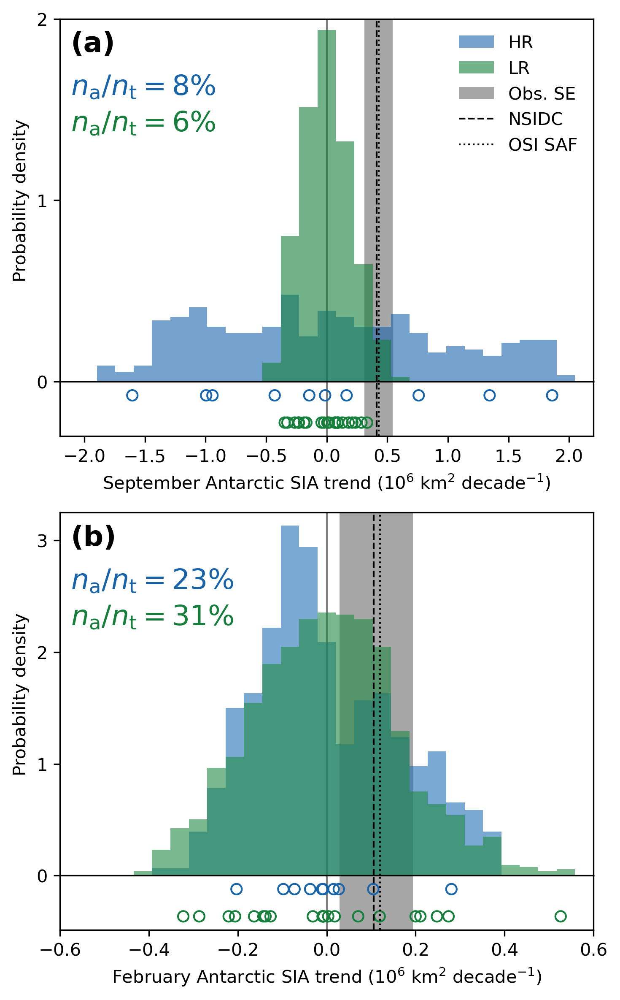

In [331]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 8), dpi=300, layout='tight')
bins_sep = np.linspace(-2.2, 2.2, 30)

hr_vals_sep = 10*hr_all_trends_sep_fc.values.flatten()
lr_vals_sep = 10*lr_all_trends_sep_fc.values.flatten()

ax1.hist(hr_vals_sep, bins=bins_sep, color=blues(0.8),
        density=True, alpha=0.6, linewidth=1.25, label='HR', histtype='stepfilled', edgecolor='none')
ax1.hist(lr_vals_sep, bins=bins_sep, color=greens(0.8),
        density=True, alpha=0.6, linewidth=1.25, label='LR', histtype='stepfilled', edgecolor='none')

ax1.fill_betweenx([0, 2.25], obs_slope_se_min_sep, obs_slope_se_max_sep, color='k', alpha=0.35,
                  label='Obs. SE', zorder=-1, linewidth=1.25, edgecolor='none')

ax1.axvline(ns_per_dec*nsidc_incr_trend_sep.values, color='k', linestyle='--', linewidth=1, label='NSIDC')
ax1.axvline(ns_per_dec*osi_saf_incr_trend_sep.values, color='k', linestyle=':', linewidth=1, label='OSI SAF')

ax1.axvline(0, color='0.5', linewidth=1, linestyle='-', zorder=-1)

ax1.set_ylim(0, 2.0)
ax1.set_xlim(-2.2, 2.2)
ax1.set_ylabel('Probability density')

ax1.legend(loc='upper right', frameon=True, fontsize=10, framealpha=0, fancybox=False)

divider1 = make_axes_locatable(ax1)
ax1s = divider1.new_vertical(size='15%', pad=0, pack_start=True, axes_class=plt.Axes)
fig.add_axes(ax1s)
ax1s.scatter(hr_1986_2014_sep_trends_fc, np.ones_like(hr_1986_2014_sep_trends_fc), color=blues(0.8), marker='o', facecolor='none')
ax1s.scatter(lr_1986_2014_sep_trends_fc, np.zeros_like(lr_1986_2014_sep_trends_fc), color=greens(0.8), marker='o', facecolor='none')

ax1s.fill_betweenx([-1, 2], obs_slope_se_min_sep, obs_slope_se_max_sep, color='k', alpha=0.35, zorder=-1, linewidth=1.25, edgecolor='none')
ax1s.axvline(ns_per_dec*nsidc_incr_trend_sep.values, color='k', linestyle='--', linewidth=1)
ax1s.axvline(ns_per_dec*osi_saf_incr_trend_sep.values, color='k', linestyle=':', linewidth=1)

ax1s.axvline(0, color='0.5', linewidth=1, linestyle='-', zorder=-1)
ax1s.set_yticks([])
ax1.set_xticks([])
ax1.set_yticks([0, 1, 2])
ax1s.set_xlim(ax1.get_xlim())
ax1s.set_ylim(-0.5, 1.5)
ax1s.set_xlabel('September Antarctic SIA trend (10$^6$ km$^2$ decade$^{-1}$)')

############################################

bins_feb = np.linspace(-0.6, 0.6, 30)

hr_vals_feb = 10*hr_all_trends_feb_fc.values.flatten()
lr_vals_feb = 10*lr_all_trends_feb_fc.values.flatten()

ax2.hist(hr_vals_feb, bins=bins_feb, color=blues(0.75),
        density=True, alpha=0.6, linewidth=1.25, label='HR', histtype='stepfilled', edgecolor='none')
ax2.hist(lr_vals_feb, bins=bins_feb, color=greens(0.75),
        density=True, alpha=0.6, linewidth=1.25, label='LR', histtype='stepfilled', edgecolor='none')

ax2.fill_betweenx([0, 4], obs_slope_se_min_feb, obs_slope_se_max_feb, color='k', alpha=0.35,
                  label='Obs. SE', zorder=-1, linewidth=1.25, edgecolor='none')

ax2.axvline(ns_per_dec*nsidc_incr_trend_feb.values, color='k', linestyle='--', linewidth=1, label='NSIDC')
ax2.axvline(ns_per_dec*osi_saf_incr_trend_feb.values, color='k', linestyle=':', linewidth=1, label='OSI SAF')

ax2.axvline(0, color='0.5', linewidth=1, linestyle='-', zorder=-1)

ax2.set_ylim(0, 3.25)
ax2.set_xlim(-0.6, 0.6)

ax2.set_ylabel('Probability density')

divider2 = make_axes_locatable(ax2)
ax2s = divider2.new_vertical(size='15%', pad=0, pack_start=True, axes_class=plt.Axes)
fig.add_axes(ax2s)
ax2s.scatter(hr_1986_2014_feb_trends_fc, np.ones_like(hr_1986_2014_feb_trends_fc), color=blues(0.8), marker='o', facecolor='none')
ax2s.scatter(lr_1986_2014_feb_trends_fc, np.zeros_like(lr_1986_2014_feb_trends_fc), color=greens(0.8), marker='o', facecolor='none')

ax2s.fill_betweenx([-1, 2], obs_slope_se_min_feb, obs_slope_se_max_feb, color='k', alpha=0.35, zorder=-1, linewidth=1.25, edgecolor='none')
ax2s.axvline(ns_per_dec*nsidc_incr_trend_feb.values, color='k', linestyle='--', linewidth=1)
ax2s.axvline(ns_per_dec*osi_saf_incr_trend_feb.values, color='k', linestyle=':', linewidth=1)

ax2s.axvline(0, color='0.5', linewidth=1, linestyle='-', zorder=-1)
ax2s.set_yticks([])
ax2.set_xticks([])
ax2.set_yticks([0, 1, 2, 3])
ax2s.set_xlim(ax2.get_xlim())
ax2s.set_ylim(-0.5, 1.5)
ax2s.set_xlabel('February Antarctic SIA trend (10$^6$ km$^2$ decade$^{-1}$)')

###########################################################################

for label, ax in zip(list('ab'), [ax1, ax2]):
    ax.annotate('('+label+')', xy=(0.02, 0.91), xycoords='axes fraction', fontweight='bold', fontsize=16)

ax1.annotate(r'$n_{\mathrm{a}}/n_{\mathrm{t}}=$'+'{:.0%}'.format(hr_sep_n_like_obs/hr_n_total_samples), xy=(0.02, 0.79), xycoords='axes fraction', fontsize=16, color=blues(0.8))
ax1.annotate(r'$n_{\mathrm{a}}/n_{\mathrm{t}}=$'+'{:.0%}'.format(lr_sep_n_like_obs/lr_n_total_samples), xy=(0.02, 0.69), xycoords='axes fraction', fontsize=16, color=greens(0.8))

ax2.annotate(r'$n_{\mathrm{a}}/n_{\mathrm{t}}=$'+'{:.0%}'.format(hr_feb_n_like_obs/hr_n_total_samples), xy=(0.02, 0.79), xycoords='axes fraction', fontsize=16, color=blues(0.8))
ax2.annotate(r'$n_{\mathrm{a}}/n_{\mathrm{t}}=$'+'{:.0%}'.format(lr_feb_n_like_obs/lr_n_total_samples), xy=(0.02, 0.69), xycoords='axes fraction', fontsize=16, color=greens(0.8))

In [186]:
100*hr_sep_n_like_obs/hr_n_total_samples, 100*lr_sep_n_like_obs/lr_n_total_samples

(np.float64(8.378378378378379), np.float64(6.140350877192983))

In [187]:
hr_sep_n_like_obs_atleast = xr.where((10*hr_all_trends_sep_fc >= obs_slope_se_min_sep), hr_all_trends_sep_fc, np.nan).count().values
lr_sep_n_like_obs_atleast = xr.where((10*lr_all_trends_sep_fc >= obs_slope_se_min_sep), lr_all_trends_sep_fc, np.nan).count().values

In [188]:
100*hr_sep_n_like_obs_atleast/hr_n_total_samples, 100*lr_sep_n_like_obs_atleast/lr_n_total_samples

(np.float64(37.83783783783784), np.float64(6.45933014354067))

In [189]:
np.std(10*lr_all_trends_sep_fc.values.flatten(), ddof=1)

np.float64(0.20080528388029142)

In [190]:
ns_per_dec*nsidc_incr_trend_sep.values, ns_per_dec*osi_saf_incr_trend_sep.values

(np.float64(0.4118793548333698), np.float64(0.4309685138844965))

In [191]:
obs_slope_se_min_sep/np.std(10*lr_all_trends_sep_fc.values.flatten(), ddof=1)

np.float64(1.5516464534291714)

In [192]:
obs_slope_se_max_sep/np.std(10*lr_all_trends_sep_fc.values.flatten(), ddof=1)

np.float64(2.7175416020520773)

In [193]:
0.5*(ns_per_dec*nsidc_incr_trend_sep.values/np.std(10*lr_all_trends_sep_fc.values.flatten(), ddof=1) 
     + ns_per_dec*osi_saf_incr_trend_sep.values/np.std(10*lr_all_trends_sep_fc.values.flatten(), ddof=1))

np.float64(2.0986695480093136)

In [194]:
obs_slope_se_max_sep

np.float64(0.5456967128565693)

## Figures 7 and 8: zonal structure of trends

In [195]:
hr_sep_endddate_like_obs = xr.where((10*hr_all_trends_sep_fc >= obs_slope_se_min_sep) & (10*hr_all_trends_sep_fc <= obs_slope_se_max_sep), hr_all_trends_sep_fc.time, np.nan)
lr_sep_endddate_like_obs = xr.where((10*lr_all_trends_sep_fc >= obs_slope_se_min_sep) & (10*lr_all_trends_sep_fc <= obs_slope_se_max_sep), lr_all_trends_sep_fc.time, np.nan)

In [196]:
lr_sep_endddate_like_obs

<xarray.DataArray (ens_member: 22, time: 57)> Size: 10kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [cftime.DatetimeNoLeap(1958, 10, 1, 0, 0, 0, 0, has_year_zero=True),
        cftime.DatetimeNoLeap(1959, 10, 1, 0, 0, 0, 0, has_year_zero=True),
        cftime.DatetimeNoLeap(1960, 10, 1, 0, 0, 0, 0, has_year_zero=True),
        ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(22, 57), dtype=object)
Coordinates:
  * time     (time) object 456B 1958-10-01 00:00:00 ... 2014-10-01 00:00:00
    degree   int64 8B 1
Dimensions without coordinates: ens_member

In [197]:
hr_feb_endddate_like_obs = xr.where((10*hr_all_trends_feb_fc >= obs_slope_se_min_feb) & (10*hr_all_trends_feb_fc <= obs_slope_se_max_feb), hr_all_trends_feb_fc.time, np.nan)
lr_feb_endddate_like_obs = xr.where((10*lr_all_trends_feb_fc >= obs_slope_se_min_feb) & (10*lr_all_trends_feb_fc <= obs_slope_se_max_feb), lr_all_trends_feb_fc.time, np.nan)

In [198]:
hr_sic_sep = hr_sic_ds.siconc.sel(time=hr_sic_ds.time.dt.month.isin(10))

In [199]:
hr_sic_feb = hr_sic_ds.siconc.sel(time=hr_sic_ds.time.dt.month.isin(3))

In [200]:
lr_sic_sep = lr_sic_ds.siconc.sel(time=lr_sic_ds.time.dt.month.isin(10))

In [201]:
lr_sic_feb = lr_sic_ds.siconc.sel(time=lr_sic_ds.time.dt.month.isin(3))

In [202]:
hr_sep_trend_maps = []
hr_sep_trend_maps_ensm_id = []
hr_sep_trend_maps_time_id = []

for em in range(10):
    for date in hr_sep_endddate_like_obs.isel(ens_member=em):
        if ~date.isnull():
            sic_sep_timeslice = hr_sic_sep.isel(ens_member=em).sel(time=slice(date.values-timedelta(days=365*(w_length-1)), date))
            sic_sep_em_timeslice = hr_sic_sep.sel(time=slice(date.values-timedelta(days=365*(w_length-1)), date)).mean(dim='ens_member')

            sic_sep_trend = sic_sep_timeslice.polyfit('time', 1).polyfit_coefficients.sel(degree=1)
            sic_sep_em_trend = sic_sep_em_timeslice.polyfit('time', 1).polyfit_coefficients.sel(degree=1)

            hr_sep_trend_maps.append(sic_sep_trend - sic_sep_em_trend)
            hr_sep_trend_maps_ensm_id.append(em)
            hr_sep_trend_maps_time_id.append(date)

In [203]:
hr_feb_trend_maps = []
hr_feb_trend_maps_ensm_id = []
hr_feb_trend_maps_time_id = []

for em in range(10):
    for date in hr_feb_endddate_like_obs.isel(ens_member=em):
        if ~date.isnull():
            sic_feb_timeslice = hr_sic_feb.isel(ens_member=em).sel(time=slice(date.values-timedelta(days=365*(w_length-1)), date))
            sic_feb_em_timeslice = hr_sic_feb.sel(time=slice(date.values-timedelta(days=365*(w_length-1)), date)).mean(dim='ens_member')

            sic_feb_trend = sic_feb_timeslice.polyfit('time', 1).polyfit_coefficients.sel(degree=1)
            sic_feb_em_trend = sic_feb_em_timeslice.polyfit('time', 1).polyfit_coefficients.sel(degree=1)

            hr_feb_trend_maps.append(sic_feb_trend - sic_feb_em_trend)
            hr_feb_trend_maps_ensm_id.append(em)
            hr_feb_trend_maps_time_id.append(date)

In [204]:
lr_sep_trend_maps = []
lr_sep_trend_maps_ensm_id = []
lr_sep_trend_maps_time_id = []

for em in range(22):
    for date in lr_sep_endddate_like_obs.isel(ens_member=em):
        if ~date.isnull():
            sic_sep_timeslice = lr_sic_sep.isel(ens_member=em).sel(time=slice(date.values-timedelta(days=365*(w_length-1)), date))
            sic_sep_em_timeslice = lr_sic_sep.sel(time=slice(date.values-timedelta(days=365*(w_length-1)), date)).mean(dim='ens_member')

            sic_sep_trend = sic_sep_timeslice.polyfit('time', 1).polyfit_coefficients.sel(degree=1)
            sic_sep_em_trend = sic_sep_em_timeslice.polyfit('time', 1).polyfit_coefficients.sel(degree=1)
            
            lr_sep_trend_maps.append(sic_sep_trend - sic_sep_em_trend)
            lr_sep_trend_maps_ensm_id.append(em)
            lr_sep_trend_maps_time_id.append(date)

In [205]:
lr_feb_trend_maps = []
lr_feb_trend_maps_ensm_id = []
lr_feb_trend_maps_time_id = []

for em in range(22):
    for date in lr_feb_endddate_like_obs.isel(ens_member=em):
        if ~date.isnull():
            sic_feb_timeslice = lr_sic_feb.isel(ens_member=em).sel(time=slice(date.values-timedelta(days=365*(w_length-1)), date))
            sic_feb_em_timeslice = lr_sic_feb.sel(time=slice(date.values-timedelta(days=365*(w_length-1)), date)).mean(dim='ens_member')

            sic_feb_trend = sic_feb_timeslice.polyfit('time', 1).polyfit_coefficients.sel(degree=1)
            sic_feb_em_trend = sic_feb_em_timeslice.polyfit('time', 1).polyfit_coefficients.sel(degree=1)
            
            lr_feb_trend_maps.append(sic_feb_trend - sic_feb_em_trend)
            lr_feb_trend_maps_ensm_id.append(em)
            lr_feb_trend_maps_time_id.append(date)

Concat and assign the corresponding ensemble member and end year to each trend:

In [206]:
hr_sep_trend_maps_da = xr.concat(hr_sep_trend_maps, dim='sample')
hr_sep_trend_maps_da = hr_sep_trend_maps_da.assign_coords(ens_member=('sample', hr_sep_trend_maps_ensm_id), end_year=('sample', xr.concat(hr_sep_trend_maps_time_id, dim='sample').values))

lr_sep_trend_maps_da = xr.concat(lr_sep_trend_maps, dim='sample')
lr_sep_trend_maps_da = lr_sep_trend_maps_da.assign_coords(ens_member=('sample', lr_sep_trend_maps_ensm_id), end_year=('sample', xr.concat(lr_sep_trend_maps_time_id, dim='sample').values))

In [207]:
hr_feb_trend_maps_da = xr.concat(hr_feb_trend_maps, dim='sample')
hr_feb_trend_maps_da = hr_feb_trend_maps_da.assign_coords(ens_member=('sample', hr_feb_trend_maps_ensm_id), end_year=('sample', xr.concat(hr_feb_trend_maps_time_id, dim='sample').values))

lr_feb_trend_maps_da = xr.concat(lr_feb_trend_maps, dim='sample')
lr_feb_trend_maps_da = lr_feb_trend_maps_da.assign_coords(ens_member=('sample', lr_feb_trend_maps_ensm_id), end_year=('sample', xr.concat(lr_feb_trend_maps_time_id, dim='sample').values))

In [208]:
lr_sep_trend_maps_da

<xarray.DataArray 'polyfit_coefficients' (sample: 77, nj: 180, ni: 360)> Size: 40MB
dask.array<concatenate, shape=(77, 180, 360), dtype=float64, chunksize=(1, 180, 360), chunktype=numpy.ndarray>
Coordinates:
    degree      int64 8B 1
    ens_member  (sample) int64 616B 0 0 0 0 0 0 0 0 ... 17 20 20 20 20 20 21 21
    end_year    (sample) object 616B 1980-10-01 00:00:00 ... 2008-10-01 00:00:00
Dimensions without coordinates: sample, nj, ni

In [209]:
hr_feb_trend_maps_da

<xarray.DataArray 'polyfit_coefficients' (sample: 86, nj: 180, ni: 360)> Size: 45MB
dask.array<concatenate, shape=(86, 180, 360), dtype=float64, chunksize=(1, 180, 360), chunktype=numpy.ndarray>
Coordinates:
    degree      int64 8B 1
    ens_member  (sample) int64 688B 0 0 0 0 0 0 0 0 0 0 ... 8 8 8 8 8 9 9 9 9 9
    end_year    (sample) object 688B 1989-03-01 00:00:00 ... 2009-03-01 00:00:00
Dimensions without coordinates: sample, nj, ni

Note number of samples retained compared to the total samples:

In [210]:
hr_sep_trend_maps_da.shape[0], lr_sep_trend_maps_da.shape[0]

(31, 77)

In [211]:
len(hr_all_trends_sep.values.flatten()), len(lr_all_trends_sep.values.flatten())

(370, 1254)

Fraction of samples that agree with observations:

In [212]:
print('HR percent agreement w/ obs: {:.1%}'.format(hr_sep_trend_maps_da.shape[0]/len(hr_all_trends_sep.values.flatten())))

HR percent agreement w/ obs: 8.4%


In [213]:
print('LR percent agreement w/ obs: {:.1%}'.format(lr_sep_trend_maps_da.shape[0]/len(lr_all_trends_sep.values.flatten())))

LR percent agreement w/ obs: 6.1%


### Calculating SIA(lon)

In [214]:
hr_sialon_sep = aa_sea_ice_area_lon(hr_sic_ds.siconc.sel(time=hr_sic_ds.time.dt.month.isin([10])).sel(time=slice('1920', '2024'))).compute()
hr_sialon_sep['ni'] = hr_sialon_sep['ni'] - 180
hr_sialon_sep = hr_sialon_sep.roll(ni=-180)
hr_sialon_sep = hr_sialon_sep.rename({'ni': 'lon'})

In [215]:
hr_sialon_feb = aa_sea_ice_area_lon(hr_sic_ds.siconc.sel(time=hr_sic_ds.time.dt.month.isin([3])).sel(time=slice('1920', '2024'))).compute()
hr_sialon_feb['ni'] = hr_sialon_feb['ni'] - 180
hr_sialon_feb = hr_sialon_feb.roll(ni=-180)
hr_sialon_feb = hr_sialon_feb.rename({'ni': 'lon'})

In [216]:
lr_sialon_sep = aa_sea_ice_area_lon(lr_sic_ds.siconc.sel(time=lr_sic_ds.time.dt.month.isin([10])).sel(time=slice('1920', '2024'))).compute()
lr_sialon_sep['ni'] = lr_sialon_sep['ni'] - 180
lr_sialon_sep = lr_sialon_sep.roll(ni=-180)
lr_sialon_sep = lr_sialon_sep.rename({'ni': 'lon'})

In [217]:
lr_sialon_feb = aa_sea_ice_area_lon(lr_sic_ds.siconc.sel(time=lr_sic_ds.time.dt.month.isin([3])).sel(time=slice('1920', '2024'))).compute()
lr_sialon_feb['ni'] = lr_sialon_feb['ni'] - 180
lr_sialon_feb = lr_sialon_feb.roll(ni=-180)
lr_sialon_feb = lr_sialon_feb.rename({'ni': 'lon'})

In [218]:
hr_sep_sialon_trends = []
hr_sep_sialon_trends_ensm_id = []
hr_sep_sialon_trends_time_id = []

for em in range(10):
    for date in hr_sep_endddate_like_obs.isel(ens_member=em):
        if ~date.isnull():
            hr_sialon_sep_timeslice = hr_sialon_sep.isel(ens_member=em).sel(time=slice(date.values-timedelta(days=365*(w_length-1)), date))
            hr_sialon_sep_em_timeslice = hr_sialon_sep.sel(time=slice(date.values-timedelta(days=365*(w_length-1)), date)).mean(dim='ens_member')
            
            hr_sialon_sep_trend = hr_sialon_sep_timeslice.polyfit('time', 1).polyfit_coefficients.sel(degree=1)
            hr_sialon_sep_em_trend = hr_sialon_sep_em_timeslice.polyfit('time', 1).polyfit_coefficients.sel(degree=1)

            hr_sep_sialon_trends.append(ns_per_dec*(hr_sialon_sep_trend - hr_sialon_sep_em_trend))
            hr_sep_sialon_trends_ensm_id.append(em)
            hr_sep_sialon_trends_time_id.append(date)

In [219]:
hr_feb_sialon_trends = []
hr_feb_sialon_trends_ensm_id = []
hr_feb_sialon_trends_time_id = []

for em in range(10):
    for date in hr_feb_endddate_like_obs.isel(ens_member=em):
        if ~date.isnull():
            hr_sialon_feb_timeslice = hr_sialon_feb.isel(ens_member=em).sel(time=slice(date.values-timedelta(days=365*(w_length-1)), date))
            hr_sialon_feb_em_timeslice = hr_sialon_feb.sel(time=slice(date.values-timedelta(days=365*(w_length-1)), date)).mean(dim='ens_member')
            
            hr_sialon_feb_trend = hr_sialon_feb_timeslice.polyfit('time', 1).polyfit_coefficients.sel(degree=1)
            hr_sialon_feb_em_trend = hr_sialon_feb_em_timeslice.polyfit('time', 1).polyfit_coefficients.sel(degree=1)

            hr_feb_sialon_trends.append(ns_per_dec*(hr_sialon_feb_trend - hr_sialon_feb_em_trend))
            hr_feb_sialon_trends_ensm_id.append(em)
            hr_feb_sialon_trends_time_id.append(date)

In [220]:
lr_sep_sialon_trends = []
lr_sep_sialon_trends_ensm_id = []
lr_sep_sialon_trends_time_id = []

for em in range(22):
    for date in lr_sep_endddate_like_obs.isel(ens_member=em):
        if ~date.isnull():
            lr_sialon_sep_timeslice = lr_sialon_sep.isel(ens_member=em).sel(time=slice(date.values-timedelta(days=365*(w_length-1)), date))
            lr_sialon_sep_em_timeslice = lr_sialon_sep.sel(time=slice(date.values-timedelta(days=365*(w_length-1)), date)).mean(dim='ens_member')
            
            lr_sialon_sep_trend = lr_sialon_sep_timeslice.polyfit('time', 1).polyfit_coefficients.sel(degree=1)
            lr_sialon_sep_em_trend = lr_sialon_sep_em_timeslice.polyfit('time', 1).polyfit_coefficients.sel(degree=1)

            lr_sep_sialon_trends.append(ns_per_dec*(lr_sialon_sep_trend - lr_sialon_sep_em_trend))
            lr_sep_sialon_trends_ensm_id.append(em)
            lr_sep_sialon_trends_time_id.append(date)

In [221]:
lr_feb_sialon_trends = []
lr_feb_sialon_trends_ensm_id = []
lr_feb_sialon_trends_time_id = []

for em in range(22):
    for date in lr_feb_endddate_like_obs.isel(ens_member=em):
        if ~date.isnull():
            lr_sialon_feb_timeslice = lr_sialon_feb.isel(ens_member=em).sel(time=slice(date.values-timedelta(days=365*(w_length-1)), date))
            lr_sialon_feb_em_timeslice = lr_sialon_feb.sel(time=slice(date.values-timedelta(days=365*(w_length-1)), date)).mean(dim='ens_member')
            
            lr_sialon_feb_trend = lr_sialon_feb_timeslice.polyfit('time', 1).polyfit_coefficients.sel(degree=1)
            lr_sialon_feb_em_trend = lr_sialon_feb_em_timeslice.polyfit('time', 1).polyfit_coefficients.sel(degree=1)

            lr_feb_sialon_trends.append(ns_per_dec*(lr_sialon_feb_trend - lr_sialon_feb_em_trend))
            lr_feb_sialon_trends_ensm_id.append(em)
            lr_feb_sialon_trends_time_id.append(date)

In [222]:
hr_sep_sialon_trends_da = xr.concat(hr_sep_sialon_trends, dim='sample')
hr_sep_sialon_trends_da = hr_sep_sialon_trends_da.assign_coords(ens_member=('sample', hr_sep_sialon_trends_ensm_id), 
                                                                    end_year=('sample', xr.concat(hr_sep_sialon_trends_time_id, dim='sample').values))

In [223]:
hr_feb_sialon_trends_da = xr.concat(hr_feb_sialon_trends, dim='sample')
hr_feb_sialon_trends_da = hr_feb_sialon_trends_da.assign_coords(ens_member=('sample', hr_feb_sialon_trends_ensm_id), 
                                                                    end_year=('sample', xr.concat(hr_feb_sialon_trends_time_id, dim='sample').values))

In [224]:
lr_sep_sialon_trends_da = xr.concat(lr_sep_sialon_trends, dim='sample')
lr_sep_sialon_trends_da = lr_sep_sialon_trends_da.assign_coords(ens_member=('sample', lr_sep_sialon_trends_ensm_id), 
                                                                    end_year=('sample', xr.concat(lr_sep_sialon_trends_time_id, dim='sample').values))

In [225]:
lr_feb_sialon_trends_da = xr.concat(lr_feb_sialon_trends, dim='sample')
lr_feb_sialon_trends_da = lr_feb_sialon_trends_da.assign_coords(ens_member=('sample', lr_feb_sialon_trends_ensm_id), 
                                                                    end_year=('sample', xr.concat(lr_feb_sialon_trends_time_id, dim='sample').values))

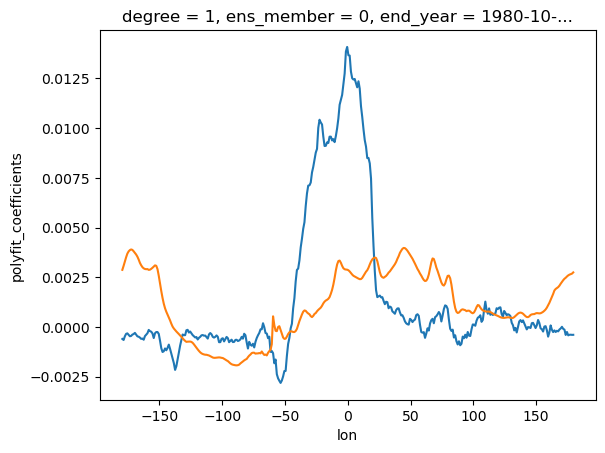

In [226]:
hr_sep_sialon_trends_da.isel(sample=0).plot()
lr_sep_sialon_trends_da.isel(sample=0).plot()

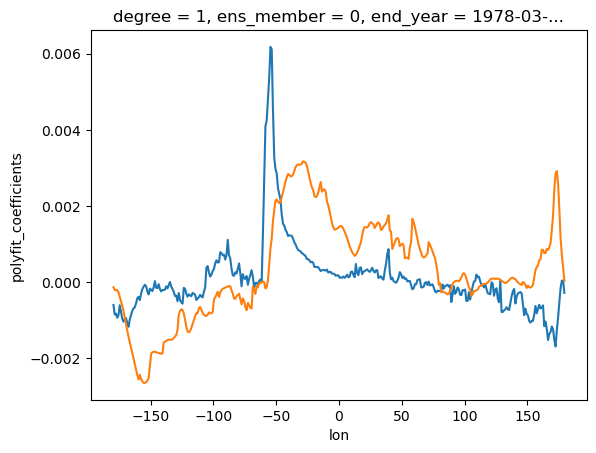

In [227]:
hr_feb_sialon_trends_da.isel(sample=0).plot()
lr_feb_sialon_trends_da.isel(sample=0).plot()

### Compositing

In [228]:
%%time
hr_sep_trend_maps_avg = hr_sep_trend_maps_da.mean(dim='sample').compute()

CPU times: user 11.7 s, sys: 809 ms, total: 12.5 s
Wall time: 43.7 s


In [229]:
%%time
hr_feb_trend_maps_avg = hr_feb_trend_maps_da.mean(dim='sample').compute()

CPU times: user 25.3 s, sys: 1.38 s, total: 26.7 s
Wall time: 1min 30s


In [230]:
%%time
lr_sep_trend_maps_avg = lr_sep_trend_maps_da.mean(dim='sample').compute()

CPU times: user 52.5 s, sys: 2.43 s, total: 55 s
Wall time: 1min 59s


In [231]:
%%time
lr_feb_trend_maps_avg = lr_feb_trend_maps_da.mean(dim='sample').compute()

CPU times: user 1min 32s, sys: 4.84 s, total: 1min 37s
Wall time: 5min 19s


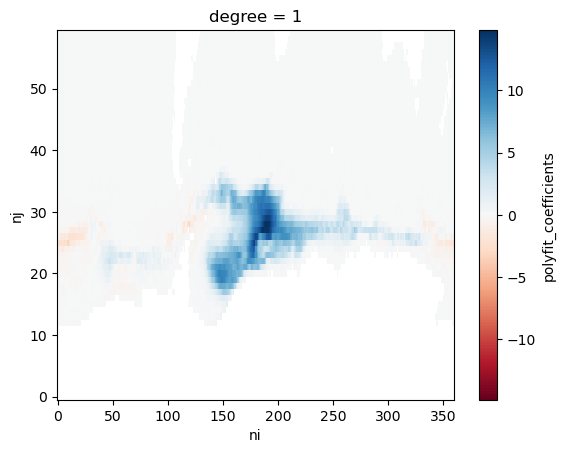

In [232]:
(ns_per_dec*hr_sep_trend_maps_avg.isel(nj=slice(0, 60)).roll(ni=180)).plot(cmap='RdBu')

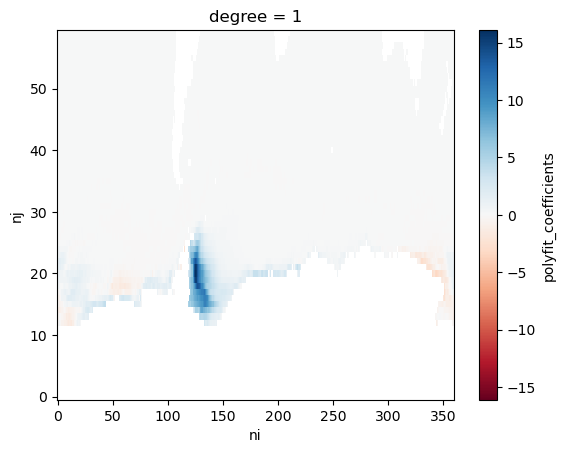

In [233]:
(ns_per_dec*hr_feb_trend_maps_avg.isel(nj=slice(0, 60)).roll(ni=180)).plot(cmap='RdBu')

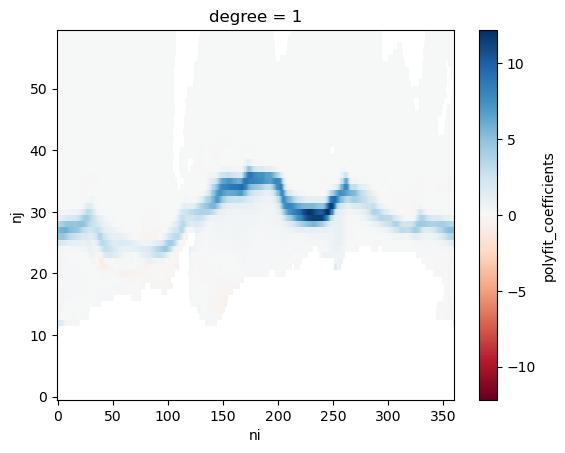

In [234]:
(ns_per_dec*lr_sep_trend_maps_avg.isel(nj=slice(0, 60)).roll(ni=180)).plot(cmap='RdBu')

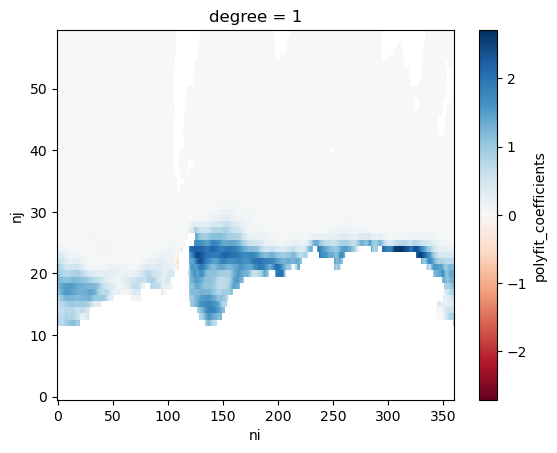

In [235]:
(ns_per_dec*lr_feb_trend_maps_avg.isel(nj=slice(0, 60)).roll(ni=180)).plot(cmap='RdBu')

In [236]:
hr_sep_trend_maps_avg_50s = ns_per_dec*hr_sep_trend_maps_avg.where(hr_sic_ds.lat.isel(time=0, ens_member=0).compute() <= -50, drop=True)

In [237]:
hr_feb_trend_maps_avg_50s = ns_per_dec*hr_feb_trend_maps_avg.where(hr_sic_ds.lat.isel(time=0, ens_member=0).compute() <= -50, drop=True)

In [238]:
lr_sep_trend_maps_avg_50s = ns_per_dec*lr_sep_trend_maps_avg.where(lr_sic_ds.lat.isel(time=0, ens_member=0).compute() <= -50, drop=True)

In [239]:
lr_feb_trend_maps_avg_50s = ns_per_dec*lr_feb_trend_maps_avg.where(lr_sic_ds.lat.isel(time=0, ens_member=0).compute() <= -50, drop=True)

### Obs

In [240]:
hadisst1_sep_incr_da = hadisst1.sic.where(hadisst1.latitude <= -30, drop=True).sel(time=hadisst1.time.dt.month.isin(9)).sel(time=slice('1986', '2014'))

In [241]:
hadisst1_feb_incr_da = hadisst1.sic.where(hadisst1.latitude <= -30, drop=True).sel(time=hadisst1.time.dt.month.isin(2)).sel(time=slice('1986', '2014'))

In [242]:
hadisst1_sep_incr_trend_map = ns_per_dec*100*hadisst1_sep_incr_da.polyfit('time', 1).polyfit_coefficients.isel(degree=0)

In [243]:
hadisst1_feb_incr_trend_map = ns_per_dec*100*hadisst1_feb_incr_da.polyfit('time', 1).polyfit_coefficients.isel(degree=0)

In [244]:
nsidc_sep_incr_da = nsidc.cdr_seaice_conc_monthly.sel(time=nsidc.time.dt.month.isin(9)).sel(time=slice('1986', '2014'))

In [245]:
nsidc_feb_incr_da = nsidc.cdr_seaice_conc_monthly.sel(time=nsidc.time.dt.month.isin(2)).sel(time=slice('1986', '2014'))

In [246]:
nsidc_sep_incr_trend_map = ns_per_dec*100*nsidc_sep_incr_da.polyfit('time', 1).polyfit_coefficients.isel(degree=0)

In [247]:
nsidc_feb_incr_trend_map = ns_per_dec*100*nsidc_feb_incr_da.polyfit('time', 1).polyfit_coefficients.isel(degree=0)

In [248]:
osi_saf_sep_incr_da = osi_saf_ds.ice_conc.sel(time=osi_saf_ds.time.dt.month.isin(9)).sel(time=slice('1986', '2014'))

In [249]:
osi_saf_feb_incr_da = osi_saf_ds.ice_conc.sel(time=osi_saf_ds.time.dt.month.isin(2)).sel(time=slice('1986', '2014'))

In [250]:
osi_saf_sep_incr_trend_map = ns_per_dec*osi_saf_sep_incr_da.polyfit('time', 1).polyfit_coefficients.isel(degree=0)

In [251]:
osi_saf_feb_incr_trend_map = ns_per_dec*osi_saf_feb_incr_da.polyfit('time', 1).polyfit_coefficients.isel(degree=0)

Text(0.5, 1.0, 'HadISST1 trend (Sep; 1986–2014)')

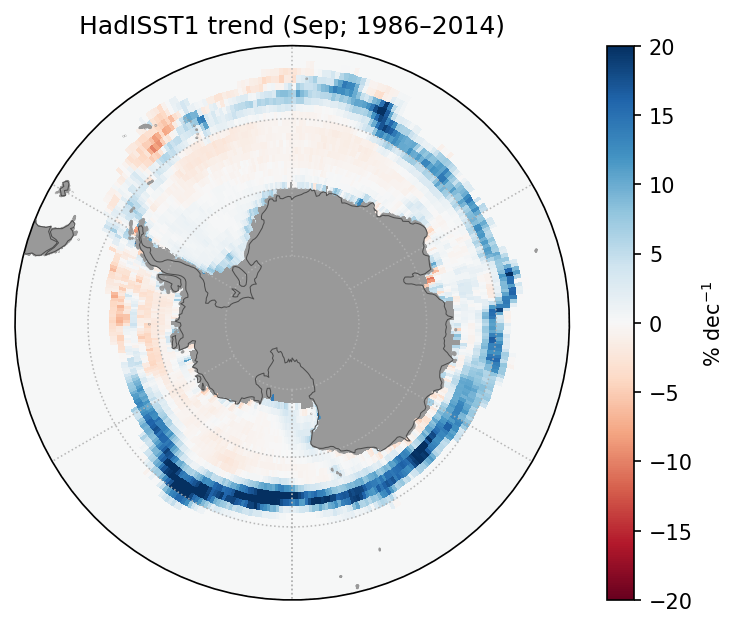

In [252]:
had_lats = hadisst1_sep_incr_trend_map.latitude.where(hadisst1_sep_incr_trend_map.latitude <= -50, drop=True)
had_lons = hadisst1_sep_incr_trend_map.longitude
data_hadisst1 = hadisst1_sep_incr_trend_map.where(hadisst1_sep_incr_trend_map.latitude <= -50, drop=True)

fig = plt.figure(dpi=150)
ax = fig.add_subplot(projection=ccrs.SouthPolarStereo())
trend_plot = ax.pcolormesh(had_lons, had_lats, data_hadisst1, transform=ccrs.PlateCarree(), cmap='RdBu', vmax=20, vmin=-20)

aa_plot_details(ax)

plt.colorbar(trend_plot, label='% dec$^{-1}$')
plt.title('HadISST1 trend (Sep; 1986–2014)')

Text(0.5, 1.0, 'HadISST1 trend (Feb; 1986–2014)')

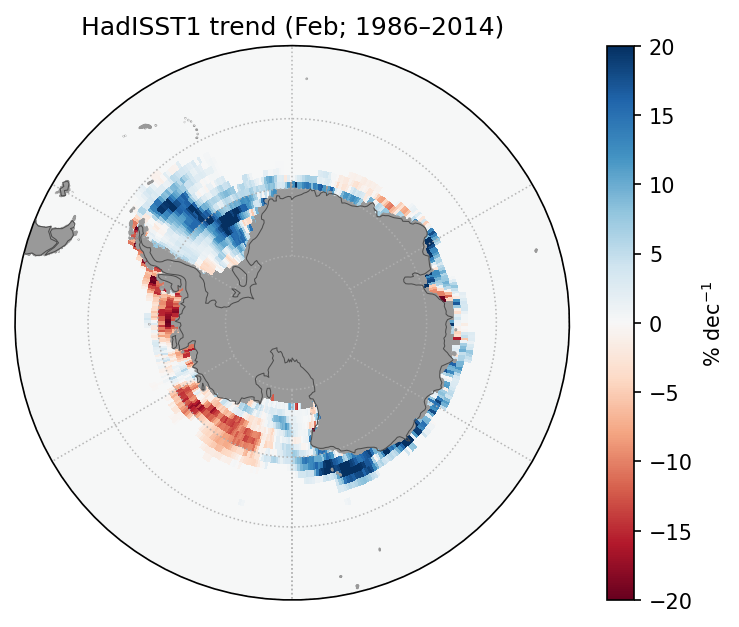

In [253]:
had_lats = hadisst1_feb_incr_trend_map.latitude.where(hadisst1_feb_incr_trend_map.latitude <= -50, drop=True)
had_lons = hadisst1_feb_incr_trend_map.longitude
data_hadisst1 = hadisst1_feb_incr_trend_map.where(hadisst1_feb_incr_trend_map.latitude <= -50, drop=True)

fig = plt.figure(dpi=150)
ax = fig.add_subplot(projection=ccrs.SouthPolarStereo())
trend_plot = ax.pcolormesh(had_lons, had_lats, data_hadisst1, transform=ccrs.PlateCarree(), cmap='RdBu', vmax=20, vmin=-20)

aa_plot_details(ax)

plt.colorbar(trend_plot, label='% dec$^{-1}$')
plt.title('HadISST1 trend (Feb; 1986–2014)')

For comparison with Meehl et al. (2016) Fig. 2:

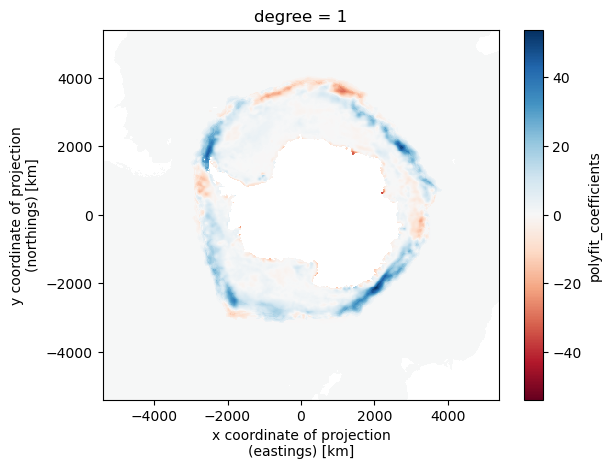

In [254]:
(ns_per_dec*osi_saf_ds.ice_conc.sel(time=osi_saf_ds.time.dt.month.isin(9)).sel(time=slice('2000', '2014'))).polyfit('time', 1).polyfit_coefficients.isel(degree=0).plot(cmap='RdBu')

In [255]:
osi_saf_sialon_sep = (1e-2*1e-6*625*(osi_saf_combined_ds.ice_conc.sel(time=osi_saf_combined_ds.time.dt.month.isin([9])).groupby_bins('lon', 
                                                                                                                                   bins=np.arange(-180, 181, 1),
                                                                                                                                   labels=hadisst1.longitude.values).sum()))
osi_saf_sialon_sep = osi_saf_sialon_sep.rename({'lon_bins': 'lon'})

In [256]:
osi_saf_sialon_feb = (1e-2*1e-6*625*(osi_saf_combined_ds.ice_conc.sel(time=osi_saf_combined_ds.time.dt.month.isin([2])).groupby_bins('lon', 
                                                                                                                                   bins=np.arange(-180, 181, 1),
                                                                                                                                   labels=hadisst1.longitude.values).sum()))
osi_saf_sialon_feb = osi_saf_sialon_feb.rename({'lon_bins': 'lon'})

In [257]:
nsidc_sialon_sep = (1e-6*625*(nsidc_latlon.cdr_seaice_conc_monthly.sel(time=nsidc_latlon.time.dt.month.isin([9])).groupby_bins('lon', 
                                                                                                                             bins=np.arange(-180, 181, 1),
                                                                                                                             labels=hadisst1.longitude.values).sum()))
nsidc_sialon_sep = nsidc_sialon_sep.rename({'lon_bins': 'lon'})

In [258]:
nsidc_sialon_feb = (1e-6*625*(nsidc_latlon.cdr_seaice_conc_monthly.sel(time=nsidc_latlon.time.dt.month.isin([2])).groupby_bins('lon', 
                                                                                                                             bins=np.arange(-180, 181, 1),
                                                                                                                             labels=hadisst1.longitude.values).sum()))
nsidc_sialon_feb = nsidc_sialon_feb.rename({'lon_bins': 'lon'})

In [259]:
hadisst1_sialon_sep = (1e-6*(hadisst1.sic*hadisst1.xe_area).where(hadisst1.latitude < 0).sel(time=hadisst1.time.dt.month.isin([9])).sum(dim='latitude').sel(time=slice('1979', None)))
hadisst1_sialon_sep = hadisst1_sialon_sep.rename({'longitude': 'lon'})

In [260]:
hadisst1_sialon_feb = (1e-6*(hadisst1.sic*hadisst1.xe_area).where(hadisst1.latitude < 0).sel(time=hadisst1.time.dt.month.isin([2])).sum(dim='latitude').sel(time=slice('1979', None)))
hadisst1_sialon_feb = hadisst1_sialon_feb.rename({'longitude': 'lon'})

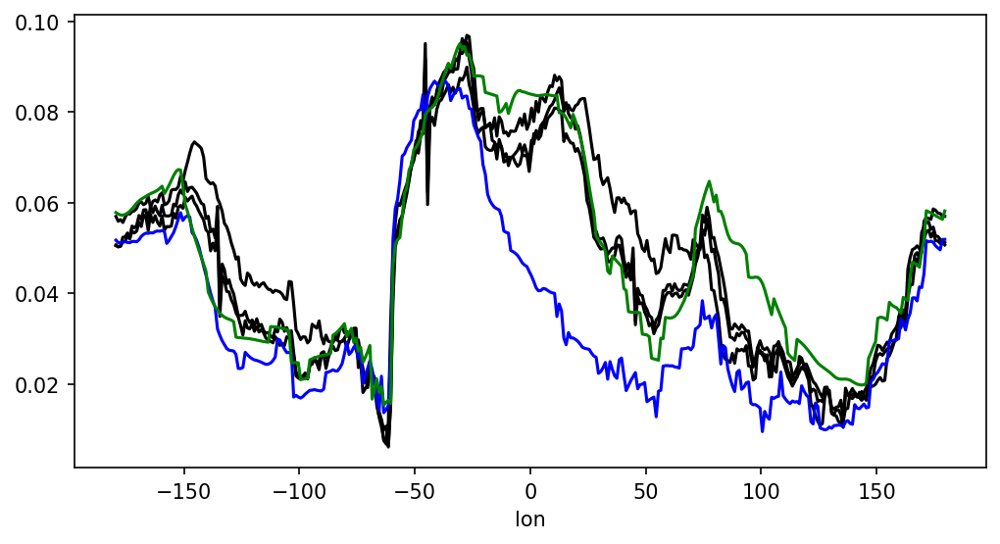

In [261]:
plt.figure(figsize=(8, 4), dpi=150)

osi_saf_sialon_sep.mean(dim='time').plot(color='k')
nsidc_sialon_sep.mean(dim='time').plot(color='k')
hadisst1_sialon_sep.sel(time='2010').plot(color='k')
hr_sialon_sep.isel(ens_member=0).mean(dim='time').plot(color='b')
lr_sialon_sep.isel(ens_member=0).mean(dim='time').plot(color='g')

# plt.xlim(-140, -130)
# plt.axvline(-46)

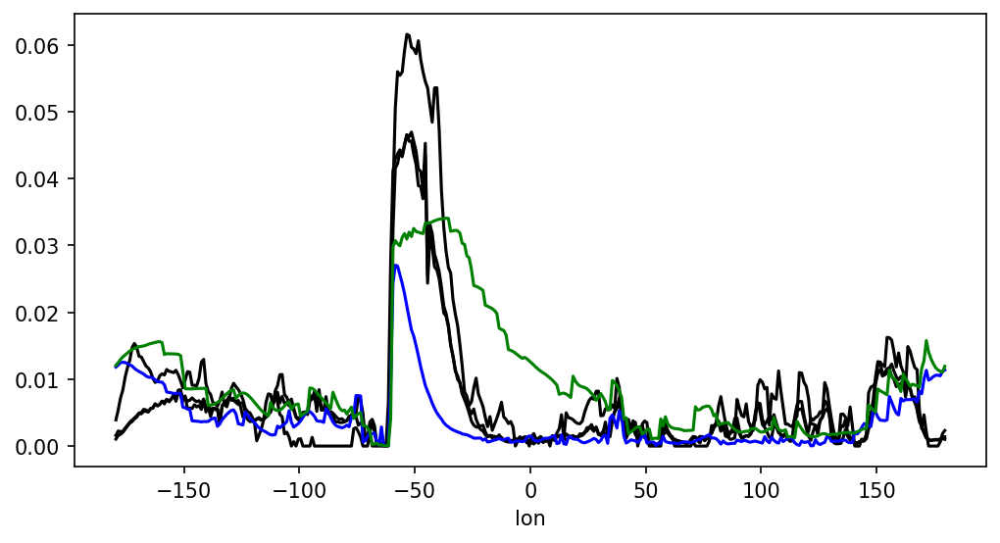

In [262]:
plt.figure(figsize=(8, 4), dpi=150)

osi_saf_sialon_feb.mean(dim='time').plot(color='k')
nsidc_sialon_feb.mean(dim='time').plot(color='k')
hadisst1_sialon_feb.sel(time='2010').plot(color='k')
hr_sialon_feb.isel(ens_member=0).mean(dim='time').plot(color='b')
lr_sialon_feb.isel(ens_member=0).mean(dim='time').plot(color='g')

# plt.xlim(-140, -130)
# plt.axvline(-46)

Those spikes are near the corners:

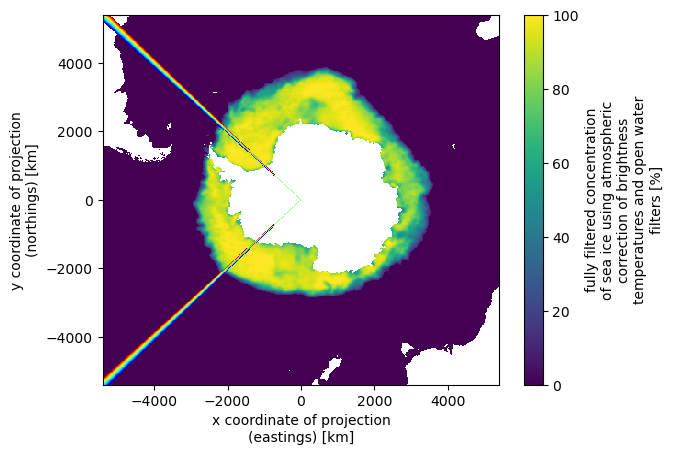

In [263]:
osi_saf_combined_ds.ice_conc.isel(time=0).plot()
osi_saf_combined_ds.lon.where((osi_saf_combined_ds.lon > -46) & (osi_saf_combined_ds.lon <= -44)).plot(cmap='jet', add_colorbar=False)
osi_saf_combined_ds.lon.where((osi_saf_combined_ds.lon > -136) & (osi_saf_combined_ds.lon <= -134)).plot(cmap='jet', add_colorbar=False)

In [264]:
# nsidc_sialon_trend_sep = ns_per_dec*nsidc_sialon_sep.sel(time=slice('1986', '2014')).polyfit('time', deg=1).sel(degree=1).polyfit_coefficients

In [265]:
# nsidc_sialon_trend_feb = ns_per_dec*nsidc_sialon_feb.sel(time=slice('1986', '2014')).polyfit('time', deg=1).sel(degree=1).polyfit_coefficients

In [266]:
# osi_saf_sialon_trend_sep = ns_per_dec*osi_saf_sialon_sep.sel(time=slice('1986', '2014')).polyfit('time', deg=1).sel(degree=1).polyfit_coefficients

In [267]:
# osi_saf_sialon_trend_feb = ns_per_dec*osi_saf_sialon_feb.sel(time=slice('1986', '2014')).polyfit('time', deg=1).sel(degree=1).polyfit_coefficients

In [268]:
# hadisst1_sialon_trend_sep = ns_per_dec*hadisst1_sialon_sep.sel(time=slice('1986', '2014')).polyfit('time', deg=1).sel(degree=1).polyfit_coefficients

In [269]:
# hadisst1_sialon_trend_feb = ns_per_dec*hadisst1_sialon_feb.sel(time=slice('1986', '2014')).polyfit('time', deg=1).sel(degree=1).polyfit_coefficients

In [270]:
nsidc_sialon_trend_sep, nsidc_sialon_trend_sep_se = compute_trend_with_se(nsidc_sialon_sep.sel(time=slice('1986', '2014')), adj=True, lon=True)

In [271]:
nsidc_sialon_trend_feb, nsidc_sialon_trend_feb_se = compute_trend_with_se(nsidc_sialon_feb.sel(time=slice('1986', '2014')), adj=True, lon=True)

In [272]:
osi_saf_sialon_trend_sep, osi_saf_sialon_trend_sep_se = compute_trend_with_se(osi_saf_sialon_sep.sel(time=slice('1986', '2014')), adj=True, lon=True)

In [273]:
osi_saf_sialon_trend_feb, osi_saf_sialon_trend_feb_se = compute_trend_with_se(osi_saf_sialon_feb.sel(time=slice('1986', '2014')), adj=True, lon=True)

In [274]:
obs_sialon_slope_se_min_sep = np.min([nsidc_sialon_trend_sep - nsidc_sialon_trend_sep_se, osi_saf_sialon_trend_sep - osi_saf_sialon_trend_sep_se], axis=0)

In [275]:
obs_sialon_slope_se_max_sep = np.max([nsidc_sialon_trend_sep + nsidc_sialon_trend_sep_se, osi_saf_sialon_trend_sep + osi_saf_sialon_trend_sep_se], axis=0)

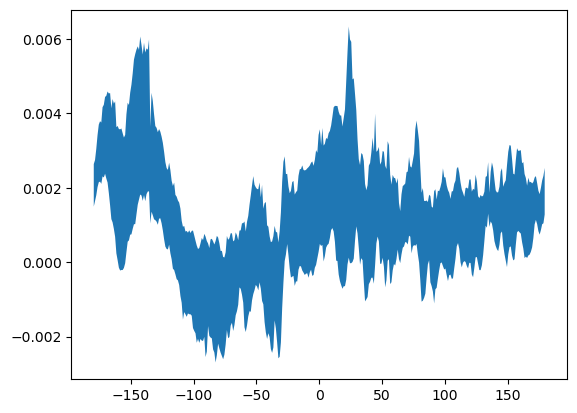

In [276]:
plt.fill_between(nsidc_sialon_trend_sep.lon, obs_sialon_slope_se_min_sep, obs_sialon_slope_se_max_sep)

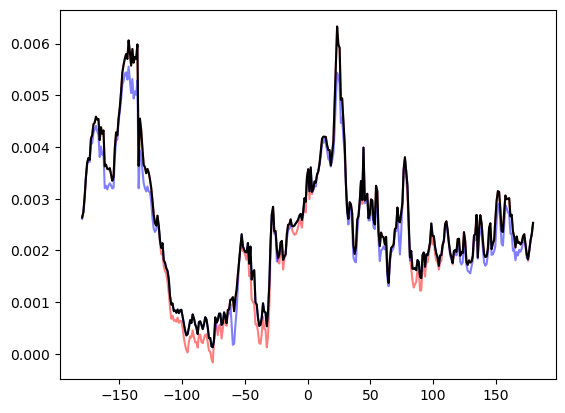

In [277]:
plt.plot(nsidc_sialon_trend_sep.lon, nsidc_sialon_trend_sep + nsidc_sialon_trend_sep_se, alpha=0.5, color='r')
plt.plot(osi_saf_sialon_trend_sep.lon, osi_saf_sialon_trend_sep + osi_saf_sialon_trend_sep_se, alpha=0.5, color='b')
plt.plot(osi_saf_sialon_trend_sep.lon, obs_sialon_slope_se_max_sep, alpha=1, color='k')

# test_nsidc_sialon_trend_sep.plot(color='k')

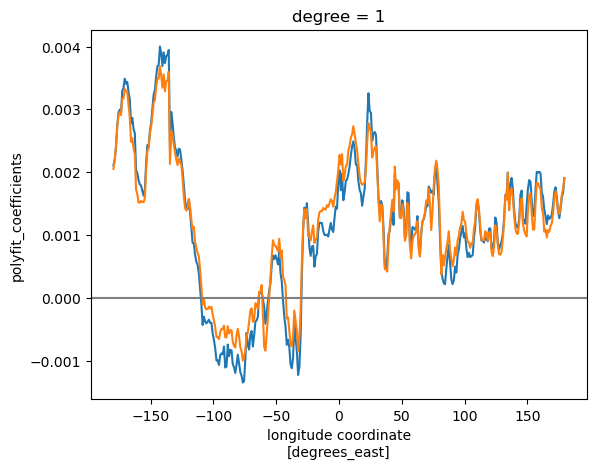

In [278]:
nsidc_sialon_trend_sep.plot()
osi_saf_sialon_trend_sep.plot()
plt.axhline(0, color='gray')

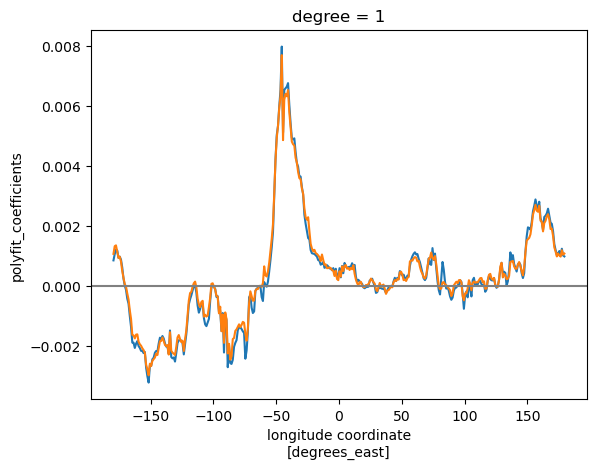

In [279]:
nsidc_sialon_trend_feb.plot()
osi_saf_sialon_trend_feb.plot()
# hadisst1_sialon_trend.plot(color='k')
plt.axhline(0, color='gray')

### Zonal pattern matching

Using correlation:

In [280]:
hr_nsidc_sialon_corr_sep = xr.corr(hr_sep_sialon_trends_da, nsidc_sialon_trend_sep, dim='lon')

In [281]:
hr_nsidc_sialon_corr_feb = xr.corr(hr_feb_sialon_trends_da, nsidc_sialon_trend_feb, dim='lon')

In [282]:
hr_osi_saf_sialon_corr_sep = xr.corr(hr_sep_sialon_trends_da, osi_saf_sialon_trend_sep, dim='lon')

In [283]:
hr_osi_saf_sialon_corr_feb = xr.corr(hr_feb_sialon_trends_da, osi_saf_sialon_trend_feb, dim='lon')

In [284]:
lr_nsidc_sialon_corr_sep = xr.corr(lr_sep_sialon_trends_da, nsidc_sialon_trend_sep, dim='lon')

In [285]:
lr_nsidc_sialon_corr_feb = xr.corr(lr_feb_sialon_trends_da, nsidc_sialon_trend_feb, dim='lon')

In [286]:
lr_osi_saf_sialon_corr_sep = xr.corr(lr_sep_sialon_trends_da, osi_saf_sialon_trend_sep, dim='lon')

In [287]:
lr_osi_saf_sialon_corr_feb = xr.corr(lr_feb_sialon_trends_da, osi_saf_sialon_trend_feb, dim='lon')

Using RMSE:

In [288]:
def rmse_lon(model, obs):
    return np.sqrt(((model - obs)**2).sum(dim='lon')/len(model.lon))

In [289]:
rmse_lon(lr_sep_sialon_trends_da, nsidc_sialon_trend_sep).argmin()

<xarray.DataArray 'polyfit_coefficients' ()> Size: 8B
array(39)
Coordinates:
    degree   int64 8B 1

Text(0.5, 0, 'Zonal correlation with observations')

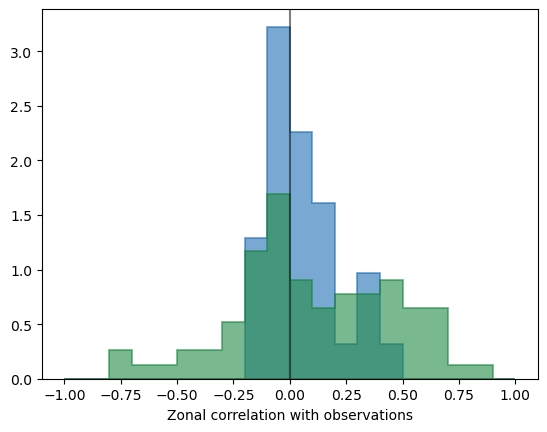

In [290]:
plt.hist(hr_nsidc_sialon_corr_sep, bins=np.arange(-1, 1.1, 0.1), density=True, color=blues(0.75), alpha=0.6, linewidth=1.25, label='HR', histtype='stepfilled', edgecolor=blues(0.8))
plt.hist(lr_nsidc_sialon_corr_sep, bins=np.arange(-1, 1.1, 0.1), density=True, color=greens(0.75), alpha=0.6, linewidth=1.25, label='LR', histtype='stepfilled', edgecolor=greens(0.8))
plt.axvline(0, color='k', alpha=0.5, linestyle='-')
# plt.axvline(1, color='k')
# plt.xlim(-0.7, 0.9)
plt.xlabel('Zonal correlation with observations')

The samples with the greatest correlation are the same between the two observational products:

In [291]:
hr_nsidc_sialon_corr_sep.isel(sample=hr_nsidc_sialon_corr_sep.argmax()).values, hr_nsidc_sialon_corr_sep.isel(sample=rmse_lon(hr_sep_sialon_trends_da, nsidc_sialon_trend_sep).argmin()).values

(array(0.41485804), array(0.04854825))

In [292]:
hr_osi_saf_sialon_corr_sep.isel(sample=hr_osi_saf_sialon_corr_sep.argmax())

<xarray.DataArray 'polyfit_coefficients' ()> Size: 8B
array(0.42722326)
Coordinates:
    degree      int64 8B 1
    ens_member  int64 8B 0
    end_year    object 8B 2006-10-01 00:00:00

In [293]:
hr_nsidc_sialon_corr_feb.isel(sample=hr_nsidc_sialon_corr_feb.argmax())

<xarray.DataArray 'polyfit_coefficients' ()> Size: 8B
array(0.69304887)
Coordinates:
    degree      int64 8B 1
    ens_member  int64 8B 2
    end_year    object 8B 1978-03-01 00:00:00

In [294]:
hr_osi_saf_sialon_corr_feb.isel(sample=hr_osi_saf_sialon_corr_feb.argmax())

<xarray.DataArray 'polyfit_coefficients' ()> Size: 8B
array(0.71306653)
Coordinates:
    degree      int64 8B 1
    ens_member  int64 8B 2
    end_year    object 8B 1978-03-01 00:00:00

In [295]:
lr_nsidc_sialon_corr_sep.isel(sample=lr_nsidc_sialon_corr_sep.argmax())

<xarray.DataArray 'polyfit_coefficients' ()> Size: 8B
array(0.81119624)
Coordinates:
    degree      int64 8B 1
    ens_member  int64 8B 10
    end_year    object 8B 1968-10-01 00:00:00

In [296]:
lr_osi_saf_sialon_corr_sep.isel(sample=lr_osi_saf_sialon_corr_sep.argmax())

<xarray.DataArray 'polyfit_coefficients' ()> Size: 8B
array(0.82392831)
Coordinates:
    degree      int64 8B 1
    ens_member  int64 8B 10
    end_year    object 8B 1968-10-01 00:00:00

In [297]:
lr_nsidc_sialon_corr_feb.isel(sample=lr_nsidc_sialon_corr_feb.argmax())

<xarray.DataArray 'polyfit_coefficients' ()> Size: 8B
array(0.83147549)
Coordinates:
    degree      int64 8B 1
    ens_member  int64 8B 20
    end_year    object 8B 1970-03-01 00:00:00

In [298]:
lr_osi_saf_sialon_corr_feb.isel(sample=lr_osi_saf_sialon_corr_feb.argmax())

<xarray.DataArray 'polyfit_coefficients' ()> Size: 8B
array(0.84671286)
Coordinates:
    degree      int64 8B 1
    ens_member  int64 8B 20
    end_year    object 8B 1970-03-01 00:00:00

Which metric looks better?

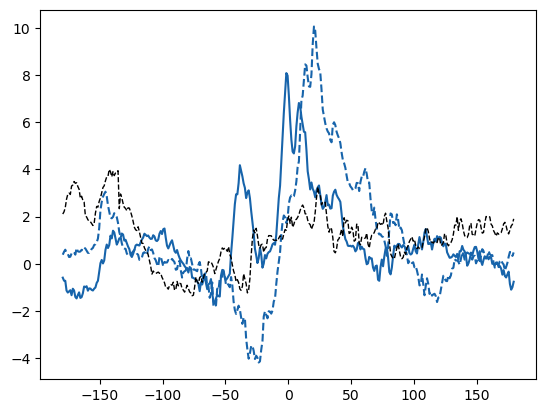

In [299]:
# plt.plot(hr_sep_sialon_trends_da.lon, 1e3*hr_sep_sialon_trends_da.isel(sample=rmse_lon(hr_sep_sialon_trends_da, nsidc_sialon_trend_sep).argmin()), color=blues(0.8), linestyle='--', label='HR best')
plt.plot(hr_sep_sialon_trends_da.lon, 1e3*hr_sep_sialon_trends_da.isel(sample=hr_osi_saf_sialon_corr_sep.argmax()), color=blues(0.8), linestyle='--', label='LR best')
plt.plot(hr_sep_sialon_trends_da.lon, 1e3*hr_sep_sialon_trends_da.isel(sample=rmse_lon(hr_sep_sialon_trends_da, nsidc_sialon_trend_sep).argmin()), color=blues(0.8), linestyle='-', label='LR best')

plt.plot(nsidc_sialon_trend_sep.lon, 1e3*nsidc_sialon_trend_sep, color='k', linestyle='--', linewidth=1, label='NSIDC')

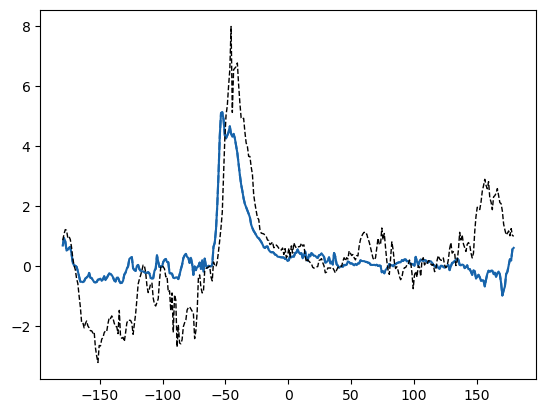

In [300]:
# plt.plot(hr_sep_sialon_trends_da.lon, 1e3*hr_sep_sialon_trends_da.isel(sample=rmse_lon(hr_sep_sialon_trends_da, nsidc_sialon_trend_sep).argmin()), color=blues(0.8), linestyle='--', label='HR best')
plt.plot(hr_feb_sialon_trends_da.lon, 1e3*hr_feb_sialon_trends_da.isel(sample=hr_osi_saf_sialon_corr_feb.argmax()), color=blues(0.8), linestyle='--', label='LR best')
plt.plot(hr_feb_sialon_trends_da.lon, 1e3*hr_feb_sialon_trends_da.isel(sample=rmse_lon(hr_feb_sialon_trends_da, nsidc_sialon_trend_feb).argmin()), color=blues(0.8), linestyle='-', label='LR best')

plt.plot(nsidc_sialon_trend_feb.lon, 1e3*nsidc_sialon_trend_feb, color='k', linestyle='--', linewidth=1, label='NSIDC')

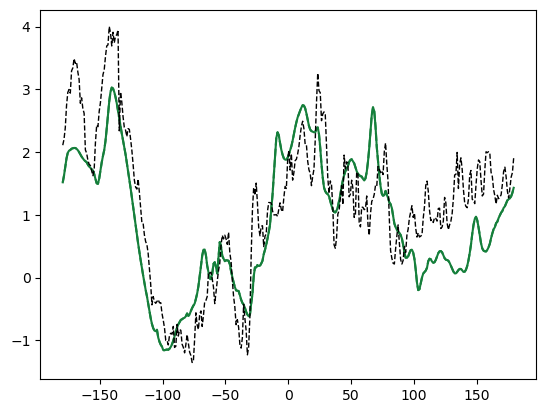

In [301]:
# plt.plot(hr_sep_sialon_trends_da.lon, 1e3*hr_sep_sialon_trends_da.isel(sample=rmse_lon(hr_sep_sialon_trends_da, nsidc_sialon_trend_sep).argmin()), color=blues(0.8), linestyle='--', label='HR best')
plt.plot(lr_sep_sialon_trends_da.lon, 1e3*lr_sep_sialon_trends_da.isel(sample=lr_osi_saf_sialon_corr_sep.argmax()), color=greens(0.8), linestyle='--', label='LR best')
plt.plot(lr_sep_sialon_trends_da.lon, 1e3*lr_sep_sialon_trends_da.isel(sample=rmse_lon(lr_sep_sialon_trends_da, nsidc_sialon_trend_sep).argmin()), color=greens(0.8), linestyle='-', label='LR best')

plt.plot(nsidc_sialon_trend_sep.lon, 1e3*nsidc_sialon_trend_sep, color='k', linestyle='--', linewidth=1, label='NSIDC')

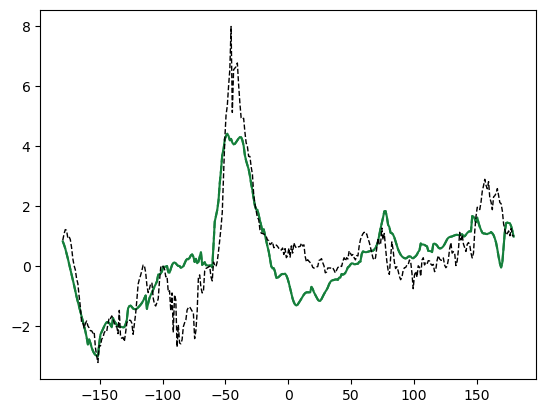

In [302]:
# plt.plot(hr_sep_sialon_trends_da.lon, 1e3*hr_sep_sialon_trends_da.isel(sample=rmse_lon(hr_sep_sialon_trends_da, nsidc_sialon_trend_sep).argmin()), color=blues(0.8), linestyle='--', label='HR best')
plt.plot(lr_feb_sialon_trends_da.lon, 1e3*lr_feb_sialon_trends_da.isel(sample=lr_osi_saf_sialon_corr_feb.argmax()), color=greens(0.8), linestyle='--', label='LR best')
plt.plot(lr_feb_sialon_trends_da.lon, 1e3*lr_feb_sialon_trends_da.isel(sample=rmse_lon(lr_feb_sialon_trends_da, nsidc_sialon_trend_feb).argmin()), color=greens(0.8), linestyle='-', label='LR best')

plt.plot(nsidc_sialon_trend_feb.lon, 1e3*nsidc_sialon_trend_feb, color='k', linestyle='--', linewidth=1, label='NSIDC')

Text(0.03, 0.82, '$n_\\mathrm{a}=$77')

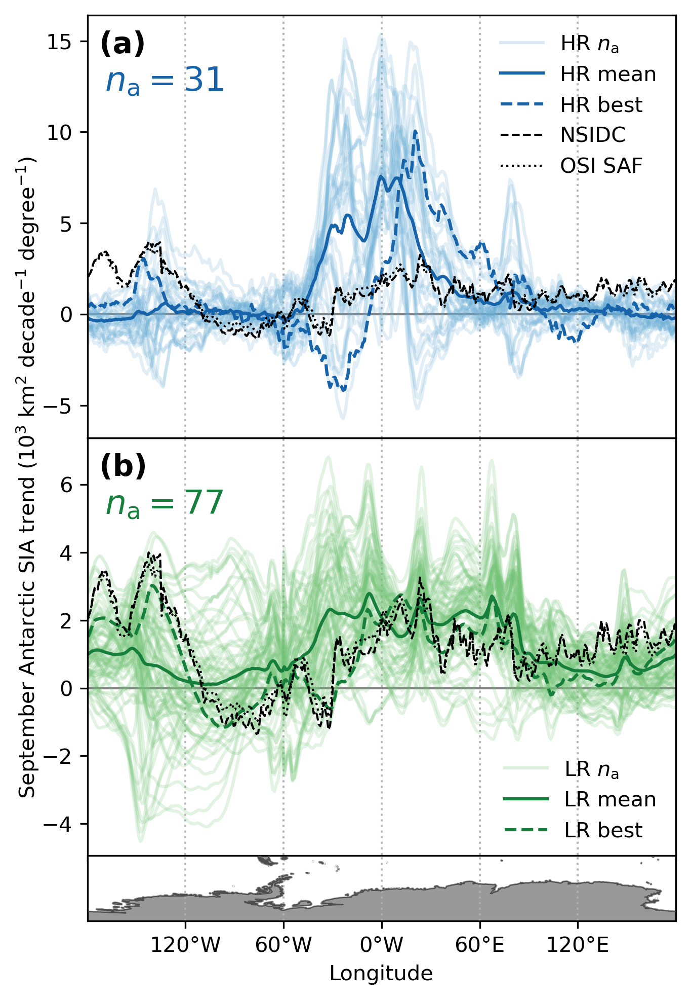

In [332]:
fig_z = plt.figure(dpi=300, figsize=(5, 8))
# ax1z = fig_z.add_subplot(211)
ax2z = fig_z.add_subplot(111)

divider = make_axes_locatable(ax2z)
axzmap = divider.new_vertical(size='30%', pad=-0.235, pack_start=True, axes_class=GeoAxes, projection=ccrs.PlateCarree())
fig_z.add_axes(axzmap)
axzmap.set_yticks([])
axzmap.set_xticks([-120, -60, 0, 60, 120])
axzmap.grid(axis='x', linewidth=1, linestyle=':', alpha=0.9)
axzmap.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
axzmap.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))
axzmap.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '10m'), color='0.6')
axzmap.coastlines(color='0.3', linewidth=0.5, zorder=4)

ax1z = divider.new_vertical(size='100%', pad=0.0, pack_start=False, axes_class=plt.Axes)
fig_z.add_axes(ax1z)

for axz in [ax1z, ax2z]:
    axz.axhline(0, color='0.5', linewidth=1, zorder=-1)
    axz.set_xticks([-120, -60, 0, 60, 120])
    axz.set_xlim(-180, 180)
    axz.grid(axis='x', linewidth=1, linestyle=':', alpha=0.9)
    axz.set_xticklabels([])
    
ax1z.plot(hr_sep_sialon_trends_da.lon, 1e3*hr_sep_sialon_trends_da.isel(sample=0), color=blues(0.5), alpha=0.25, label=r'HR $n_\mathrm{a}$')
for sample in hr_sep_sialon_trends_da.sample[1:]:
    ax1z.plot(hr_sep_sialon_trends_da.lon, 1e3*hr_sep_sialon_trends_da.sel(sample=sample), color=blues(0.5), alpha=0.2)

# ax1z.fill_between(hr_sep_sialon_trends_da.lon, 1e3*hr_sep_sialon_trends_da.min(dim='sample'), 1e3*hr_sep_sialon_trends_da.max(dim='sample'), 
                  # color=blues(0.8), alpha=0.6, edgecolor='none', label='HR range')

ax1z.plot(hr_sep_sialon_trends_da.lon, 1e3*hr_sep_sialon_trends_da.mean(dim='sample'), color=blues(0.8), linestyle='-', label='HR mean')
ax1z.plot(hr_sep_sialon_trends_da.lon, 1e3*hr_sep_sialon_trends_da.isel(sample=hr_osi_saf_sialon_corr_sep.argmax()), color=blues(0.8), linestyle='--', label='HR best')
ax1z.plot(nsidc_sialon_trend_sep.lon, 1e3*nsidc_sialon_trend_sep, color='k', linestyle='--', linewidth=1, label='NSIDC')
ax1z.plot(osi_saf_sialon_trend_sep.lon, 1e3*osi_saf_sialon_trend_sep, color='k', linestyle=':', linewidth=1, label='OSI SAF')
# ax1z.fill_between(nsidc_sialon_trend_sep.lon, 1e3*obs_sialon_slope_se_min_sep, 1e3*obs_sialon_slope_se_max_sep, alpha=0.25, color='k', edgecolor='none')
ax1z.set_xticklabels([])
ax1z.tick_params(axis='x', length=0)
ax1z.legend(loc='upper right', fontsize='medium', framealpha=0, fancybox=False)

ax2z.plot(lr_sep_sialon_trends_da.lon, 1e3*lr_sep_sialon_trends_da.isel(sample=0), color=greens(0.5), alpha=0.25, label=r'LR $n_\mathrm{a}$')
for sample in lr_sep_sialon_trends_da.sample[1:]:
    ax2z.plot(lr_sep_sialon_trends_da.lon, 1e3*lr_sep_sialon_trends_da.sel(sample=sample), color=greens(0.5), alpha=0.2)

# ax2z.fill_between(lr_sep_sialon_trends_da.lon, 1e3*lr_sep_sialon_trends_da.min(dim='sample'), 1e3*lr_sep_sialon_trends_da.max(dim='sample'), 
#                   color=greens(0.8), alpha=0.6, edgecolor='none', label='LR range')

ax2z.plot(lr_sep_sialon_trends_da.lon, 1e3*lr_sep_sialon_trends_da.mean(dim='sample'), color=greens(0.8), linestyle='-', label='LR mean')
ax2z.plot(lr_sep_sialon_trends_da.lon, 1e3*lr_sep_sialon_trends_da.isel(sample=lr_osi_saf_sialon_corr_sep.argmax()), color=greens(0.8), linestyle='--', label='LR best')
ax2z.plot(nsidc_sialon_trend_sep.lon, 1e3*nsidc_sialon_trend_sep, color='k', linestyle='--', linewidth=1)
ax2z.plot(osi_saf_sialon_trend_sep.lon, 1e3*osi_saf_sialon_trend_sep, color='k', linestyle=':', linewidth=1)
# ax2z.fill_between(nsidc_sialon_trend_sep.lon, 1e3*obs_sialon_slope_se_min_sep, 1e3*obs_sialon_slope_se_max_sep, alpha=0.25, color='k', edgecolor='none')
ax2z.set_yticks([-4, -2, 0, 2, 4, 6])
ax2z.legend(loc='lower right', fontsize='medium', framealpha=0, fancybox=False)

fig_z.supylabel('September Antarctic SIA trend (10$^3$ km$^2$ decade$^{-1}$ degree$^{-1}$)', x=0.03, fontsize=10)
axzmap.set_xlabel('Longitude')

for label, ax in zip(list('ab'), [ax1z, ax2z]):
    ax.annotate('('+label+')', xy=(0.02, 0.91), xycoords='axes fraction', fontweight='bold', fontsize=14)

ax1z.annotate(r'$n_\mathrm{a}=$%i' %hr_sep_sialon_trends_da.sample.size, xy=(0.03, 0.82), xycoords='axes fraction', fontsize=16, color=blues(0.8))
ax2z.annotate(r'$n_\mathrm{a}=$%i' %lr_sep_sialon_trends_da.sample.size, xy=(0.03, 0.82), xycoords='axes fraction', fontsize=16, color=greens(0.8))

Text(0.03, 0.82, '$n_\\mathrm{a}=$31')

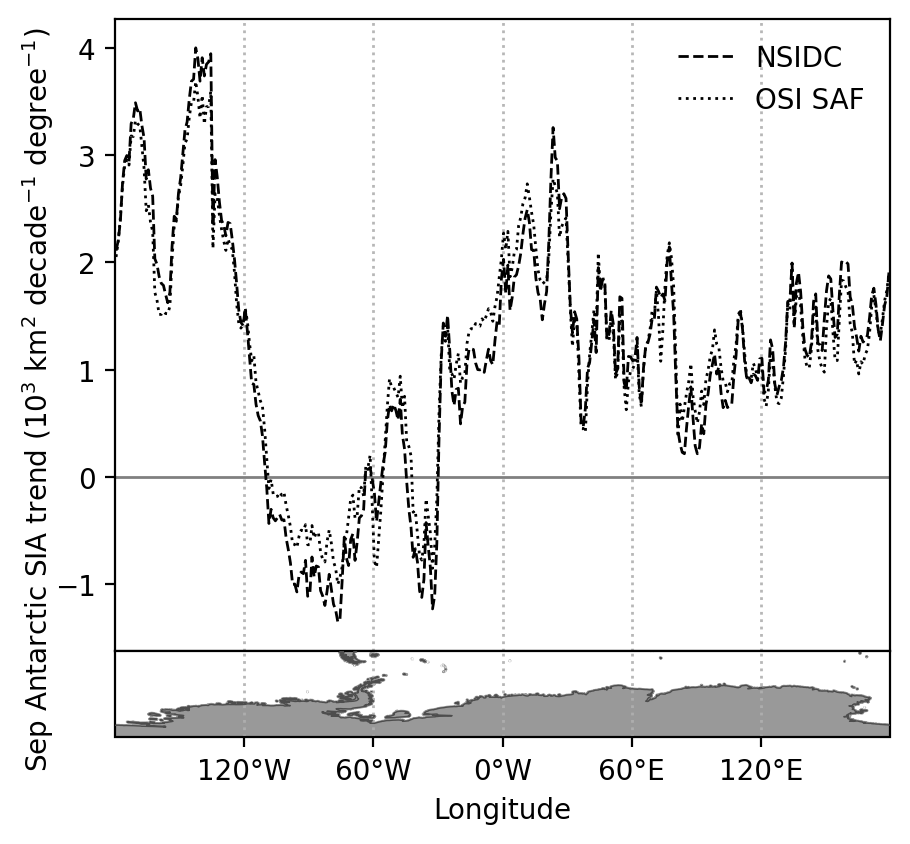

In [304]:
fig_z = plt.figure(dpi=200, figsize=(5, 5))
# ax1z = fig_z.add_subplot(211)
ax2z = fig_z.add_subplot(111)

divider = make_axes_locatable(ax2z)
axzmap = divider.new_vertical(size='30%', pad=-0.255, pack_start=True, axes_class=GeoAxes, projection=ccrs.PlateCarree())
fig_z.add_axes(axzmap)
axzmap.set_yticks([])
axzmap.set_xticks([-120, -60, 0, 60, 120])
axzmap.grid(axis='x', linewidth=1, linestyle=':', alpha=0.9)
axzmap.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
axzmap.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))
axzmap.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '10m'), color='0.6')
axzmap.coastlines(color='0.3', linewidth=0.5, zorder=4)

# ax1z = divider.new_vertical(size='100%', pad=0.0, pack_start=False, axes_class=plt.Axes)
# fig_z.add_axes(ax1z)

for axz in [ax2z]:
    axz.axhline(0, color='0.5', linewidth=1, zorder=-1)
    axz.set_xticks([-120, -60, 0, 60, 120])
    axz.set_xlim(-180, 180)
    axz.grid(axis='x', linewidth=1, linestyle=':', alpha=0.9)
    axz.set_xticklabels([])
    
# ax1z.plot(hr_sep_sialon_trends_da.lon, 1e3*hr_sep_sialon_trends_da.isel(sample=0), color=blues(0.5), alpha=0.25, label=r'HR $n_\mathrm{a}$')
# for sample in hr_sep_sialon_trends_da.sample[1:]:
#     ax1z.plot(hr_sep_sialon_trends_da.lon, 1e3*hr_sep_sialon_trends_da.sel(sample=sample), color=blues(0.5), alpha=0.2)

# # ax1z.fill_between(hr_sep_sialon_trends_da.lon, 1e3*hr_sep_sialon_trends_da.min(dim='sample'), 1e3*hr_sep_sialon_trends_da.max(dim='sample'), 
#                   # color=blues(0.8), alpha=0.6, edgecolor='none', label='HR range')

# ax1z.plot(hr_sep_sialon_trends_da.lon, 1e3*hr_sep_sialon_trends_da.mean(dim='sample'), color=blues(0.8), linestyle='-', label='HR mean')
# ax1z.plot(hr_sep_sialon_trends_da.lon, 1e3*hr_sep_sialon_trends_da.isel(sample=hr_osi_saf_sialon_corr_sep.argmax()), color=blues(0.8), linestyle='--', label='HR best')
# ax1z.plot(nsidc_sialon_trend_sep.lon, 1e3*nsidc_sialon_trend_sep, color='k', linestyle='--', linewidth=1, label='NSIDC')
# ax1z.plot(osi_saf_sialon_trend_sep.lon, 1e3*osi_saf_sialon_trend_sep, color='k', linestyle=':', linewidth=1, label='OSI SAF')
# # ax1z.fill_between(nsidc_sialon_trend_sep.lon, 1e3*obs_sialon_slope_se_min_sep, 1e3*obs_sialon_slope_se_max_sep, alpha=0.25, color='k', edgecolor='none')
# ax1z.set_xticklabels([])
# ax1z.tick_params(axis='x', length=0)

# ax2z.plot(lr_sep_sialon_trends_da.lon, 1e3*lr_sep_sialon_trends_da.isel(sample=0), color=greens(0.5), alpha=0.25, label=r'LR $n_\mathrm{a}$')
# for sample in lr_sep_sialon_trends_da.sample[1:]:
#     ax2z.plot(lr_sep_sialon_trends_da.lon, 1e3*lr_sep_sialon_trends_da.sel(sample=sample), color=greens(0.5), alpha=0.2)

# ax2z.fill_between(lr_sep_sialon_trends_da.lon, 1e3*lr_sep_sialon_trends_da.min(dim='sample'), 1e3*lr_sep_sialon_trends_da.max(dim='sample'), 
#                   color=greens(0.8), alpha=0.6, edgecolor='none', label='LR range')

# ax2z.plot(lr_sep_sialon_trends_da.lon, 1e3*lr_sep_sialon_trends_da.mean(dim='sample'), color=greens(0.8), linestyle='-', label='LR mean')
# ax2z.plot(lr_sep_sialon_trends_da.lon, 1e3*lr_sep_sialon_trends_da.isel(sample=lr_osi_saf_sialon_corr_sep.argmax()), color=greens(0.8), linestyle='--', label='LR best')
ax2z.plot(nsidc_sialon_trend_sep.lon, 1e3*nsidc_sialon_trend_sep, color='k', linestyle='--', linewidth=1, label='NSIDC')
ax2z.plot(osi_saf_sialon_trend_sep.lon, 1e3*osi_saf_sialon_trend_sep, color='k', linestyle=':', linewidth=1, label='OSI SAF')
# ax2z.fill_between(nsidc_sialon_trend_sep.lon, 1e3*obs_sialon_slope_se_min_sep, 1e3*obs_sialon_slope_se_max_sep, alpha=0.25, color='k', edgecolor='none')
# ax2z.set_yticks([-4, -2, 0, 2, 4, 6])
ax2z.legend(loc='lower right', fontsize='medium', framealpha=0, fancybox=False)

fig_z.supylabel('Sep Antarctic SIA trend (10$^3$ km$^2$ decade$^{-1}$ degree$^{-1}$)', x=0.03, fontsize=10)
axzmap.set_xlabel('Longitude')
ax2z.legend(loc='upper right', fontsize='medium', framealpha=0, fancybox=False)

# for label, ax in zip(list('ab'), [ax1z, ax2z]):
    # ax.annotate('('+label+')', xy=(0.02, 0.91), xycoords='axes fraction', fontweight='bold', fontsize=14)

ax1z.annotate(r'$n_\mathrm{a}=$%i' %hr_sep_sialon_trends_da.sample.size, xy=(0.03, 0.82), xycoords='axes fraction', fontsize=16, color=blues(0.8))
# ax2z.annotate(r'$n_\mathrm{a}=$%i' %lr_sep_sialon_trends_da.sample.size, xy=(0.03, 0.82), xycoords='axes fraction', fontsize=16, color=greens(0.8))

Text(0.03, 0.82, '$n_\\mathrm{a}=$395')

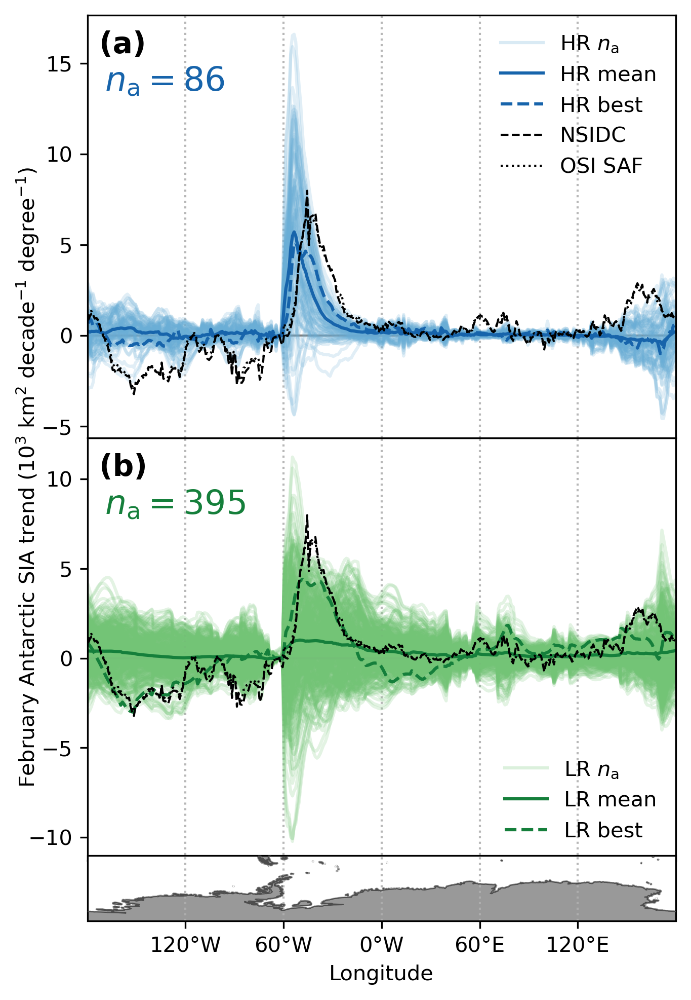

In [333]:
fig_z = plt.figure(dpi=300, figsize=(5, 8))
# ax1z = fig_z.add_subplot(211)
ax2z = fig_z.add_subplot(111)

divider = make_axes_locatable(ax2z)
axzmap = divider.new_vertical(size='30%', pad=-0.235, pack_start=True, axes_class=GeoAxes, projection=ccrs.PlateCarree())
fig_z.add_axes(axzmap)
axzmap.set_yticks([])
axzmap.set_xticks([-120, -60, 0, 60, 120])
axzmap.grid(axis='x', linewidth=1, linestyle=':', alpha=0.9)
axzmap.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
axzmap.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))
axzmap.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '10m'), color='0.6')
axzmap.coastlines(color='0.3', linewidth=0.5, zorder=4)

ax1z = divider.new_vertical(size='100%', pad=0.0, pack_start=False, axes_class=plt.Axes)
fig_z.add_axes(ax1z)

for axz in [ax1z, ax2z]:
    axz.axhline(0, color='0.5', linewidth=1, zorder=-1)
    axz.set_xticks([-120, -60, 0, 60, 120])
    axz.set_xlim(-180, 180)
    axz.grid(axis='x', linewidth=1, linestyle=':', alpha=0.9)
    axz.set_xticklabels([])
    
ax1z.plot(hr_feb_sialon_trends_da.lon, 1e3*hr_feb_sialon_trends_da.isel(sample=0), color=blues(0.5), alpha=0.25, label=r'HR $n_\mathrm{a}$')
for sample in hr_feb_sialon_trends_da.sample[1:]:
    ax1z.plot(hr_feb_sialon_trends_da.lon, 1e3*hr_feb_sialon_trends_da.sel(sample=sample), color=blues(0.5), alpha=0.2)

# ax1z.fill_between(hr_feb_sialon_trends_da.lon, 1e3*hr_feb_sialon_trends_da.min(dim='sample'), 1e3*hr_feb_sialon_trends_da.max(dim='sample'), 
                  # color=blues(0.8), alpha=0.6, edgecolor='none', label='HR range')

ax1z.plot(hr_feb_sialon_trends_da.lon, 1e3*hr_feb_sialon_trends_da.mean(dim='sample'), color=blues(0.8), linestyle='-', label='HR mean')
ax1z.plot(hr_feb_sialon_trends_da.lon, 1e3*hr_feb_sialon_trends_da.isel(sample=hr_osi_saf_sialon_corr_feb.argmax()), color=blues(0.8), linestyle='--', label='HR best')
ax1z.plot(nsidc_sialon_trend_feb.lon, 1e3*nsidc_sialon_trend_feb, color='k', linestyle='--', linewidth=1, label='NSIDC')
ax1z.plot(osi_saf_sialon_trend_feb.lon, 1e3*osi_saf_sialon_trend_feb, color='k', linestyle=':', linewidth=1, label='OSI SAF')
ax1z.set_xticklabels([])
ax1z.tick_params(axis='x', length=0)
ax1z.legend(loc='upper right', framealpha=0, fancybox=False)

ax2z.plot(lr_feb_sialon_trends_da.lon, 1e3*lr_feb_sialon_trends_da.isel(sample=0), color=greens(0.5), alpha=0.25, label=r'LR $n_\mathrm{a}$')
for sample in lr_feb_sialon_trends_da.sample[1:]:
    ax2z.plot(lr_feb_sialon_trends_da.lon, 1e3*lr_feb_sialon_trends_da.sel(sample=sample), color=greens(0.5), alpha=0.2)

# ax2z.fill_between(lr_feb_sialon_trends_da.lon, 1e3*lr_feb_sialon_trends_da.min(dim='sample'), 1e3*lr_feb_sialon_trends_da.max(dim='sample'), 
                  # color=greens(0.8), alpha=0.6, edgecolor='none', label='LR range')

ax2z.plot(lr_feb_sialon_trends_da.lon, 1e3*lr_feb_sialon_trends_da.mean(dim='sample'), color=greens(0.8), linestyle='-', label='LR mean')
ax2z.plot(lr_feb_sialon_trends_da.lon, 1e3*lr_feb_sialon_trends_da.isel(sample=lr_osi_saf_sialon_corr_feb.argmax()), color=greens(0.8), linestyle='--', label='LR best')
ax2z.plot(nsidc_sialon_trend_feb.lon, 1e3*nsidc_sialon_trend_feb, color='k', linestyle='--', linewidth=1)
ax2z.plot(osi_saf_sialon_trend_feb.lon, 1e3*osi_saf_sialon_trend_feb, color='k', linestyle=':', linewidth=1)
ax2z.set_yticks([-10, -5, 0, 5, 10])
ax2z.legend(loc='lower right', framealpha=0, fancybox=False)

fig_z.supylabel('February Antarctic SIA trend (10$^3$ km$^2$ decade$^{-1}$ degree$^{-1}$)', x=0.03, fontsize=10)
axzmap.set_xlabel('Longitude')

for label, ax in zip(list('ab'), [ax1z, ax2z]):
    ax.annotate('('+label+')', xy=(0.02, 0.91), xycoords='axes fraction', fontweight='bold', fontsize=14)

ax1z.annotate(r'$n_\mathrm{a}=$%i' %hr_feb_sialon_trends_da.sample.size, xy=(0.03, 0.82), xycoords='axes fraction', fontsize=16, color=blues(0.8))
ax2z.annotate(r'$n_\mathrm{a}=$%i' %lr_feb_sialon_trends_da.sample.size, xy=(0.03, 0.82), xycoords='axes fraction', fontsize=16, color=greens(0.8))

(-0.0013646974984681307, 0.0032364977637779173)

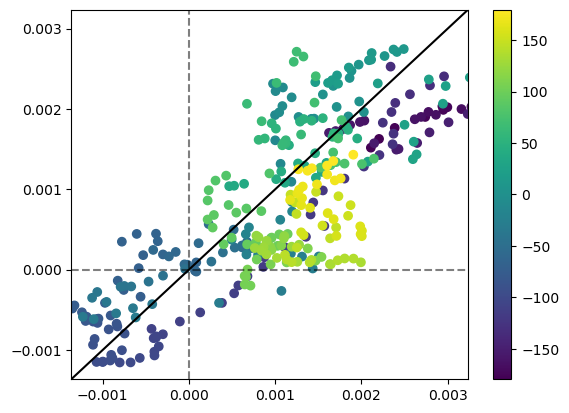

In [306]:
plt.scatter(nsidc_sialon_trend_sep, lr_sep_sialon_trends_da.isel(sample=lr_nsidc_sialon_corr_sep.argmax()), c=nsidc_sialon_trend_sep.lon, cmap='viridis')
plt.colorbar()
plt.axline([0, 0], slope=1, color='k')
plt.axhline(0, color='k', alpha=0.5, linestyle='--')
plt.axvline(0, color='k', alpha=0.5, linestyle='--')
plt.xlim(plt.gca().get_ylim())

(-0.0048890720281503505, 0.010766095619270662)

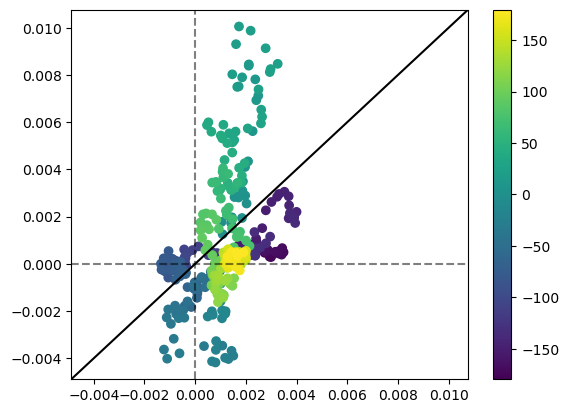

In [307]:
plt.scatter(nsidc_sialon_trend_sep, hr_sep_sialon_trends_da.isel(sample=hr_nsidc_sialon_corr_sep.argmax()), c=nsidc_sialon_trend_sep.lon, cmap='viridis')
plt.colorbar()
plt.axline([0, 0], slope=1, color='k')
plt.axhline(0, color='k', alpha=0.5, linestyle='--')
plt.axvline(0, color='k', alpha=0.5, linestyle='--')
plt.xlim(plt.gca().get_ylim())

## Figures 9 and 10: trend maps

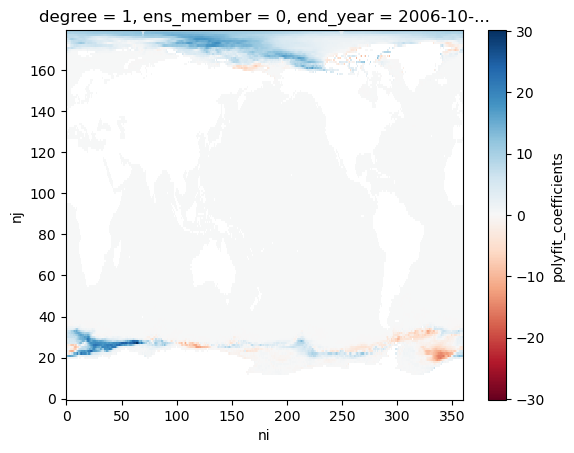

In [308]:
hr_sep_trend_map_mzc = ns_per_dec*hr_sep_trend_maps_da.isel(sample=hr_nsidc_sialon_corr_sep.argmax())
hr_sep_trend_map_mzc_50s = hr_sep_trend_map_mzc.where(hr_sic_ds.lat.isel(time=0, ens_member=0).compute() <= -50, drop=True)
hr_sep_trend_map_mzc.plot(cmap='RdBu')

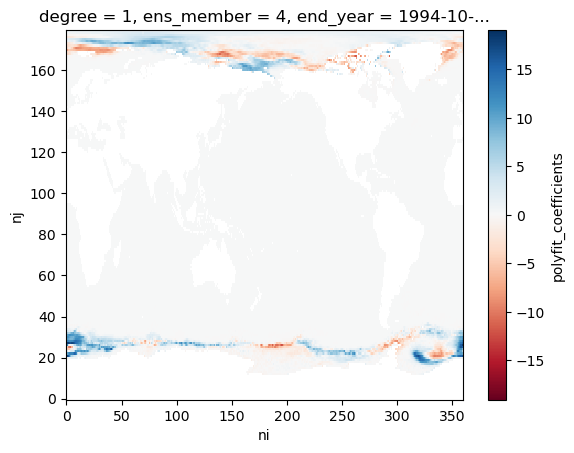

In [309]:
hr_sep_trend_map_mrmse = ns_per_dec*hr_sep_trend_maps_da.isel(sample=rmse_lon(hr_sep_sialon_trends_da, nsidc_sialon_trend_sep).argmin())
hr_sep_trend_map_mrmse_50s = hr_sep_trend_map_mrmse.where(hr_sic_ds.lat.isel(time=0, ens_member=0).compute() <= -50, drop=True)
hr_sep_trend_map_mrmse.plot(cmap='RdBu')

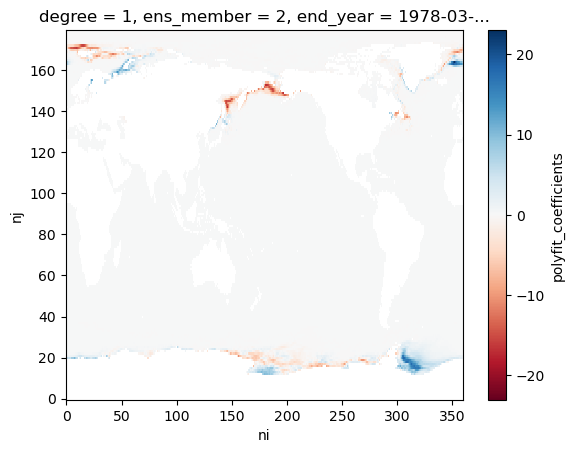

In [310]:
hr_feb_trend_map_mzc = ns_per_dec*hr_feb_trend_maps_da.isel(sample=hr_nsidc_sialon_corr_feb.argmax())
hr_feb_trend_map_mzc_50s = hr_feb_trend_map_mzc.where(hr_sic_ds.lat.isel(time=0, ens_member=0).compute() <= -50, drop=True)
hr_feb_trend_map_mzc.plot(cmap='RdBu')

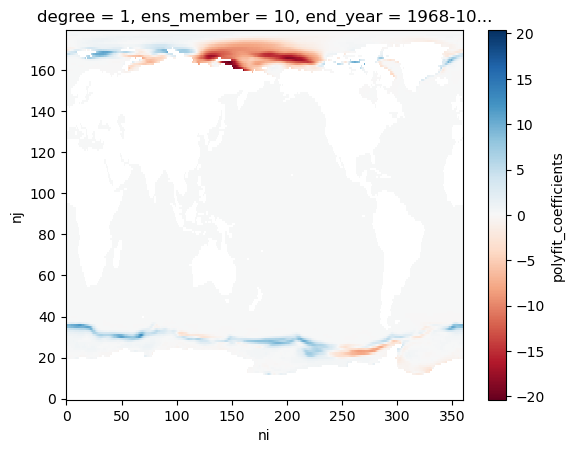

In [311]:
lr_sep_trend_map_mzc = ns_per_dec*lr_sep_trend_maps_da.isel(sample=lr_nsidc_sialon_corr_sep.argmax())
lr_sep_trend_map_mzc_50s = lr_sep_trend_map_mzc.where(lr_sic_ds.lat.isel(time=0, ens_member=0).compute() <= -50, drop=True)
lr_sep_trend_map_mzc.plot(cmap='RdBu')

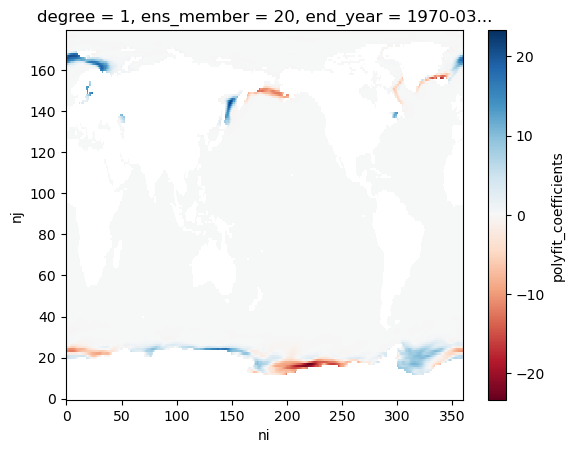

In [312]:
lr_feb_trend_map_mzc = ns_per_dec*lr_feb_trend_maps_da.isel(sample=lr_nsidc_sialon_corr_feb.argmax())
lr_feb_trend_map_mzc_50s = lr_feb_trend_map_mzc.where(lr_sic_ds.lat.isel(time=0, ens_member=0).compute() <= -50, drop=True)
lr_feb_trend_map_mzc.plot(cmap='RdBu')

In [313]:
hr_sep_trend_map_mzc

<xarray.DataArray 'polyfit_coefficients' (nj: 180, ni: 360)> Size: 518kB
dask.array<mul, shape=(180, 360), dtype=float64, chunksize=(180, 360), chunktype=numpy.ndarray>
Coordinates:
    degree      int64 8B 1
    ens_member  int64 8B 0
    end_year    object 8B 2006-10-01 00:00:00
Dimensions without coordinates: nj, ni

In [314]:
lr_sep_trend_map_mzc

<xarray.DataArray 'polyfit_coefficients' (nj: 180, ni: 360)> Size: 518kB
dask.array<mul, shape=(180, 360), dtype=float64, chunksize=(180, 360), chunktype=numpy.ndarray>
Coordinates:
    degree      int64 8B 1
    ens_member  int64 8B 10
    end_year    object 8B 1968-10-01 00:00:00
Dimensions without coordinates: nj, ni

In [315]:
hr_feb_trend_map_mzc

<xarray.DataArray 'polyfit_coefficients' (nj: 180, ni: 360)> Size: 518kB
dask.array<mul, shape=(180, 360), dtype=float64, chunksize=(180, 360), chunktype=numpy.ndarray>
Coordinates:
    degree      int64 8B 1
    ens_member  int64 8B 2
    end_year    object 8B 1978-03-01 00:00:00
Dimensions without coordinates: nj, ni

In [316]:
lr_feb_trend_map_mzc

<xarray.DataArray 'polyfit_coefficients' (nj: 180, ni: 360)> Size: 518kB
dask.array<mul, shape=(180, 360), dtype=float64, chunksize=(180, 360), chunktype=numpy.ndarray>
Coordinates:
    degree      int64 8B 1
    ens_member  int64 8B 20
    end_year    object 8B 1970-03-01 00:00:00
Dimensions without coordinates: nj, ni

In [317]:
aa_sea_ice_area(lr_sep_trend_map_mzc).values

array(0.32029276)

In [318]:
aa_sea_ice_area(ns_per_dec*hr_sep_trend_maps_avg)

<xarray.DataArray ()> Size: 8B
array(0.44676113)
Coordinates:
    degree   int64 8B 1
    time     object 8B 1920-02-01 00:00:00

In [319]:
hr_sep_trend_maps_avg_50s_cyc, _ = add_cyclic_point(hr_sep_trend_maps_avg_50s, lons)
lr_sep_trend_maps_avg_50s_cyc, _ = add_cyclic_point(lr_sep_trend_maps_avg_50s, lons)
hr_sep_trend_map_mzc_50s_cyc, _ = add_cyclic_point(hr_sep_trend_map_mzc_50s, lons)
lr_sep_trend_map_mzc_50s_cyc, _ = add_cyclic_point(lr_sep_trend_map_mzc_50s, lons)

hr_sep_trend_map_mrmse_50s_cyc, _ = add_cyclic_point(hr_sep_trend_map_mrmse_50s, lons)

In [320]:
hr_feb_trend_maps_avg_50s_cyc, _ = add_cyclic_point(hr_feb_trend_maps_avg_50s, lons)
lr_feb_trend_maps_avg_50s_cyc, _ = add_cyclic_point(lr_feb_trend_maps_avg_50s, lons)
hr_feb_trend_map_mzc_50s_cyc, _ = add_cyclic_point(hr_feb_trend_map_mzc_50s, lons)
lr_feb_trend_map_mzc_50s_cyc, _ = add_cyclic_point(lr_feb_trend_map_mzc_50s, lons)

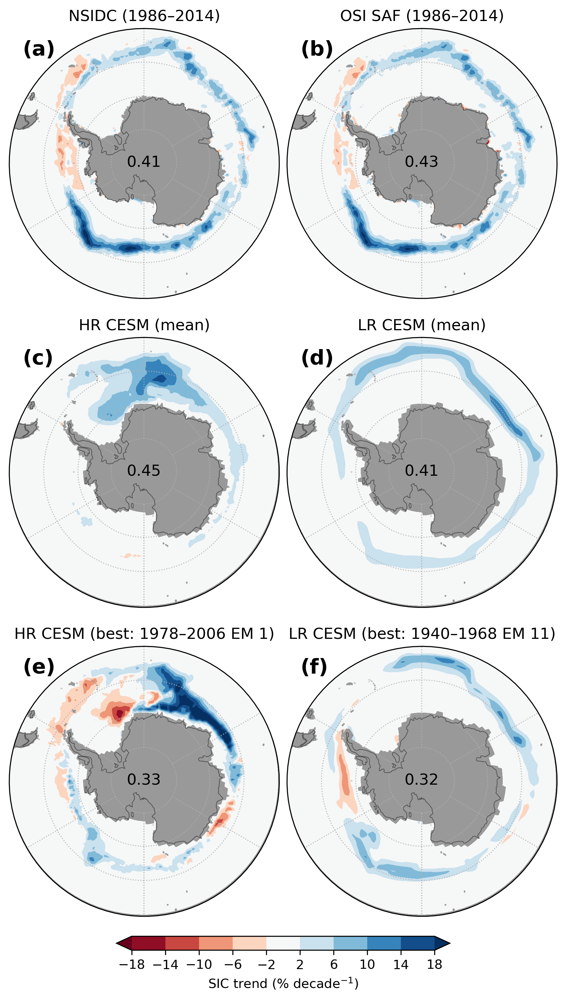

In [334]:
div_lvls = np.arange(-18, 18.1, 4)
fig_trend = plt.figure(6, figsize=(6, 10), dpi=300, layout='constrained')
ax1t = fig_trend.add_subplot(321, projection=sp_proj)
ax2t = fig_trend.add_subplot(322, projection=sp_proj)
ax3t = fig_trend.add_subplot(323, projection=sp_proj)
ax4t = fig_trend.add_subplot(324, projection=sp_proj)
ax5t = fig_trend.add_subplot(325, projection=sp_proj)
ax6t = fig_trend.add_subplot(326, projection=sp_proj)

ax1t_lon, ax1t_lat, nsidc_sep_incr_trend_map_plotting = z_masked_overlap(ax1t, nsidc_sep_clim.lon.data, nsidc_sep_clim.lat.data, nsidc_sep_incr_trend_map.data, source_projection=ccrs.Geodetic())
nsidc_trend_plot = ax1t.contourf(ax1t_lon, ax1t_lat, nsidc_sep_incr_trend_map_plotting, cmap='RdBu', levels=div_lvls, extend='both')
aa_plot_details(ax1t)
ax1t.set_title('NSIDC (1986–2014)')
ax1t.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
ax1t.add_patch(Polygon(xy=([60, -60], [60, -45], [390, -45], [390, -60]), facecolor=mpl.colormaps['RdBu'](0.5), edgecolor='none', zorder=-1, transform=ccrs.PlateCarree()))
ax1t.annotate('%.2f' %(ns_per_dec*nsidc_incr_trend_sep.values), (0, 0), xycoords='polar', color='k', fontsize=12, horizontalalignment='center', verticalalignment='center')

ax2t_lon, ax2t_lat, osi_saf_sep_incr_trend_map_plotting = z_masked_overlap(ax2t, osi_saf_sep_clim.lon.data, osi_saf_sep_clim.lat.data, osi_saf_sep_incr_trend_map.data, source_projection=ccrs.Geodetic())
osi_saf_trend_plot = ax2t.contourf(ax2t_lon, ax2t_lat, osi_saf_sep_incr_trend_map_plotting, cmap='RdBu', levels=div_lvls, extend='both')
ax2t.set_title('OSI SAF (1986–2014)')
aa_plot_details(ax2t)
ax2t.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
ax2t.annotate('%.2f' %(ns_per_dec*osi_saf_incr_trend_sep.values), (0, 0), xycoords='polar', color='k', fontsize=12, horizontalalignment='center', verticalalignment='center')

ax3t.set_title('HR CESM (mean)')
hr_comp_plot = ax3t.contourf(lons_cyc, lats, hr_sep_trend_maps_avg_50s_cyc, transform=ccrs.PlateCarree(), cmap='RdBu', levels=div_lvls, extend='both')
aa_plot_details(ax3t)
ax3t.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
ax3t.annotate('%.2f' %(aa_sea_ice_area(ns_per_dec*hr_sep_trend_maps_avg)), (0, 0), xycoords='polar', color='k', fontsize=12, horizontalalignment='center', verticalalignment='center')

ax4t.set_title('LR CESM (mean)')
lr_comp_plot = ax4t.contourf(lons_cyc, lats, lr_sep_trend_maps_avg_50s_cyc, transform=ccrs.PlateCarree(), cmap='RdBu', levels=div_lvls, extend='both')
aa_plot_details(ax4t)
ax4t.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
ax4t.annotate('%.2f' %(aa_sea_ice_area(ns_per_dec*lr_sep_trend_maps_avg)), (0, 0), xycoords='polar', color='k', fontsize=12, horizontalalignment='center', verticalalignment='center')

ax5t.set_title('HR CESM (best: '+str(hr_sep_trend_map_mzc.end_year.dt.year.values - 28)
                            +'–'+str(hr_sep_trend_map_mzc.end_year.dt.year.values)+' EM '+str(hr_sep_trend_map_mzc.ens_member.values+1)+')')
hr_trend_plot = ax5t.contourf(lons_cyc, lats, hr_sep_trend_map_mzc_50s_cyc, transform=ccrs.PlateCarree(), cmap='RdBu', levels=div_lvls, extend='both')
aa_plot_details(ax5t)
ax5t.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
ax5t.annotate('%.2f' %(aa_sea_ice_area(hr_sep_trend_map_mzc)), (0, 0), xycoords='polar', color='k', fontsize=12, horizontalalignment='center', verticalalignment='center')

ax6t.set_title('LR CESM (best: '+str(lr_sep_trend_map_mzc.end_year.dt.year.values - 28)
                            +'–'+str(lr_sep_trend_map_mzc.end_year.dt.year.values)+' EM '+str(lr_sep_trend_map_mzc.ens_member.values+1)+')')
lr_trend_plot = ax6t.contourf(lons_cyc, lats, lr_sep_trend_map_mzc_50s_cyc, transform=ccrs.PlateCarree(), cmap='RdBu', levels=div_lvls, extend='both')
aa_plot_details(ax6t)
ax6t.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
ax6t.annotate('%.2f' %(aa_sea_ice_area(lr_sep_trend_map_mzc)), (0, 0), xycoords='polar', color='k', fontsize=12, horizontalalignment='center', verticalalignment='center')

cbar_ax = fig_trend.add_axes([0.2, -0.02, 0.6, 0.015])
fig_trend.colorbar(nsidc_trend_plot, cax=cbar_ax, orientation='horizontal', label='SIC trend (% decade$^{-1}$)')

# fig_trend.suptitle('September SIC trends')
for label, ax in zip(list('abcdef'), [ax1t, ax2t, ax3t, ax4t, ax5t, ax6t]):
    ax.annotate('('+label+')', xy=(0.05, 0.9), xycoords='axes fraction', fontweight='bold', fontsize=16)

Version for poster:

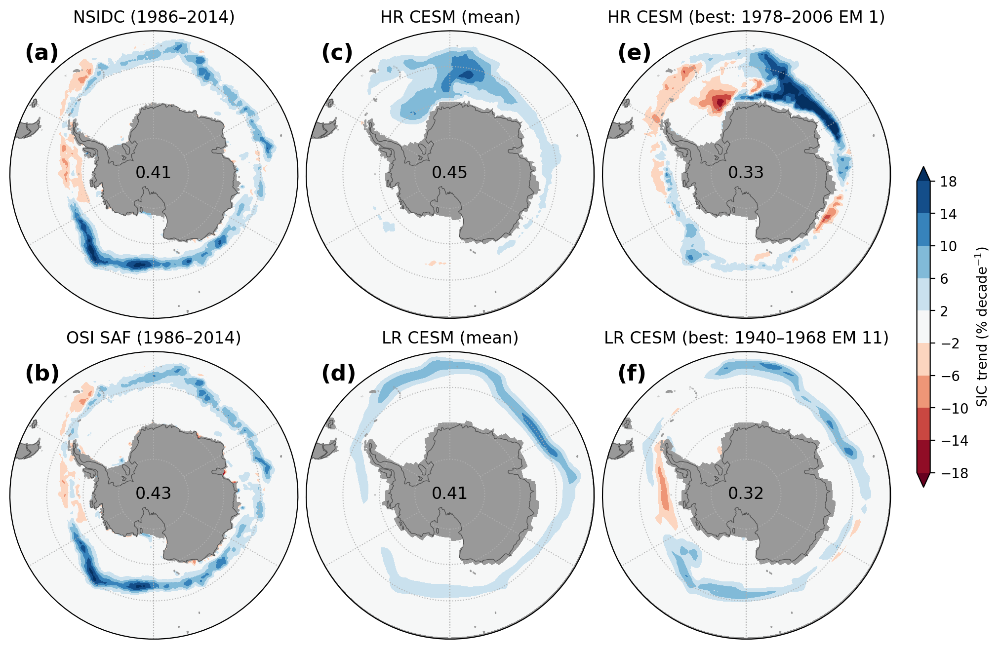

In [322]:
div_lvls = np.arange(-18, 18.1, 4)
fig_trend = plt.figure(6, figsize=(9, 6.5), dpi=200, layout='constrained')
ax1t = fig_trend.add_subplot(231, projection=sp_proj)
ax2t = fig_trend.add_subplot(234, projection=sp_proj)
ax3t = fig_trend.add_subplot(232, projection=sp_proj)
ax4t = fig_trend.add_subplot(235, projection=sp_proj)
ax5t = fig_trend.add_subplot(233, projection=sp_proj)
ax6t = fig_trend.add_subplot(236, projection=sp_proj)

ax1t_lon, ax1t_lat, nsidc_sep_incr_trend_map_plotting = z_masked_overlap(ax1t, nsidc_sep_clim.lon.data, nsidc_sep_clim.lat.data, nsidc_sep_incr_trend_map.data, source_projection=ccrs.Geodetic())
nsidc_trend_plot = ax1t.contourf(ax1t_lon, ax1t_lat, nsidc_sep_incr_trend_map_plotting, cmap='RdBu', levels=div_lvls, extend='both')
aa_plot_details(ax1t)
ax1t.set_title('NSIDC (1986–2014)')
ax1t.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
ax1t.add_patch(Polygon(xy=([60, -60], [60, -45], [390, -45], [390, -60]), facecolor=mpl.colormaps['RdBu'](0.5), edgecolor='none', zorder=-1, transform=ccrs.PlateCarree()))
ax1t.annotate('%.2f' %(ns_per_dec*nsidc_incr_trend_sep.values), (0, 0), xycoords='polar', color='k', fontsize=12, horizontalalignment='center', verticalalignment='center')

ax2t_lon, ax2t_lat, osi_saf_sep_incr_trend_map_plotting = z_masked_overlap(ax2t, osi_saf_sep_clim.lon.data, osi_saf_sep_clim.lat.data, osi_saf_sep_incr_trend_map.data, source_projection=ccrs.Geodetic())
osi_saf_trend_plot = ax2t.contourf(ax2t_lon, ax2t_lat, osi_saf_sep_incr_trend_map_plotting, cmap='RdBu', levels=div_lvls, extend='both')
ax2t.set_title('OSI SAF (1986–2014)')
aa_plot_details(ax2t)
ax2t.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
ax2t.annotate('%.2f' %(ns_per_dec*osi_saf_incr_trend_sep.values), (0, 0), xycoords='polar', color='k', fontsize=12, horizontalalignment='center', verticalalignment='center')

ax3t.set_title('HR CESM (mean)')
hr_comp_plot = ax3t.contourf(lons_cyc, lats, hr_sep_trend_maps_avg_50s_cyc, transform=ccrs.PlateCarree(), cmap='RdBu', levels=div_lvls, extend='both')
aa_plot_details(ax3t)
ax3t.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
ax3t.annotate('%.2f' %(aa_sea_ice_area(ns_per_dec*hr_sep_trend_maps_avg)), (0, 0), xycoords='polar', color='k', fontsize=12, horizontalalignment='center', verticalalignment='center')

ax4t.set_title('LR CESM (mean)')
lr_comp_plot = ax4t.contourf(lons_cyc, lats, lr_sep_trend_maps_avg_50s_cyc, transform=ccrs.PlateCarree(), cmap='RdBu', levels=div_lvls, extend='both')
aa_plot_details(ax4t)
ax4t.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
ax4t.annotate('%.2f' %(aa_sea_ice_area(ns_per_dec*lr_sep_trend_maps_avg)), (0, 0), xycoords='polar', color='k', fontsize=12, horizontalalignment='center', verticalalignment='center')

ax5t.set_title('HR CESM (best: '+str(hr_sep_trend_map_mzc.end_year.dt.year.values - 28)
                            +'–'+str(hr_sep_trend_map_mzc.end_year.dt.year.values)+' EM '+str(hr_sep_trend_map_mzc.ens_member.values+1)+')')
hr_trend_plot = ax5t.contourf(lons_cyc, lats, hr_sep_trend_map_mzc_50s_cyc, transform=ccrs.PlateCarree(), cmap='RdBu', levels=div_lvls, extend='both')
aa_plot_details(ax5t)
ax5t.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
ax5t.annotate('%.2f' %(aa_sea_ice_area(hr_sep_trend_map_mzc)), (0, 0), xycoords='polar', color='k', fontsize=12, horizontalalignment='center', verticalalignment='center')

ax6t.set_title('LR CESM (best: '+str(lr_sep_trend_map_mzc.end_year.dt.year.values - 28)
                            +'–'+str(lr_sep_trend_map_mzc.end_year.dt.year.values)+' EM '+str(lr_sep_trend_map_mzc.ens_member.values+1)+')')
lr_trend_plot = ax6t.contourf(lons_cyc, lats, lr_sep_trend_map_mzc_50s_cyc, transform=ccrs.PlateCarree(), cmap='RdBu', levels=div_lvls, extend='both')
aa_plot_details(ax6t)
ax6t.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
ax6t.annotate('%.2f' %(aa_sea_ice_area(lr_sep_trend_map_mzc)), (0, 0), xycoords='polar', color='k', fontsize=12, horizontalalignment='center', verticalalignment='center')

cbar_ax = fig_trend.add_axes([1.025, 0.25, 0.015, 0.5])
fig_trend.colorbar(nsidc_trend_plot, cax=cbar_ax, orientation='vertical', label='SIC trend (% decade$^{-1}$)')

# fig_trend.suptitle('September SIC trends')
for label, ax in zip(list('abcdef'), [ax1t, ax2t, ax3t, ax4t, ax5t, ax6t]):
    ax.annotate('('+label+')', xy=(0.05, 0.9), xycoords='axes fraction', fontweight='bold', fontsize=16)

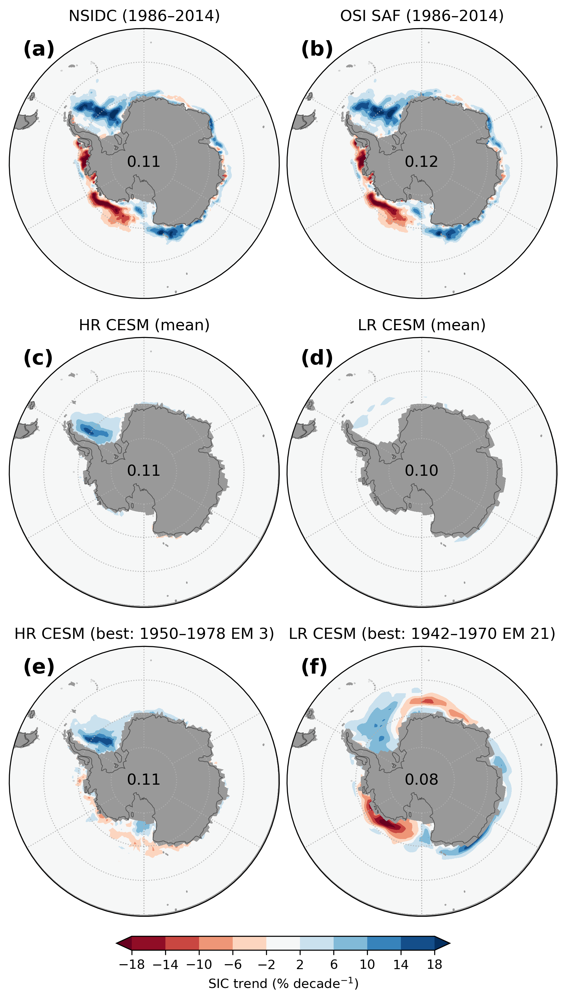

In [335]:
div_lvls = np.arange(-18, 18.1, 4)
fig_trend = plt.figure(6, figsize=(6, 10), dpi=300, layout='constrained')
ax1t = fig_trend.add_subplot(321, projection=sp_proj)
ax2t = fig_trend.add_subplot(322, projection=sp_proj)
ax3t = fig_trend.add_subplot(323, projection=sp_proj)
ax4t = fig_trend.add_subplot(324, projection=sp_proj)
ax5t = fig_trend.add_subplot(325, projection=sp_proj)
ax6t = fig_trend.add_subplot(326, projection=sp_proj)

ax1t_lon, ax1t_lat, nsidc_feb_incr_trend_map_plotting = z_masked_overlap(ax1t, nsidc_feb_clim.lon.data, nsidc_feb_clim.lat.data, nsidc_feb_incr_trend_map.data, source_projection=ccrs.Geodetic())
nsidc_trend_plot = ax1t.contourf(ax1t_lon, ax1t_lat, nsidc_feb_incr_trend_map_plotting, cmap='RdBu', levels=div_lvls, extend='both')
aa_plot_details(ax1t)
ax1t.set_title('NSIDC (1986–2014)')
ax1t.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
ax1t.add_patch(Polygon(xy=([60, -60], [60, -45], [390, -45], [390, -60]), facecolor=mpl.colormaps['RdBu'](0.5), edgecolor='none', zorder=-1, transform=ccrs.PlateCarree()))
ax1t.annotate('%.2f' %(ns_per_dec*nsidc_incr_trend_feb.values), (0, 0), xycoords='polar', color='k', fontsize=12, horizontalalignment='center', verticalalignment='center')

ax2t_lon, ax2t_lat, osi_saf_feb_incr_trend_map_plotting = z_masked_overlap(ax2t, osi_saf_feb_clim.lon.data, osi_saf_feb_clim.lat.data, osi_saf_feb_incr_trend_map.data, source_projection=ccrs.Geodetic())
osi_saf_trend_plot = ax2t.contourf(ax2t_lon, ax2t_lat, osi_saf_feb_incr_trend_map_plotting, cmap='RdBu', levels=div_lvls, extend='both')
ax2t.set_title('OSI SAF (1986–2014)')
aa_plot_details(ax2t)
ax2t.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
ax2t.annotate('%.2f' %(ns_per_dec*osi_saf_incr_trend_feb.values), (0, 0), xycoords='polar', color='k', fontsize=12, horizontalalignment='center', verticalalignment='center')

ax3t.set_title('HR CESM (mean)')
hr_comp_plot = ax3t.contourf(lons_cyc, lats, hr_feb_trend_maps_avg_50s_cyc, transform=ccrs.PlateCarree(), cmap='RdBu', levels=div_lvls, extend='both')
aa_plot_details(ax3t)
ax3t.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
ax3t.annotate('%.2f' %(aa_sea_ice_area(ns_per_dec*hr_feb_trend_maps_avg)), (0, 0), xycoords='polar', color='k', fontsize=12, horizontalalignment='center', verticalalignment='center')

ax4t.set_title('LR CESM (mean)')
lr_comp_plot = ax4t.contourf(lons_cyc, lats, lr_feb_trend_maps_avg_50s_cyc, transform=ccrs.PlateCarree(), cmap='RdBu', levels=div_lvls, extend='both')
aa_plot_details(ax4t)
ax4t.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
ax4t.annotate('%.2f' %(aa_sea_ice_area(ns_per_dec*lr_feb_trend_maps_avg)), (0, 0), xycoords='polar', color='k', fontsize=12, horizontalalignment='center', verticalalignment='center')

ax5t.set_title('HR CESM (best: '+str(hr_feb_trend_map_mzc.end_year.dt.year.values - 28)
                            +'–'+str(hr_feb_trend_map_mzc.end_year.dt.year.values)+' EM '+str(hr_feb_trend_map_mzc.ens_member.values+1)+')')
hr_trend_plot = ax5t.contourf(lons_cyc, lats, hr_feb_trend_map_mzc_50s_cyc, transform=ccrs.PlateCarree(), cmap='RdBu', levels=div_lvls, extend='both')
aa_plot_details(ax5t)
ax5t.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
ax5t.annotate('%.2f' %(aa_sea_ice_area(hr_feb_trend_map_mzc)), (0, 0), xycoords='polar', color='k', fontsize=12, horizontalalignment='center', verticalalignment='center')

ax6t.set_title('LR CESM (best: '+str(lr_feb_trend_map_mzc.end_year.dt.year.values - 28)
                            +'–'+str(lr_feb_trend_map_mzc.end_year.dt.year.values)+' EM '+str(lr_feb_trend_map_mzc.ens_member.values+1)+')')
lr_trend_plot = ax6t.contourf(lons_cyc, lats, lr_feb_trend_map_mzc_50s_cyc, transform=ccrs.PlateCarree(), cmap='RdBu', levels=div_lvls, extend='both')
aa_plot_details(ax6t)
ax6t.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
ax6t.annotate('%.2f' %(aa_sea_ice_area(lr_feb_trend_map_mzc)), (0, 0), xycoords='polar', color='k', fontsize=12, horizontalalignment='center', verticalalignment='center')

cbar_ax = fig_trend.add_axes([0.2, -0.02, 0.6, 0.015])
fig_trend.colorbar(nsidc_trend_plot, cax=cbar_ax, orientation='horizontal', label='SIC trend (% decade$^{-1}$)')

# fig_trend.suptitle('February SIC trends')
for label, ax in zip(list('abcdef'), [ax1t, ax2t, ax3t, ax4t, ax5t, ax6t]):
    ax.annotate('('+label+')', xy=(0.05, 0.9), xycoords='axes fraction', fontweight='bold', fontsize=16)